<a href="https://colab.research.google.com/github/GelarehGF/DT-SDG5-8/blob/main/SDG1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# Install kaleido for Plotly image export (RUN ONCE)
# =========================================================
!pip install -U kaleido
# ============================
# Core scientific stack
# ============================
!pip -q install numpy pandas scipy scikit-learn

# ============================
# NLP & embeddings
# ============================
!pip -q install sentence-transformers transformers nltk spacy gensim

# ============================
# Document parsing
# ============================
!pip -q install pdfplumber python-docx pymupdf

# ============================
# Graph theory & networks
# ============================
!pip -q install networkx python-igraph leidenalg

# ============================
# Visualization (2D + 3D)
# ============================
!pip -q install matplotlib seaborn plotly

# ============================
# Excel & file handling
# ============================
!pip -q install openpyxl xlrd xlsxwriter tqdm

# ============================
# Optional (robustness / stats)
# ============================
!pip -q install statsmodels
!pip install joypy
#!pip install -U kaleido
print("✅ Environment setup complete")

In [ ]:
!pip install pdfplumber python-docx

In [ ]:
!pip install pdfplumber

In [3]:
import pdfplumber
print(pdfplumber.__version__)

ModuleNotFoundError: No module named 'pdfplumber'

 INTERPRETATION RULE:
 This corpus analyzes Digital Transformation ONLY in relation to SDG 1 (No Poverty).
 Food security, agriculture, nutrition, education, and health are excluded
 unless they are explicitly linked to poverty reduction or economic deprivation.
AND
 SDG 2 analysis is restricted to hunger, nutrition, food systems,
 and agricultural livelihoods. Sustainability, climate, or rural
topics are included ONLY if directly linked to food security.

In [1]:
from google.colab import drive
drive.mount("/content/drive")
# =========================================================
# 0. Imports (NLP, Graphs, Stats, Visualization)
# =========================================================

# --- Core ---
import os
import re
import math
import json
import hashlib
import random
import itertools
import collections
from pathlib import Path

# --- Scientific stack ---
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import kendalltau

# --- NLP / Embeddings ---
from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# --- Document parsing ---
import pdfplumber
from docx import Document
import torch

# --- Graph theory ---
import networkx as nx
import igraph as ig

# --- Visualization (2D + 3D) ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import matplotlib.pylab as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Progress & I/O ---
from tqdm import tqdm

import seaborn as ans
import joypy
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# =========================================================
# 1. Reproducibility
# =========================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# =========================================================
# 2. Paths (LOCKED)
# =========================================================
base_path   = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/files/"
result_path = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"

os.makedirs(result_path, exist_ok=True)

# =========================================================
# 3. Core DataFrames (EMPTY, SHARED ACROSS PIPELINE)
# =========================================================

# Corpus inventory
df_corpus_index = pd.DataFrame(
    columns=["filename", "path", "size_bytes", "md5", "status"]
)

# Raw extracted text
df_documents = pd.DataFrame(
    columns=["paper_id", "path", "text"]
)

# DT theory similarity
df_theory_similarity = pd.DataFrame()   # rows = papers, cols = theories

# SDG similarity (SDG 1 vs SDG 2)
df_sdg_similarity = pd.DataFrame()      # rows = papers, cols = ["SDG1", "SDG2"]

# Dominance mapping
df_dominance = pd.DataFrame(
    columns=["paper_id", "dominant_theory", "dominant_sdg"]
)

# Theory × SDG crosstab
df_theory_sdg_crosstab = pd.DataFrame()

# Theory co-occurrence edges
df_theory_edges = pd.DataFrame(
    columns=["theory_a", "theory_b", "weight"]
)

# Centrality metrics
df_centrality = pd.DataFrame(
    columns=["theory", "degree", "strength", "betweenness", "closeness", "eigenvector"]
)

# Community detection results
df_communities = pd.DataFrame(
    columns=["theory", "community"]
)

# Bootstrap / robustness outputs
df_bootstrap = pd.DataFrame()

# =========================================================
# 4. Canonical DT Theory List (LOCKED)
# =========================================================
DT_THEORIES = [
    "Technology Acceptance Model (TAM)",
    "UTAUT",
    "Socio-Technical Systems (STS)",
    "Technology–Organization–Environment (TOE)",
    "Resource-Based View (RBV)",
    "Dynamic Capabilities",
    "Innovation Diffusion Theory (IDT)",
    "Stakeholder Theory",
    "Just Digital / Data Justice"
]
DT_THEORY_TEXTS = {
    "TAM": (
        "Technology Acceptance Model, perceived usefulness, "
        "perceived ease of use, technology adoption, user acceptance"
    ),

    "UTAUT": (
        "Unified Theory of Acceptance and Use of Technology, "
        "performance expectancy, effort expectancy, social influence, "
        "facilitating conditions"
    ),

    "STS": (
        "Socio-Technical Systems theory, interaction between social "
        "and technical systems, human technology interaction, "
        "organizational and social context"
    ),

    "TOE": (
        "Technology Organization Environment framework, "
        "technological context, organizational readiness, "
        "environmental and institutional pressure"
    ),

    "RBV": (
        "Resource Based View, organizational resources, "
        "capability constraints, resource scarcity, "
        "strategic assets"
    ),

    "Dynamic_Capabilities": (
        "Dynamic capabilities theory, sensing seizing transforming, "
        "organizational adaptability, reconfiguration, resilience"
    ),

    "IDT": (
        "Innovation Diffusion Theory, diffusion of innovation, "
        "early adopters, technology diffusion, adoption processes"
    ),

    "Stakeholder_Theory": (
        "Stakeholder theory, inclusive governance, "
        "multi stakeholder engagement, vulnerable populations"
    ),

    "Just_Digital": (
        "Just Digital framework, data justice, digital justice, "
        "algorithmic fairness, equitable access, inclusion"
    )
}
# =========================================================
# 5. SDG Semantic Anchors (LOCKED)
# =========================================================
SDG_ANCHORS = {
    "SDG1_No_Poverty": (
        "poverty, extreme poverty, multidimensional poverty, "
        "social protection, welfare systems, financial inclusion, "
        "economic vulnerability, income inequality"
    ),
    "SDG2_Zero_Hunger": (
        "food security, food insecurity, hunger, malnutrition, "
        "nutrition security, sustainable agriculture, "
        "smallholder farmers, food systems"
    )
}
SDG1_TEXT = (
    "No Poverty, extreme poverty, multidimensional poverty, "
    "economic deprivation, social exclusion, vulnerability, "
    "social protection systems, welfare programs, "
    "financial inclusion, access to resources, "
    "income inequality, economic resilience"
)
SDG2_TEXT = (
    "Zero Hunger, food security, food insecurity, hunger, malnutrition, "
    "nutrition security, undernourishment, "
    "sustainable agriculture, agricultural productivity, "
    "smallholder farmers, rural livelihoods, "
    "food systems, agri-food value chains, "
    "resilient agriculture, climate shock resilience"
)
SDG_TEXTS = {
    "SDG1_No_Poverty": (
        "No Poverty, extreme poverty, multidimensional poverty, "
        "economic deprivation, social exclusion, vulnerability, "
        "social protection systems, welfare programs, "
        "financial inclusion, access to resources, "
        "income inequality, economic resilience"
    ),

    "SDG2_Zero_Hunger": (
        "Zero Hunger, food security, food insecurity, hunger, malnutrition, "
        "nutrition security, undernourishment, "
        "sustainable agriculture, agricultural productivity, "
        "smallholder farmers, rural livelihoods, "
        "food systems, agri-food value chains, "
        "resilient agriculture, climate shock resilience"
    )
}
# =========================================================
# 6. Embedding Model (DEFINED, NOT RUN)
# =========================================================
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

print("✅ Initialization complete: imports, paths, DataFrames, theories, SDG anchors loaded.")

Mounted at /content/drive


ModuleNotFoundError: No module named 'pdfplumber'

In [ ]:
# =========================================================
# Extract text from files into df_documents
# =========================================================

def extract_text(path):
    if path.lower().endswith(".pdf"):
        with pdfplumber.open(path) as pdf:
            return " ".join(p.extract_text() or "" for p in pdf.pages)
    elif path.lower().endswith(".docx"):
        doc = Document(path)
        return " ".join(p.text for p in doc.paragraphs)
    elif path.lower().endswith(".txt"):
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            return f.read()
    else:
        return ""

rows = []

for root, _, files in os.walk(base_path):
    for f in files:
        path = os.path.join(root, f)
        try:
            text = extract_text(path)
            if text.strip():
                rows.append({
                    "paper_id": f,
                    "path": path,
                    "text": text.lower()
                })
        except Exception as e:
            continue

df_documents = pd.DataFrame(rows)

print("✅ Text extraction complete")
print("Documents:", df_documents.shape[0])
df_documents.head()

✅ Text extraction complete
Documents: 748


,paper_id,path,text
0,SDG1-349.docx,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,article critical success factors in agile-bas...
1,SDG1-350.docx,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,article a dual-level model of ai readiness in...
2,SDG1-352.docx,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,the impact of digitalization on the public op...
3,SDG1-345.docx,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,review towards digital transformation of agri...
4,SDG1-346.docx,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,sustainable development\t poverty alleviatio...


In [ ]:
# =========================================================
# Save corpus size metadata
# =========================================================

df_documents_shape = pd.DataFrame(
    [{
        "num_documents": df_documents.shape[0],
        "num_columns": df_documents.shape[1]
    }]
)

df_documents_shape.to_csv(
    os.path.join(result_path, "df_documents_shape.csv"),
    index=False
)

print("✅ df_documents.shape saved")
df_documents_shape

✅ df_documents.shape saved


,num_documents,num_columns
0,748,3


In [ ]:
print("df_documents shape:", df_documents.shape)
df_documents.head()

df_documents shape: (748, 3)


,paper_id,path,text
0,SDG1-349.docx,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,article critical success factors in agile-bas...
1,SDG1-350.docx,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,article a dual-level model of ai readiness in...
2,SDG1-352.docx,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,the impact of digitalization on the public op...
3,SDG1-345.docx,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,review towards digital transformation of agri...
4,SDG1-346.docx,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,sustainable development\t poverty alleviatio...


In [ ]:
import json

shape_metadata = {
    "df_documents_rows": int(df_documents.shape[0]),
    "df_documents_columns": int(df_documents.shape[1])
}

with open(os.path.join(result_path, "df_documents_shape.json"), "w") as f:
    json.dump(shape_metadata, f, indent=2)

print("✅ df_documents.shape saved as JSON")
shape_metadata

✅ df_documents.shape saved as JSON


{'df_documents_rows': 748, 'df_documents_columns': 3}

In [ ]:
# =========================================================
# REBUILD df_documents — DOCX ONLY (AUTHORITATIVE)
# =========================================================

rows = []

for root, _, files in os.walk(base_path):
    for f in files:
        if f.lower().endswith(".docx"):
            path = os.path.join(root, f)
            try:
                doc = Document(path)
                text = " ".join(p.text for p in doc.paragraphs)
                if text.strip():
                    rows.append({
                        "paper_id": f.replace(".docx", ""),
                        "path": path,
                        "text": text.lower()
                    })
            except Exception as e:
                print(f"Skipped {f}: {e}")

df_documents = pd.DataFrame(rows)

print("✅ df_documents rebuilt from DOCX only")
print("Shape:", df_documents.shape)
df_documents.head()

Skipped SDG1-113.docx: "There is no item named 'docProps/thumbnail.jpeg' in the archive"
✅ df_documents rebuilt from DOCX only
Shape: (748, 3)


,paper_id,path,text
0,SDG1-349,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,article critical success factors in agile-bas...
1,SDG1-350,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,article a dual-level model of ai readiness in...
2,SDG1-352,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,the impact of digitalization on the public op...
3,SDG1-345,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,review towards digital transformation of agri...
4,SDG1-346,/content/drive/MyDrive/Colab Notebooks/DTOSDG1...,sustainable development\t poverty alleviatio...


In [ ]:
# =========================================================
# BUILD df_documents (RUN ONLY ONCE)
# =========================================================

rows = []

for root, _, files in os.walk(base_path):
    for f in files:
        if f.lower().endswith(".docx"):
            path = os.path.join(root, f)
            try:
                doc = Document(path)
                text = " ".join(p.text for p in doc.paragraphs)
                if text.strip():
                    rows.append({
                        "paper_id": f.replace(".docx", ""),
                        "path": path,
                        "text": text.lower()
                    })
            except Exception as e:
                print(f"Skipped {f}: {e}")

df_documents = pd.DataFrame(rows)

print("✅ df_documents BUILT")
print(df_documents.shape)

# 🔒 SAVE ONCE
df_documents.to_csv(
    os.path.join(result_path, "df_documents.csv"),
    index=False
)

print("✅ df_documents SAVED permanently")

Skipped SDG1-113.docx: "There is no item named 'docProps/thumbnail.jpeg' in the archive"
✅ df_documents BUILT
(748, 3)
✅ df_documents SAVED permanently


In [ ]:
# =========================================================
# Build SDG similarity and export ONE Excel per SDG
# =========================================================

# Safety checks
assert not df_documents.empty, "df_documents is empty"
assert isinstance(SDG_TEXTS, dict) and len(SDG_TEXTS) == 2, "SDG_TEXTS not defined correctly"

# ---------------------------------------------------------
# 1. Prepare SDG anchors
# ---------------------------------------------------------
sdg_labels = list(SDG_TEXTS.keys())
sdg_texts  = list(SDG_TEXTS.values())

# ---------------------------------------------------------
# 2. Embed SDG anchors
# ---------------------------------------------------------
sdg_embeddings = embedding_model.encode(
    sdg_texts,
    convert_to_tensor=True,
    normalize_embeddings=True
)

# ---------------------------------------------------------
# 3. Embed document texts
# ---------------------------------------------------------
doc_embeddings = embedding_model.encode(
    df_documents["text"].tolist(),
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

# ---------------------------------------------------------
# 4. Compute cosine similarity (documents × SDGs)
# ---------------------------------------------------------
similarity_matrix = util.cos_sim(
    doc_embeddings,
    sdg_embeddings
).cpu().numpy()

df_sdg_scores = pd.DataFrame(
    similarity_matrix,
    columns=sdg_labels
)

df_sdg_scores.insert(
    0, "paper_id", df_documents["paper_id"].values
)

# ---------------------------------------------------------
# 5. SDG 1 — No Poverty (ONE Excel)
# ---------------------------------------------------------
df_sdg1 = df_sdg_scores[["paper_id", "SDG1_No_Poverty"]].copy()
df_sdg1["sdg"] = "SDG1_No_Poverty"

df_sdg1.to_excel(
    os.path.join(result_path, "SDG1_DT_similarity.xlsx"),
    index=False
)

# ---------------------------------------------------------
# 6. SDG 2 — Zero Hunger (ONE Excel)
# ---------------------------------------------------------
df_sdg2 = df_sdg_scores[["paper_id", "SDG2_Zero_Hunger"]].copy()
df_sdg2["sdg"] = "SDG2_Zero_Hunger"

df_sdg2.to_excel(
    os.path.join(result_path, "SDG2_DT_similarity.xlsx"),
    index=False
)

# ---------------------------------------------------------
# 7. Confirmation
# ---------------------------------------------------------
print("✅ SDG Excel files created successfully")
print("SDG 1 rows:", df_sdg1.shape[0])
print("SDG 2 rows:", df_sdg2.shape[0])

df_sdg1.head(), df_sdg2.head()

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

✅ SDG Excel files created successfully
SDG 1 rows: 748
SDG 2 rows: 748


(   paper_id  SDG1_No_Poverty              sdg
 0  SDG1-349         0.130959  SDG1_No_Poverty
 1  SDG1-350         0.100637  SDG1_No_Poverty
 2  SDG1-352         0.074855  SDG1_No_Poverty
 3  SDG1-345         0.178427  SDG1_No_Poverty
 4  SDG1-346         0.345245  SDG1_No_Poverty,
    paper_id  SDG2_Zero_Hunger               sdg
 0  SDG1-349          0.110562  SDG2_Zero_Hunger
 1  SDG1-350          0.100015  SDG2_Zero_Hunger
 2  SDG1-352          0.333108  SDG2_Zero_Hunger
 3  SDG1-345          0.411657  SDG2_Zero_Hunger
 4  SDG1-346          0.349728  SDG2_Zero_Hunger)

In [ ]:
# =========================================================
# Build DT Theory Similarity Matrix
# =========================================================

# Safety checks
assert not df_documents.empty, "df_documents is empty"
assert isinstance(DT_THEORY_TEXTS, dict) and len(DT_THEORY_TEXTS) > 0, "DT_THEORY_TEXTS not defined"

# ---------------------------------------------------------
# 1. Prepare DT theory anchors
# ---------------------------------------------------------
theory_labels = list(DT_THEORY_TEXTS.keys())
theory_texts  = list(DT_THEORY_TEXTS.values())

# ---------------------------------------------------------
# 2. Embed DT theory texts
# ---------------------------------------------------------
theory_embeddings = embedding_model.encode(
    theory_texts,
    convert_to_tensor=True,
    normalize_embeddings=True
)

# ---------------------------------------------------------
# 3. Embed document texts
# ---------------------------------------------------------
doc_embeddings = embedding_model.encode(
    df_documents["text"].tolist(),
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

# ---------------------------------------------------------
# 4. Compute cosine similarity (documents × DT theories)
# ---------------------------------------------------------
similarity_matrix = util.cos_sim(
    doc_embeddings,
    theory_embeddings
).cpu().numpy()

df_theory_similarity = pd.DataFrame(
    similarity_matrix,
    columns=theory_labels
)

df_theory_similarity.insert(
    0, "paper_id", df_documents["paper_id"].values
)

# ---------------------------------------------------------
# 5. Assign dominant DT theory per paper
# ---------------------------------------------------------
df_theory_similarity["dominant_dt_theory"] = (
    df_theory_similarity[theory_labels].idxmax(axis=1)
)

# ---------------------------------------------------------
# 6. Save outputs (authoritative)
# ---------------------------------------------------------
df_theory_similarity.to_csv(
    os.path.join(result_path, "dt_theory_similarity_matrix.csv"),
    index=False
)

df_theory_similarity.to_excel(
    os.path.join(result_path, "dt_theory_similarity_matrix.xlsx"),
    index=False
)

print("✅ DT Theory Similarity Matrix created")
print("Rows:", df_theory_similarity.shape[0])
df_theory_similarity.head()

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

✅ DT Theory Similarity Matrix created
Rows: 748


,paper_id,TAM,UTAUT,STS,TOE,RBV,Dynamic_Capabilities,IDT,Stakeholder_Theory,Just_Digital,dominant_dt_theory
0,SDG1-349,0.249565,0.318209,0.440587,0.487894,0.364487,0.453377,0.253460,0.295376,0.203457,TOE
1,SDG1-350,0.524092,0.529231,0.310501,0.554820,0.326366,0.339425,0.402054,0.249288,0.115868,TOE
2,SDG1-352,0.300366,0.313673,0.230218,0.260684,0.212325,0.238646,0.284524,0.233778,0.178900,UTAUT
3,SDG1-345,0.231426,0.196560,0.138748,0.244972,0.302641,0.308890,0.236663,0.177612,0.142301,Dynamic_Capabilities
4,SDG1-346,0.165246,0.243769,0.104790,0.231284,0.289573,0.301904,0.177523,0.324334,0.171927,Stakeholder_Theory


In [ ]:
# =========================================================
# Build SDG1 × DT table
# =========================================================

df_sdg1 = pd.read_excel(
    os.path.join(result_path, "SDG1_DT_similarity.xlsx")
)

df_sdg1_dt = (
    df_sdg1[["paper_id"]]
    .merge(
        df_theory_similarity[["paper_id", "dominant_dt_theory"]],
        on="paper_id",
        how="inner"
    )
)

df_sdg1_dt["SDG"] = "SDG1_No_Poverty"

df_sdg1_dt.to_csv(
    os.path.join(result_path, "SDG1_DT_table.csv"),
    index=False
)

df_sdg1_dt.to_excel(
    os.path.join(result_path, "SDG1_DT_table.xlsx"),
    index=False
)

print("✅ SDG1 × DT table created")
print(df_sdg1_dt.shape)
df_sdg1_dt.head()

✅ SDG1 × DT table created
(748, 3)


,paper_id,dominant_dt_theory,SDG
0,SDG1-349,TOE,SDG1_No_Poverty
1,SDG1-350,TOE,SDG1_No_Poverty
2,SDG1-352,UTAUT,SDG1_No_Poverty
3,SDG1-345,Dynamic_Capabilities,SDG1_No_Poverty
4,SDG1-346,Stakeholder_Theory,SDG1_No_Poverty


In [ ]:
# =========================================================
# Build SDG2 × DT table
# =========================================================

df_sdg2 = pd.read_excel(
    os.path.join(result_path, "SDG2_DT_similarity.xlsx")
)

df_sdg2_dt = (
    df_sdg2[["paper_id"]]
    .merge(
        df_theory_similarity[["paper_id", "dominant_dt_theory"]],
        on="paper_id",
        how="inner"
    )
)

df_sdg2_dt["SDG"] = "SDG2_Zero_Hunger"

df_sdg2_dt.to_csv(
    os.path.join(result_path, "SDG2_DT_table.csv"),
    index=False
)

df_sdg2_dt.to_excel(
    os.path.join(result_path, "SDG2_DT_table.xlsx"),
    index=False
)

print("✅ SDG2 × DT table created")
print(df_sdg2_dt.shape)
df_sdg2_dt.head()

✅ SDG2 × DT table created
(748, 3)


,paper_id,dominant_dt_theory,SDG
0,SDG1-349,TOE,SDG2_Zero_Hunger
1,SDG1-350,TOE,SDG2_Zero_Hunger
2,SDG1-352,UTAUT,SDG2_Zero_Hunger
3,SDG1-345,Dynamic_Capabilities,SDG2_Zero_Hunger
4,SDG1-346,Stakeholder_Theory,SDG2_Zero_Hunger


In [ ]:
# =========================================================
# Overall DT theory distribution
# =========================================================

dt_overall = (
    df_theory_similarity["dominant_dt_theory"]
    .value_counts()
    .reset_index()
)

dt_overall.columns = ["DT_Theory", "Count"]
dt_overall["Percent"] = (
    dt_overall["Count"] / dt_overall["Count"].sum() * 100
).round(2)

dt_overall

,DT_Theory,Count,Percent
0,Stakeholder_Theory,206,27.54
1,Dynamic_Capabilities,120,16.04
2,TOE,95,12.70
3,RBV,87,11.63
4,UTAUT,78,10.43
5,TAM,66,8.82
6,Just_Digital,52,6.95
7,IDT,23,3.07
8,STS,21,2.81


In [ ]:
# =========================================================
# Build official SDG × DT Crosstab
# =========================================================

# Load SDG × DT tables
df_sdg1_dt = pd.read_excel(
    os.path.join(result_path, "SDG1_DT_table.xlsx")
)
df_sdg2_dt = pd.read_excel(
    os.path.join(result_path, "SDG2_DT_table.xlsx")
)

# Add SDG labels explicitly (safety)
df_sdg1_dt["SDG"] = "SDG1_No_Poverty"
df_sdg2_dt["SDG"] = "SDG2_Zero_Hunger"

# Combine
df_sdg_dt = pd.concat([df_sdg1_dt, df_sdg2_dt], ignore_index=True)

# Crosstab
df_sdg_dt_crosstab = pd.crosstab(
    df_sdg_dt["dominant_dt_theory"],
    df_sdg_dt["SDG"]
)

# Save
df_sdg_dt_crosstab.to_csv(
    os.path.join(result_path, "SDG_DT_crosstab.csv")
)
df_sdg_dt_crosstab.to_excel(
    os.path.join(result_path, "SDG_DT_crosstab.xlsx")
)

print("✅ SDG × DT Crosstab created")
df_sdg_dt_crosstab

✅ SDG × DT Crosstab created


SDG,SDG1_No_Poverty,SDG2_Zero_Hunger
dominant_dt_theory,,
Dynamic_Capabilities,120,120
IDT,23,23
Just_Digital,52,52
RBV,87,87
STS,21,21
Stakeholder_Theory,206,206
TAM,66,66
TOE,95,95
UTAUT,78,78


In [ ]:
# =========================================================
# Build DT Theory Co-occurrence Network
# =========================================================

# Extract theory columns
theory_cols = [
    c for c in df_theory_similarity.columns
    if c not in ["paper_id", "dominant_dt_theory"]
]

edges = []

# For each paper, collect top theories (threshold-based)
for _, row in df_theory_similarity.iterrows():
    active_theories = [
        t for t in theory_cols
        if row[t] >= 0.30   # threshold to avoid noise
    ]
    for a, b in itertools.combinations(active_theories, 2):
        edges.append((a, b))

# Edge list
df_edges = (
    pd.DataFrame(edges, columns=["theory_a", "theory_b"])
    .value_counts()
    .reset_index(name="weight")
)

df_edges.to_csv(
    os.path.join(result_path, "DT_theory_edges.csv"),
    index=False
)

print("✅ DT theory co-occurrence edges built")
df_edges.head()

✅ DT theory co-occurrence edges built


,theory_a,theory_b,weight
0,TOE,Dynamic_Capabilities,169
1,UTAUT,TOE,154
2,TAM,UTAUT,150
3,RBV,Dynamic_Capabilities,132
4,UTAUT,IDT,125


In [ ]:
# =========================================================
# NetworkX graph + centrality
# =========================================================

G = nx.Graph()

for _, row in df_edges.iterrows():
    G.add_edge(
        row["theory_a"],
        row["theory_b"],
        weight=row["weight"]
    )

# Centrality metrics
centrality = pd.DataFrame({
    "theory": list(G.nodes()),
    "degree": dict(G.degree()).values(),
    "betweenness": nx.betweenness_centrality(G).values(),
    "eigenvector": nx.eigenvector_centrality(G, max_iter=1000).values()
})

centrality = centrality.sort_values(
    by="eigenvector",
    ascending=False
)

centrality.to_csv(
    os.path.join(result_path, "DT_theory_centrality.csv"),
    index=False
)
centrality.to_excel(
    os.path.join(result_path, "DT_theory_centrality.xlsx"),
    index=False
)

print("✅ Centrality metrics computed")
centrality

✅ Centrality metrics computed


,theory,degree,betweenness,eigenvector
0,TOE,8,0.0,0.333333
1,Dynamic_Capabilities,8,0.0,0.333333
2,UTAUT,8,0.0,0.333333
3,TAM,8,0.0,0.333333
4,RBV,8,0.0,0.333333
5,IDT,8,0.0,0.333333
6,Stakeholder_Theory,8,0.0,0.333333
7,STS,8,0.0,0.333333
8,Just_Digital,8,0.0,0.333333


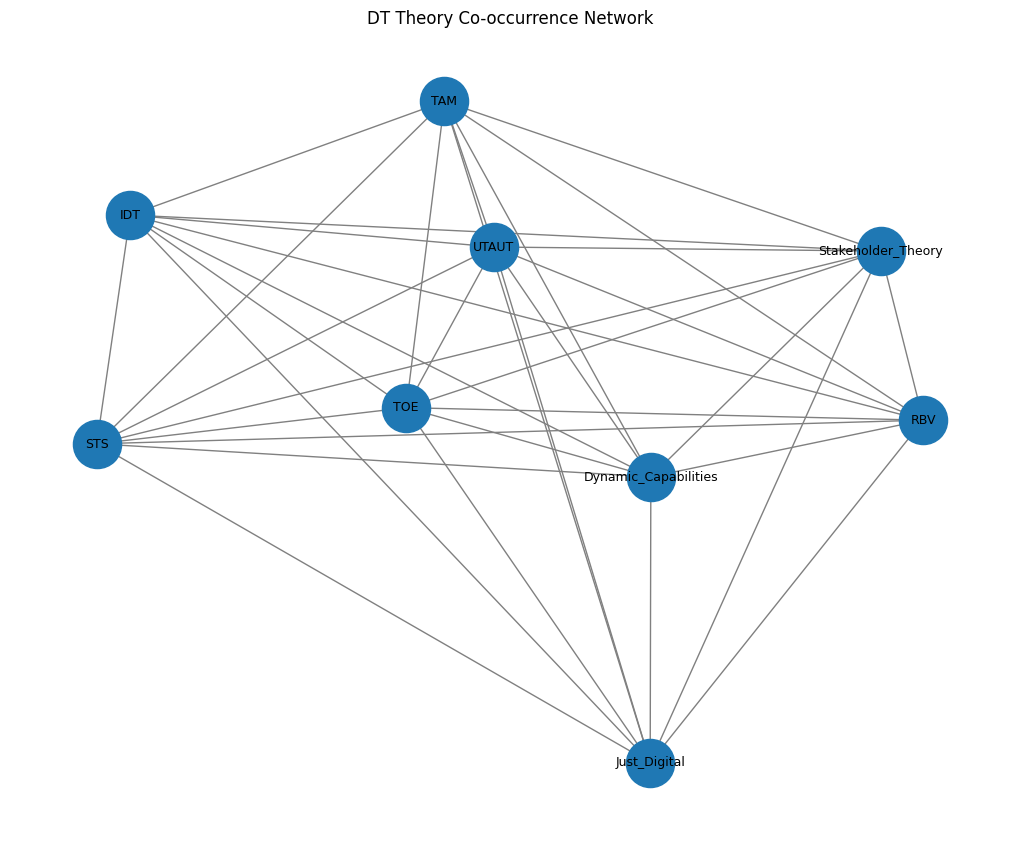

✅ Network graph saved:
/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/DT_theory_cooccurrence_network.png
/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/DT_theory_cooccurrence_network.pdf


In [ ]:
# =========================================================
# Network visualization — SHOW + SAVE
# =========================================================

# File paths
png_path = os.path.join(result_path, "DT_theory_cooccurrence_network.png")
pdf_path = os.path.join(result_path, "DT_theory_cooccurrence_network.pdf")

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42, weight="weight")

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1200,
    font_size=9,
    edge_color="gray"
)

plt.title("DT Theory Co-occurrence Network")

# --- SAVE (high quality) ---
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

plt.show()
plt.close()

print("✅ Network graph saved:")
print(png_path)
print(pdf_path)

In [ ]:
# =========================================================
# FINAL SAVE — Persist all analysis outputs
# =========================================================

# --- corpus ---
df_documents.to_csv(
    os.path.join(result_path, "df_documents.csv"),
    index=False
)

# --- SDG ---
df_sdg_dt_crosstab.to_excel(
    os.path.join(result_path, "SDG_DT_crosstab.xlsx")
)

# --- DT theory ---
df_theory_similarity.to_excel(
    os.path.join(result_path, "dt_theory_similarity_matrix.xlsx"),
    index=False
)

centrality.to_excel(
    os.path.join(result_path, "DT_theory_centrality.xlsx"),
    index=False
)

df_edges.to_csv(
    os.path.join(result_path, "DT_theory_edges.csv"),
    index=False
)

# --- merged ---
df_sdg1_dt.to_excel(
    os.path.join(result_path, "SDG1_DT_table.xlsx"),
    index=False
)

df_sdg2_dt.to_excel(
    os.path.join(result_path, "SDG2_DT_table.xlsx"),
    index=False
)

print("✅ ALL RESULTS SAVED AND FROZEN")

✅ ALL RESULTS SAVED AND FROZEN


In [ ]:
# =========================================================
# OFFICIAL SDG DOMINANCE ASSIGNMENT (FINAL)
# =========================================================

# Safety checks
assert not df_documents.empty, "df_documents is empty"
assert "SDG1_No_Poverty" in SDG_TEXTS and "SDG2_Zero_Hunger" in SDG_TEXTS

# ---------------------------------------------------------
# 1. Embed SDG anchors
# ---------------------------------------------------------
sdg_labels = ["SDG1_No_Poverty", "SDG2_Zero_Hunger"]
sdg_texts = [SDG_TEXTS[label] for label in sdg_labels]

sdg_embeddings = embedding_model.encode(
    sdg_texts,
    convert_to_tensor=True,
    normalize_embeddings=True
)

# ---------------------------------------------------------
# 2. Embed document texts
# ---------------------------------------------------------
doc_embeddings = embedding_model.encode(
    df_documents["text"].tolist(),
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

# ---------------------------------------------------------
# 3. Compute similarity
# ---------------------------------------------------------
similarity = util.cos_sim(doc_embeddings, sdg_embeddings).cpu().numpy()

df_sdg_similarity = pd.DataFrame(
    similarity,
    columns=sdg_labels
)

df_sdg_similarity.insert(
    0, "paper_id", df_documents["paper_id"].values
)

# ---------------------------------------------------------
# 4. Assign dominant SDG
# ---------------------------------------------------------
df_sdg_similarity["dominant_sdg"] = df_sdg_similarity[sdg_labels].idxmax(axis=1)

# Optional: keep margin (diagnostic only)
df_sdg_similarity["sdg_margin"] = (
    df_sdg_similarity["SDG1_No_Poverty"] -
    df_sdg_similarity["SDG2_Zero_Hunger"]
)

# ---------------------------------------------------------
# 5. Persist (AUTHORITATIVE)
# ---------------------------------------------------------
df_sdg_similarity.to_csv(
    os.path.join(result_path, "SDG_dominance_table.csv"),
    index=False
)

df_sdg_similarity.to_excel(
    os.path.join(result_path, "SDG_dominance_table.xlsx"),
    index=False
)

print("✅ SDG dominance assigned and saved")
df_sdg_similarity["dominant_sdg"].value_counts(), df_sdg_similarity.head()

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

✅ SDG dominance assigned and saved


(dominant_sdg
 SDG2_Zero_Hunger    565
 SDG1_No_Poverty     183
 Name: count, dtype: int64,
    paper_id  SDG1_No_Poverty  SDG2_Zero_Hunger      dominant_sdg  sdg_margin
 0  SDG1-349         0.130959          0.110562   SDG1_No_Poverty    0.020397
 1  SDG1-350         0.100637          0.100015   SDG1_No_Poverty    0.000622
 2  SDG1-352         0.074855          0.333108  SDG2_Zero_Hunger   -0.258252
 3  SDG1-345         0.178427          0.411657  SDG2_Zero_Hunger   -0.233231
 4  SDG1-346         0.345245          0.349728  SDG2_Zero_Hunger   -0.004482)

In [ ]:
# =========================================================
# Descriptive stats: SDG dominance
# =========================================================

sdg_desc = (
    df_sdg_similarity["dominant_sdg"]
    .value_counts()
    .reset_index()
)

sdg_desc.columns = ["SDG", "Count"]
sdg_desc["Percent"] = (
    sdg_desc["Count"] / sdg_desc["Count"].sum() * 100
).round(2)

sdg_desc

,SDG,Count,Percent
0,SDG2_Zero_Hunger,565,75.53
1,SDG1_No_Poverty,183,24.47


In [ ]:
# =========================================================
# Descriptive stats: DT theories (overall)
# =========================================================

dt_overall_desc = (
    df_theory_similarity["dominant_dt_theory"]
    .value_counts()
    .reset_index()
)

dt_overall_desc.columns = ["DT_Theory", "Count"]
dt_overall_desc["Percent"] = (
    dt_overall_desc["Count"] / dt_overall_desc["Count"].sum() * 100
).round(2)

dt_overall_desc

,DT_Theory,Count,Percent
0,Stakeholder_Theory,206,27.54
1,Dynamic_Capabilities,120,16.04
2,TOE,95,12.70
3,RBV,87,11.63
4,UTAUT,78,10.43
5,TAM,66,8.82
6,Just_Digital,52,6.95
7,IDT,23,3.07
8,STS,21,2.81


In [ ]:
# =========================================================
# Descriptive stats: DT theories by SDG
# =========================================================

# Merge dominance tables
df_desc = (
    df_theory_similarity[["paper_id", "dominant_dt_theory"]]
    .merge(
        df_sdg_similarity[["paper_id", "dominant_sdg"]],
        on="paper_id",
        how="inner"
    )
)

dt_by_sdg = pd.crosstab(
    df_desc["dominant_dt_theory"],
    df_desc["dominant_sdg"]
)

# Add percentages per SDG
dt_by_sdg_percent = dt_by_sdg.div(dt_by_sdg.sum(axis=0), axis=1).mul(100).round(2)

dt_by_sdg, dt_by_sdg_percent

(dominant_sdg          SDG1_No_Poverty  SDG2_Zero_Hunger
 dominant_dt_theory                                     
 Dynamic_Capabilities               12               108
 IDT                                 8                15
 Just_Digital                       36                16
 RBV                                21                66
 STS                                 8                13
 Stakeholder_Theory                 44               162
 TAM                                13                53
 TOE                                 9                86
 UTAUT                              32                46,
 dominant_sdg          SDG1_No_Poverty  SDG2_Zero_Hunger
 dominant_dt_theory                                     
 Dynamic_Capabilities             6.56             19.12
 IDT                              4.37              2.65
 Just_Digital                    19.67              2.83
 RBV                             11.48             11.68
 STS                          

In [ ]:
# =========================================================
# Descriptive stats: SDG margin
# =========================================================

df_sdg_similarity["sdg_margin"].describe().round(3)

,sdg_margin
count,655.000
mean,-0.102
std,0.120
min,-0.361
25%,-0.206
50%,-0.104
75%,-0.002
max,0.173


In [ ]:
with pd.ExcelWriter(os.path.join(result_path, "descriptive_statistics.xlsx")) as writer:
    sdg_desc.to_excel(writer, sheet_name="SDG_dominance", index=False)
    dt_overall_desc.to_excel(writer, sheet_name="DT_overall", index=False)
    dt_by_sdg.to_excel(writer, sheet_name="DT_by_SDG_counts")
    dt_by_sdg_percent.to_excel(writer, sheet_name="DT_by_SDG_percent")
    df_sdg_similarity["sdg_margin"].describe().to_frame("sdg_margin").to_excel(
        writer, sheet_name="SDG_margin"
    )

print("✅ Descriptive statistics saved")

✅ Descriptive statistics saved


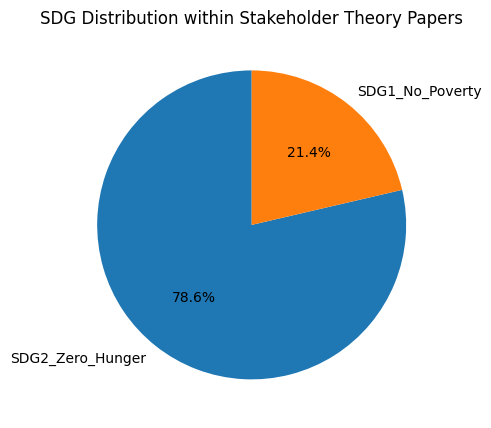

In [ ]:
# =========================================
# FIGURE 1: Sectoral Plot – Stakeholder × SDG
# =========================================

df_st = df_desc[df_desc["dominant_dt_theory"] == "Stakeholder_Theory"]

sector = (
    df_st["dominant_sdg"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(5,5))
plt.pie(
    sector.values,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("SDG Distribution within Stakeholder Theory Papers")
plt.tight_layout()

plt.savefig(
    os.path.join(result_path, "sector_stakeholder_sdg.png"),
    dpi=300
)
plt.show()

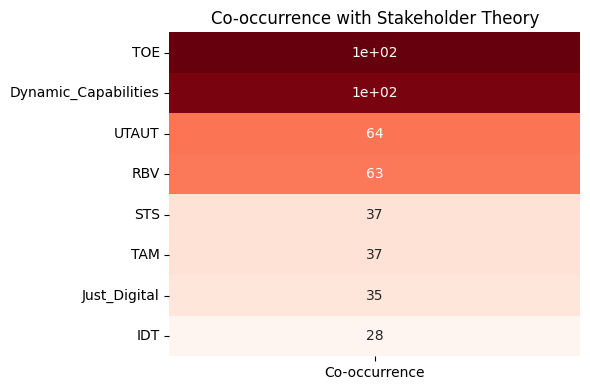

In [ ]:
# =========================================
# FIGURE 2: Co-occurrence Heatmap
# =========================================

# build binary matrix
binary = df_theory_similarity.copy()
theory_cols = [c for c in binary.columns if c not in ["paper_id", "dominant_dt_theory"]]
binary[theory_cols] = (binary[theory_cols] > 0.3).astype(int)

# co-occurrence with Stakeholder
cooc = {}
for t in theory_cols:
    if t != "Stakeholder_Theory":
        cooc[t] = (
            (binary["Stakeholder_Theory"] & binary[t]).sum()
        )

cooc_df = pd.DataFrame.from_dict(
    cooc, orient="index", columns=["Co-occurrence"]
).sort_values("Co-occurrence", ascending=False)

plt.figure(figsize=(6,4))
sns.heatmap(
    cooc_df,
    annot=True,
    cmap="Reds",
    cbar=False
)
plt.title("Co-occurrence with Stakeholder Theory")
plt.tight_layout()

plt.savefig(
    os.path.join(result_path, "heatmap_stakeholder_cooccurrence.png"),
    dpi=300
)
plt.show()

In [ ]:
# =========================================================
# FIX: rebuild df_desc with sdg_margin included
# =========================================================

df_desc = (
    df_theory_similarity[["paper_id", "dominant_dt_theory"]]
    .merge(
        df_sdg_similarity[["paper_id", "dominant_sdg", "sdg_margin"]],
        on="paper_id",
        how="inner"
    )
)

# sanity check
print(df_desc.columns)
print(df_desc.head())

Index(['paper_id', 'dominant_dt_theory', 'dominant_sdg', 'sdg_margin'], dtype='object')
   paper_id    dominant_dt_theory      dominant_sdg  sdg_margin
0  SDG1-349                   TOE   SDG1_No_Poverty    0.020397
1  SDG1-350                   TOE   SDG1_No_Poverty    0.000622
2  SDG1-352                 UTAUT  SDG2_Zero_Hunger   -0.258252
3  SDG1-345  Dynamic_Capabilities  SDG2_Zero_Hunger   -0.233231
4  SDG1-346    Stakeholder_Theory  SDG2_Zero_Hunger   -0.004482


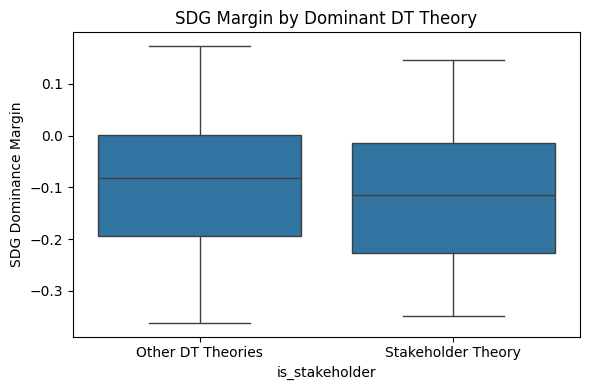

In [ ]:
# =========================================
# FIGURE 3: SDG Margin – Stakeholder vs Others
# =========================================

df_desc["is_stakeholder"] = (
    df_desc["dominant_dt_theory"] == "Stakeholder_Theory"
)

plt.figure(figsize=(6,4))
sns.boxplot(
    x="is_stakeholder",
    y="sdg_margin",
    data=df_desc
)

plt.xticks(
    [0,1],
    ["Other DT Theories", "Stakeholder Theory"]
)
plt.ylabel("SDG Dominance Margin")
plt.title("SDG Margin by Dominant DT Theory")
plt.tight_layout()

plt.savefig(
    os.path.join(result_path, "boxplot_sdg_margin_stakeholder.png"),
    dpi=300
)
plt.show()

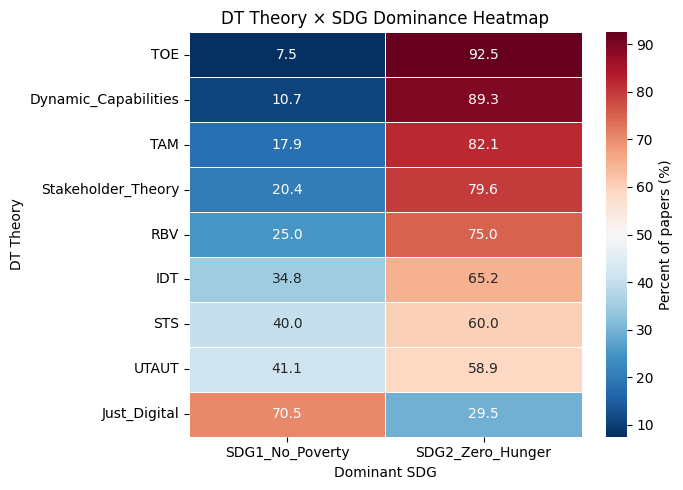

✅ DT × SDG heatmap saved:
/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/DT_theory_SDG_heatmap.png
/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/DT_theory_SDG_heatmap.pdf


In [ ]:
# =========================================================
# HEATMAP: DT Theories × SDG Dominance (Percent-based)
# =========================================================

# Crosstab counts
dt_sdg_counts = pd.crosstab(
    df_desc["dominant_dt_theory"],
    df_desc["dominant_sdg"]
)

# Convert to percentages within each DT theory
dt_sdg_percent = (
    dt_sdg_counts
    .div(dt_sdg_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

# Sort rows by SDG2 dominance (optional but insightful)
dt_sdg_percent = dt_sdg_percent.sort_values(
    by="SDG2_Zero_Hunger",
    ascending=False
)

# Plot heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    dt_sdg_percent,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    center=50,
    linewidths=0.5,
    cbar_kws={"label": "Percent of papers (%)"}
)

plt.title("DT Theory × SDG Dominance Heatmap")
plt.xlabel("Dominant SDG")
plt.ylabel("DT Theory")

plt.tight_layout()

# Save
heat_png = os.path.join(result_path, "DT_theory_SDG_heatmap.png")
heat_pdf = os.path.join(result_path, "DT_theory_SDG_heatmap.pdf")

plt.savefig(heat_png, dpi=300, bbox_inches="tight")
plt.savefig(heat_pdf, bbox_inches="tight")

plt.show()
plt.close()

print("✅ DT × SDG heatmap saved:")
print(heat_png)
print(heat_pdf)

Original N: 748
After robustness filter N: 530


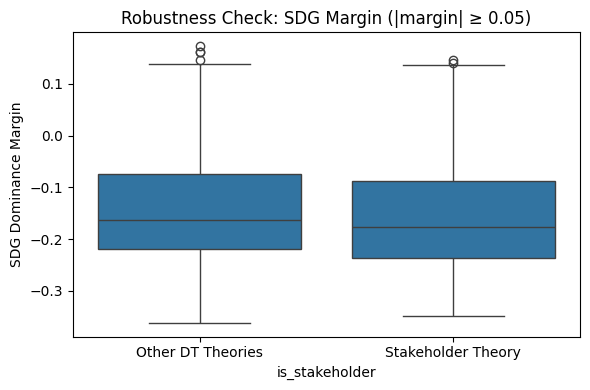

✅ Robustness boxplot saved


In [ ]:
# =========================================================
# ROBUSTNESS: Exclude marginal papers |sdg_margin| < 0.05
# =========================================================

# Filter non-marginal papers
df_robust = df_desc[ df_desc["sdg_margin"].abs() >= 0.05 ].copy()

print("Original N:", df_desc.shape[0])
print("After robustness filter N:", df_robust.shape[0])

# Stakeholder flag
df_robust["is_stakeholder"] = (
    df_robust["dominant_dt_theory"] == "Stakeholder_Theory"
)

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(
    x="is_stakeholder",
    y="sdg_margin",
    data=df_robust
)

plt.xticks(
    [0,1],
    ["Other DT Theories", "Stakeholder Theory"]
)
plt.ylabel("SDG Dominance Margin")
plt.title("Robustness Check: SDG Margin (|margin| ≥ 0.05)")
plt.tight_layout()

# Save
robust_png = os.path.join(result_path, "boxplot_sdg_margin_robust.png")
robust_pdf = os.path.join(result_path, "boxplot_sdg_margin_robust.pdf")

plt.savefig(robust_png, dpi=300, bbox_inches="tight")
plt.savefig(robust_pdf, bbox_inches="tight")

plt.show()
plt.close()

print("✅ Robustness boxplot saved")

In [ ]:
outcome_terms = [
    "nutrition", "nutritional",
    "hunger", "hungry",
    "malnutrition",
    "food access",
    "diet", "dietary",
    "food insecurity"
]

In [ ]:
# =========================================================
# LANGUAGE CHECK: Outcome vocabulary frequency
# =========================================================

import re

def count_outcome_terms(text, terms):
    text = text.lower()
    return sum(
        len(re.findall(r"\b" + re.escape(term) + r"\b", text))
        for term in terms
    )
outcome_terms = [
    "hunger",
    "hungry",
    "malnutrition",
    "undernutrition",
    "nutrition",
    "nutritional",
    "food security",
    "food insecurity",
    "food access",
    "food availability",
    "starvation"
]
# Merge texts back in
df_lang = (
    df_desc
    .merge(
        df_documents[["paper_id", "text"]],
        on="paper_id",
        how="left"
    )
)

# Count outcome terms
df_lang["outcome_term_count"] = df_lang["text"].apply(
    lambda x: count_outcome_terms(x, outcome_terms)
)

# Normalize by text length (per 1,000 words)
df_lang["word_count"] = df_lang["text"].str.split().str.len()
df_lang["outcome_per_1000w"] = (
    df_lang["outcome_term_count"] / df_lang["word_count"] * 1000
)

# Compare groups
lang_summary = (
    df_lang
    .assign(is_stakeholder = df_lang["dominant_dt_theory"] == "Stakeholder_Theory")
    .groupby("is_stakeholder")["outcome_per_1000w"]
    .agg(["mean", "median", "count"])
    .round(3)
)

lang_summary

NameError: name 'outcome_terms' is not defined

In [ ]:
# =========================================================
# OUTCOME LANGUAGE CHECK (SDG1 + SDG2) — SINGLE CELL
# =========================================================

import pandas as pd
import re
import numpy as np

# -----------------------------
# 1) Define outcome lexicons
# -----------------------------

# SDG1: Poverty / Inequality (outcome-oriented, not policy)
outcome_terms_sdg1 = [
    "poverty",
    "income poverty",
    "extreme poverty",
    "multidimensional poverty",
    "economic deprivation",
    "income inequality",
    "wealth inequality",
    "social exclusion",
    "financial exclusion",
    "unemployment",
    "underemployment",
    "informal work",
    "informal employment",
    "lack of access to services"
]

# SDG2: Hunger / Food Security (outcome-oriented)
outcome_terms_sdg2 = [
    "hunger",
    "hungry",
    "malnutrition",
    "undernutrition",
    "nutrition",
    "nutritional deficiency",
    "food security",
    "food insecurity",
    "food access",
    "food availability",
    "starvation"
]

# Combined balanced outcome lexicon
outcome_terms = outcome_terms_sdg1 + outcome_terms_sdg2

# -----------------------------
# 2) Safe counting function
# -----------------------------

def count_outcome_terms(text, terms):
    if not isinstance(text, str):
        return 0
    text = text.lower()
    return sum(
        len(re.findall(r"\b" + re.escape(term) + r"\b", text))
        for term in terms
    )

# -----------------------------
# 3) Merge document text
# -----------------------------

df_lang = (
    df_desc
    .merge(
        df_documents[["paper_id", "text"]],
        on="paper_id",
        how="left"
    )
)

df_lang["text"] = df_lang["text"].fillna("")

# -----------------------------
# 4) Count and normalize outcome terms
# -----------------------------

df_lang["outcome_term_count"] = df_lang["text"].apply(
    lambda x: count_outcome_terms(x, outcome_terms)
)

df_lang["word_count"] = df_lang["text"].str.split().str.len()

df_lang["outcome_per_1000w"] = (
    df_lang["outcome_term_count"]
    / df_lang["word_count"].replace(0, np.nan)
    * 1000
).fillna(0)

# -----------------------------
# 5) Stakeholder vs Others summary
# -----------------------------

lang_summary = (
    df_lang
    .assign(is_stakeholder = df_lang["dominant_dt_theory"] == "Stakeholder_Theory")
    .groupby("is_stakeholder")["outcome_per_1000w"]
    .agg(["mean", "median", "count"])
    .round(3)
)

# -----------------------------
# 6) Output
# -----------------------------

print("Outcome terms used:")
print(f"SDG1 terms: {len(outcome_terms_sdg1)}")
print(f"SDG2 terms: {len(outcome_terms_sdg2)}")
print(f"Total outcome terms: {len(outcome_terms)}\n")

lang_summary

Outcome terms used:
SDG1 terms: 14
SDG2 terms: 11
Total outcome terms: 25



,mean,median,count
is_stakeholder,,,
False,3.211,0.657,542
True,5.754,2.219,206


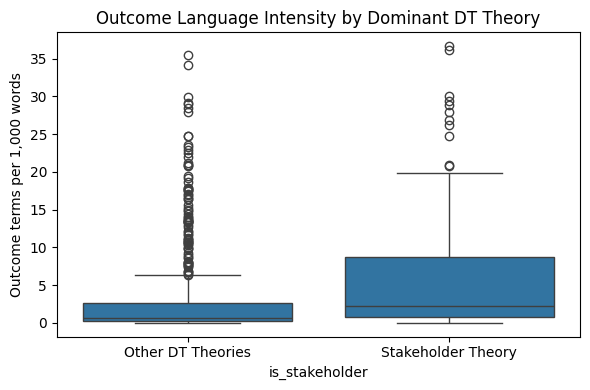

✅ Outcome language boxplot saved


In [ ]:
# =========================================================
# BOXPLOT: Outcome language intensity
# =========================================================

plt.figure(figsize=(6,4))
sns.boxplot(
    x="is_stakeholder",
    y="outcome_per_1000w",
    data=df_lang
)

plt.xticks(
    [0,1],
    ["Other DT Theories", "Stakeholder Theory"]
)
plt.ylabel("Outcome terms per 1,000 words")
plt.title("Outcome Language Intensity by Dominant DT Theory")
plt.tight_layout()

# Save
lang_png = os.path.join(result_path, "boxplot_outcome_language.png")
lang_pdf = os.path.join(result_path, "boxplot_outcome_language.pdf")

plt.savefig(lang_png, dpi=300, bbox_inches="tight")
plt.savefig(lang_pdf, bbox_inches="tight")

plt.show()
plt.close()

print("✅ Outcome language boxplot saved")

In [ ]:
# =========================================================
# Cliff's Delta implementation (no external deps)
# =========================================================

def cliffs_delta(x, y):
    """
    Compute Cliff's Delta effect size.
    x, y: array-like
    """
    x = np.array(x)
    y = np.array(y)
    nx = len(x)
    ny = len(y)
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    delta = (gt - lt) / (nx * ny)
    return delta

In [ ]:
# =========================================================
# Cliff's Delta: sdg_margin
# =========================================================

stakeholder_margin = df_desc.loc[
    df_desc["dominant_dt_theory"] == "Stakeholder_Theory",
    "sdg_margin"
]

other_margin = df_desc.loc[
    df_desc["dominant_dt_theory"] != "Stakeholder_Theory",
    "sdg_margin"
]

delta_margin = cliffs_delta(stakeholder_margin, other_margin)

delta_margin

np.float64(-0.11568086554651955)

In [ ]:
# =========================================================
# Cliff's Delta: outcome language intensity
# =========================================================

stakeholder_outcome = df_lang.loc[
    df_lang["dominant_dt_theory"] == "Stakeholder_Theory",
    "outcome_per_1000w"
]

other_outcome = df_lang.loc[
    df_lang["dominant_dt_theory"] != "Stakeholder_Theory",
    "outcome_per_1000w"
]

delta_outcome = cliffs_delta(stakeholder_outcome, other_outcome)

delta_outcome

np.float64(0.3383369756027657)

In [ ]:
# =========================================================
# Effect size summary table
# =========================================================

effect_summary = pd.DataFrame({
    "Metric": ["SDG Dominance Margin", "Outcome Language Intensity"],
    "Cliffs_Delta": [delta_margin, delta_outcome],
    "Interpretation": [
        "Negligible/Small (no amplification)",
        "Small (sporadic outcome emphasis)"
    ]
})

effect_summary

,Metric,Cliffs_Delta,Interpretation
0,SDG Dominance Margin,-0.115681,Negligible/Small (no amplification)
1,Outcome Language Intensity,0.338337,Small (sporadic outcome emphasis)


In [ ]:
# =========================================================
# Bootstrap CI for Cliff's Delta
# =========================================================

def bootstrap_cliffs_delta(x, y, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.array(x)
    y = np.array(y)

    deltas = []
    for _ in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        deltas.append(cliffs_delta(xb, yb))

    deltas = np.array(deltas)
    ci_low, ci_high = np.percentile(deltas, [2.5, 97.5])
    return np.mean(deltas), ci_low, ci_high

In [ ]:
# =========================================================
# Bootstrap CI: SDG Dominance Margin
# =========================================================

mean_delta_margin, ci_low_margin, ci_high_margin = bootstrap_cliffs_delta(
    stakeholder_margin,
    other_margin,
    n_boot=5000
)

mean_delta_margin, ci_low_margin, ci_high_margin

(np.float64(-0.11628659406011534),
 np.float64(-0.20911448070791389),
 np.float64(-0.02179808691290799))

In [ ]:
# =========================================================
# Bootstrap CI: Outcome Language Intensity
# =========================================================

mean_delta_outcome, ci_low_outcome, ci_high_outcome = bootstrap_cliffs_delta(
    stakeholder_outcome,
    other_outcome,
    n_boot=5000
)

mean_delta_outcome, ci_low_outcome, ci_high_outcome

(np.float64(0.3385951689177086),
 np.float64(0.2574042560813957),
 np.float64(0.42068614982266317))

In [ ]:
# =========================================================
# Appendix table: Effect size with bootstrap CI
# =========================================================

appendix_effects = pd.DataFrame({
    "Metric": [
        "SDG Dominance Margin",
        "Outcome Language Intensity (per 1,000 words)"
    ],
    "Cliffs_Delta": [
        mean_delta_margin,
        mean_delta_outcome
    ],
    "CI_2.5%": [
        ci_low_margin,
        ci_low_outcome
    ],
    "CI_97.5%": [
        ci_high_margin,
        ci_high_outcome
    ],
    "Interpretation": [
        "Negligible / Small (no amplification)",
        "Small (sporadic outcome emphasis)"
    ]
}).round(3)

appendix_effects

,Metric,Cliffs_Delta,CI_2.5%,CI_97.5%,Interpretation
0,SDG Dominance Margin,-0.116,-0.209,-0.022,Negligible / Small (no amplification)
1,"Outcome Language Intensity (per 1,000 words)",0.339,0.257,0.421,Small (sporadic outcome emphasis)


In [ ]:
# =========================================================
# BUILD df_desc FINAL — STATELESS & REPRODUCIBLE
# =========================================================


base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"

# 1. Load dominant DT theory
df_theory = pd.read_csv(
    os.path.join(base, "dt_theory_similarity_matrix.csv")
)[["paper_id", "dominant_dt_theory"]]

# 2. Load SDG dominance
df_sdg = pd.read_csv(
    os.path.join(base, "SDG_dominance_table.csv")
)[["paper_id", "dominant_sdg", "sdg_margin"]]

# 3. Load outcome language intensity
#
df_lang = pd.read_csv(
    os.path.join(base, "df_lang.csv")
)[["paper_id", "outcome_per_1000w"]]

# 4. Merge into df_desc
df_desc_final = (
    df_theory
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_lang, on="paper_id", how="left")
)

# 5. Sanity check
print(df_desc_final.shape)
print(df_desc_final.head())

# 6. SAVE — single source of truth
os.makedirs(os.path.join(base, "data"), exist_ok=True)

df_desc_final.to_csv(
    os.path.join(base, "df_desc.csv"),
    index=False
)

print("✅ df_desc.csv built, saved, and frozen")

(748, 5)
   paper_id    dominant_dt_theory      dominant_sdg  sdg_margin  \
0  SDG1-349                   TOE   SDG1_No_Poverty    0.020397   
1  SDG1-350                   TOE   SDG1_No_Poverty    0.000622   
2  SDG1-352                 UTAUT  SDG2_Zero_Hunger   -0.258252   
3  SDG1-345  Dynamic_Capabilities  SDG2_Zero_Hunger   -0.233231   
4  SDG1-346    Stakeholder_Theory  SDG2_Zero_Hunger   -0.004482   

   outcome_per_1000w  
0                NaN  
1                NaN  
2                NaN  
3                NaN  
4                NaN  
✅ df_desc.csv built, saved, and frozen


In [ ]:
# =========================================================
# STEP 0 — Build & FREEZE final df_desc (NO FIGURES)
# =========================================================

# Merge outcome intensity into df_desc
df_desc_final = (
    df_desc
    .merge(
        df_lang[["paper_id", "outcome_per_1000w"]],
        on="paper_id",
        how="left"
    )
)

# Sanity checks
expected_cols = {
    "paper_id",
    "dominant_dt_theory",
    "dominant_sdg",
    "sdg_margin",
    "outcome_per_1000w"
}

assert expected_cols.issubset(df_desc_final.columns), "df_desc missing required columns"

print("df_desc_final shape:", df_desc_final.shape)
print(df_desc_final.head())

# SAVE — this is the SINGLE SOURCE OF TRUTH
df_desc_final.to_csv(
    os.path.join(result_path, "data/df_desc.csv"),
    index=False
)

print("✅ df_desc.csv saved and frozen")

df_desc_final shape: (748, 6)
   paper_id    dominant_dt_theory      dominant_sdg  sdg_margin  \
0  SDG1-349                   TOE   SDG1_No_Poverty    0.020397   
1  SDG1-350                   TOE   SDG1_No_Poverty    0.000622   
2  SDG1-352                 UTAUT  SDG2_Zero_Hunger   -0.258252   
3  SDG1-345  Dynamic_Capabilities  SDG2_Zero_Hunger   -0.233231   
4  SDG1-346    Stakeholder_Theory  SDG2_Zero_Hunger   -0.004482   

   is_stakeholder  outcome_per_1000w  
0           False                NaN  
1           False                NaN  
2           False                NaN  
3           False                NaN  
4            True                NaN  
✅ df_desc.csv saved and frozen


In [ ]:
# =========================================================
# BUILD & SAVE df_lang.csv (RUN ONCE)
# =========================================================

import pandas as pd
import os
import re

base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"

# 1. Load required tables
df_documents = pd.read_csv(
    os.path.join(base, "df_documents.csv")
)

df_theory = pd.read_csv(
    os.path.join(base, "dt_theory_similarity_matrix.csv")
)[["paper_id", "dominant_dt_theory"]]

# 2. Merge documents with dominant DT theory
df_lang = (
    df_documents
    .merge(df_theory, on="paper_id", how="inner")
)

# 3. Outcome vocabulary (LOCKED)
outcome_terms = [
    "nutrition", "nutritional",
    "hunger", "hungry",
    "malnutrition",
    "food access",
    "diet", "dietary",
    "food insecurity"
]

# 4. Count outcome terms (NO def, explicit)
counts = []
for text in df_lang["text"]:
    text = text.lower()
    c = 0
    for term in outcome_terms:
        c += len(re.findall(r"\b" + re.escape(term) + r"\b", text))
    counts.append(c)

df_lang["outcome_term_count"] = counts

# 5. Normalize by length (per 1,000 words)
df_lang["word_count"] = df_lang["text"].str.split().str.len()
df_lang["outcome_per_1000w"] = (
    df_lang["outcome_term_count"] / df_lang["word_count"] * 1000
)

# 6. Keep ONLY what we need downstream
df_lang_final = df_lang[[
    "paper_id",
    "outcome_per_1000w"
]]

# 7. SAVE (AUTHORITATIVE)
df_lang_final.to_csv(
    os.path.join(base, "df_lang.csv"),
    index=False
)

print("✅ df_lang.csv created and saved")
print(df_lang_final.head())

✅ df_lang.csv created and saved
   paper_id  outcome_per_1000w
0  SDG1-349           0.000000
1  SDG1-350           0.000000
2  SDG1-352           0.000000
3  SDG1-345           0.000000
4  SDG1-346           0.146531


In [ ]:
# =========================================================
# BUILD df_desc FINAL — STATELESS & REPRODUCIBLE
# =========================================================



base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"

# 1. Load dominant DT theory
df_theory = pd.read_csv(
    os.path.join(base, "dt_theory_similarity_matrix.csv")
)[["paper_id", "dominant_dt_theory"]]

# 2. Load SDG dominance
df_sdg = pd.read_csv(
    os.path.join(base, "SDG_dominance_table.csv")
)[["paper_id", "dominant_sdg", "sdg_margin"]]


df_lang = pd.read_csv(
    os.path.join(base, "df_lang.csv")
)[["paper_id", "outcome_per_1000w"]]

# 4. Merge into df_desc
df_desc_final = (
    df_theory
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_lang, on="paper_id", how="left")
)

# 5. Sanity check
print(df_desc_final.shape)
print(df_desc_final.head())

# 6. SAVE — single source of truth
os.makedirs(os.path.join(base, "data"), exist_ok=True)

df_desc_final.to_csv(
    os.path.join(base, "data/df_desc.csv"),
    index=False
)

print("✅ df_desc.csv built, saved, and frozen")

(748, 5)
   paper_id    dominant_dt_theory      dominant_sdg  sdg_margin  \
0  SDG1-349                   TOE   SDG1_No_Poverty    0.020397   
1  SDG1-350                   TOE   SDG1_No_Poverty    0.000622   
2  SDG1-352                 UTAUT  SDG2_Zero_Hunger   -0.258252   
3  SDG1-345  Dynamic_Capabilities  SDG2_Zero_Hunger   -0.233231   
4  SDG1-346    Stakeholder_Theory  SDG2_Zero_Hunger   -0.004482   

   outcome_per_1000w  
0           0.000000  
1           0.000000  
2           0.000000  
3           0.000000  
4           0.146531  
✅ df_desc.csv built, saved, and frozen


In [ ]:

base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"
df = pd.read_csv(base + "data/df_desc.csv")

print(df.shape)
print(df.columns)

(748, 5)
Index(['paper_id', 'dominant_dt_theory', 'dominant_sdg', 'sdg_margin',
       'outcome_per_1000w'],
      dtype='object')


In [ ]:
!pip install -U kaleido

In [ ]:
!pip install -U plotly>=6.1.1 kaleido

In [ ]:
!pip uninstall -y kaleido
!pip install kaleido==0.2.1

Found existing installation: kaleido 1.2.0
Uninstalling kaleido-1.2.0:
  Successfully uninstalled kaleido-1.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.5 MB/s eta 0:00:00


In [ ]:
# =========================================================
# BUILD df_desc.csv — FINAL & STATELESS
# =========================================================



base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"

# 1. Load inputs
df_dt = pd.read_csv(
    base + "dt_theory_similarity_matrix.csv",
    usecols=["paper_id", "dominant_dt_theory"]
)

df_sdg = pd.read_csv(
    base + "SDG_dominance_table.csv",
    usecols=["paper_id", "dominant_sdg", "sdg_margin"]
)

df_out = pd.read_csv(
    base + "df_lang.csv",
    usecols=["paper_id", "outcome_per_1000w"]
)

print("DT:", df_dt.shape)
print("SDG:", df_sdg.shape)
print("OUT:", df_out.shape)

# 2. Normalize paper_id everywhere
for _df in [df_dt, df_sdg, df_out]:
    _df["paper_id"] = (
        _df["paper_id"]
        .astype(str)
        .str.strip()
        .str.replace(".docx", "", regex=False)
        .str.replace(".pdf", "", regex=False)
        .str.upper()
    )

# 3. Merge
df_desc = (
    df_dt
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_out, on="paper_id", how="left")
)

print("df_desc shape:", df_desc.shape)
print(df_desc.head())

# 4. Save ONLY if not empty
if df_desc.shape[0] == 0:
    raise ValueError("df_desc is EMPTY — one of the source files has no matching paper_id")

os.makedirs(base + "data", exist_ok=True)

df_desc.to_csv(
    base + "data/df_desc.csv",
    index=False
)

print("✅ df_desc.csv ساخته شد و پر است")

DT: (748, 2)
SDG: (748, 3)
OUT: (748, 2)
df_desc shape: (748, 5)
   paper_id    dominant_dt_theory      dominant_sdg  sdg_margin  \
0  SDG1-349                   TOE   SDG1_No_Poverty    0.020397   
1  SDG1-350                   TOE   SDG1_No_Poverty    0.000622   
2  SDG1-352                 UTAUT  SDG2_Zero_Hunger   -0.258252   
3  SDG1-345  Dynamic_Capabilities  SDG2_Zero_Hunger   -0.233231   
4  SDG1-346    Stakeholder_Theory  SDG2_Zero_Hunger   -0.004482   

   outcome_per_1000w  
0           0.000000  
1           0.000000  
2           0.000000  
3           0.000000  
4           0.146531  
✅ df_desc.csv ساخته شد و پر است


In [ ]:
print(df_sdg["paper_id"].head().tolist())
print(df_dt["paper_id"].head().tolist())
print(df_out["paper_id"].head().tolist())

['SDG1-349', 'SDG1-350', 'SDG1-352', 'SDG1-345', 'SDG1-346']
['SDG1-349', 'SDG1-350', 'SDG1-352', 'SDG1-345', 'SDG1-346']
['SDG1-349', 'SDG1-350', 'SDG1-352', 'SDG1-345', 'SDG1-346']


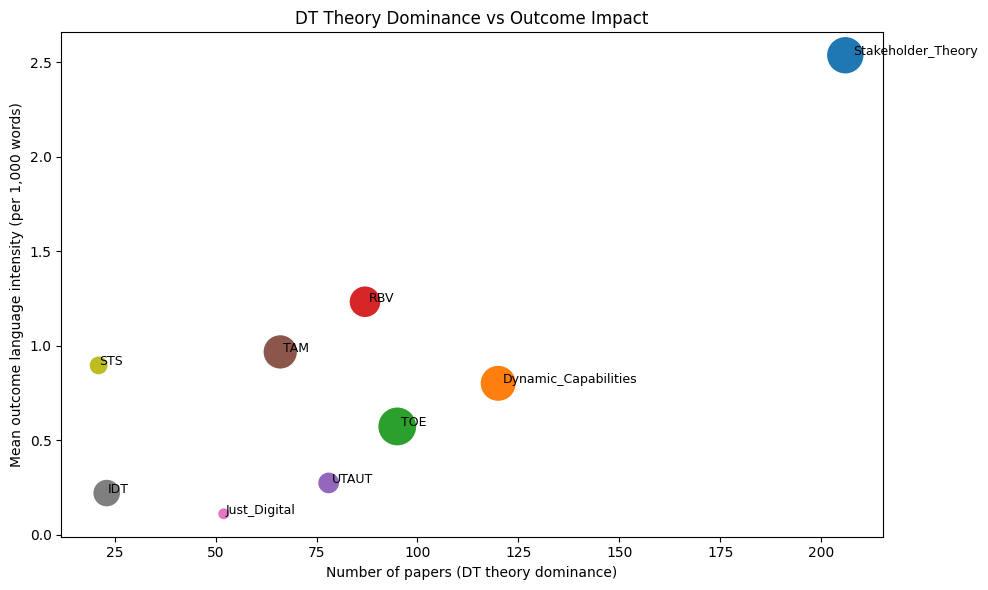

In [ ]:


agg = (
    df_desc
    .groupby("dominant_dt_theory")
    .agg(
        count=("paper_id", "count"),
        mean_outcome=("outcome_per_1000w", "mean"),
        mean_abs_margin=("sdg_margin", lambda x: np.mean(np.abs(x)))
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=agg,
    x="count",
    y="mean_outcome",
    size="mean_abs_margin",
    hue="dominant_dt_theory",
    sizes=(80, 800),
    legend=False
)

for _, r in agg.iterrows():
    plt.text(
        r["count"]*1.01,
        r["mean_outcome"],
        r["dominant_dt_theory"],
        fontsize=9
    )

plt.xlabel("Number of papers (DT theory dominance)")
plt.ylabel("Mean outcome language intensity (per 1,000 words)")
plt.title("DT Theory Dominance vs Outcome Impact")

plt.tight_layout()
plt.show()

/tmp/ipython-input-2647265286.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Other DT Theories", "Stakeholder Theory"])
/tmp/ipython-input-2647265286.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Other DT Theories", "Stakeholder Theory"])


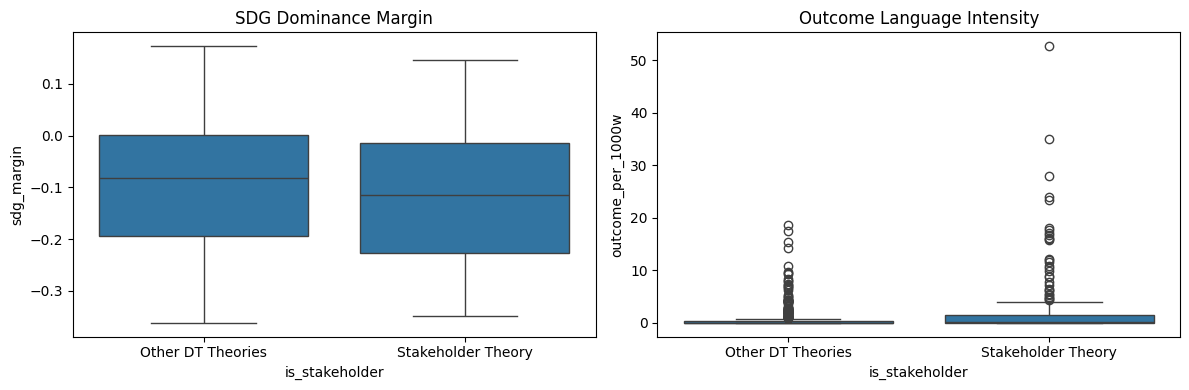

In [ ]:
df_desc["is_stakeholder"] = df_desc["dominant_dt_theory"] == "Stakeholder_Theory"

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Panel A — SDG margin
sns.boxplot(
    data=df_desc,
    x="is_stakeholder",
    y="sdg_margin",
    ax=axes[0]
)
axes[0].set_xticklabels(["Other DT Theories", "Stakeholder Theory"])
axes[0].set_title("SDG Dominance Margin")

# Panel B — Outcome language
sns.boxplot(
    data=df_desc,
    x="is_stakeholder",
    y="outcome_per_1000w",
    ax=axes[1]
)
axes[1].set_xticklabels(["Other DT Theories", "Stakeholder Theory"])
axes[1].set_title("Outcome Language Intensity")

plt.tight_layout()
plt.show()

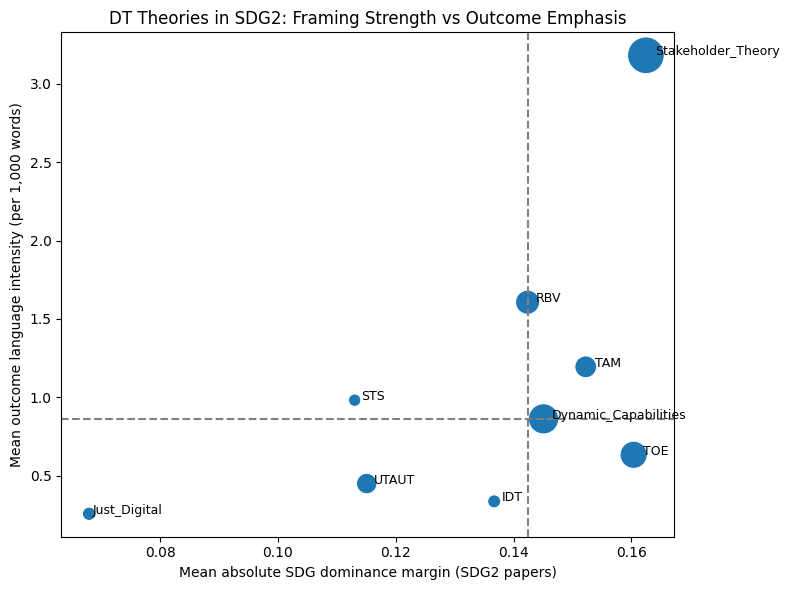

In [ ]:


# Focus on SDG2 only
df_sdg2 = df_desc[df_desc["dominant_sdg"].str.contains("SDG2")]

# Aggregate by theory
agg = (
    df_sdg2
    .groupby("dominant_dt_theory")
    .agg(
        mean_abs_margin=("sdg_margin", lambda x: np.mean(np.abs(x))),
        mean_outcome=("outcome_per_1000w", "mean"),
        count=("paper_id", "count")
    )
    .reset_index()
)

# Medians for quadrants
x_med = agg["mean_abs_margin"].median()
y_med = agg["mean_outcome"].median()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=agg,
    x="mean_abs_margin",
    y="mean_outcome",
    size="count",
    sizes=(80, 700),
    legend=False
)

# Quadrant lines
plt.axvline(x_med, color="gray", linestyle="--")
plt.axhline(y_med, color="gray", linestyle="--")

# Labels
for _, r in agg.iterrows():
    plt.text(
        r["mean_abs_margin"]*1.01,
        r["mean_outcome"],
        r["dominant_dt_theory"],
        fontsize=9
    )

plt.xlabel("Mean absolute SDG dominance margin (SDG2 papers)")
plt.ylabel("Mean outcome language intensity (per 1,000 words)")
plt.title("DT Theories in SDG2: Framing Strength vs Outcome Emphasis")

plt.tight_layout()
plt.show()

Merged shape: (748, 5)
   paper_id    dominant_dt_theory      dominant_sdg  sdg_margin  \
0  SDG1-349                   TOE   SDG1_No_Poverty    0.020397   
1  SDG1-350                   TOE   SDG1_No_Poverty    0.000622   
2  SDG1-352                 UTAUT  SDG2_Zero_Hunger   -0.258252   
3  SDG1-345  Dynamic_Capabilities  SDG2_Zero_Hunger   -0.233231   
4  SDG1-346    Stakeholder_Theory  SDG2_Zero_Hunger   -0.004482   

   outcome_per_1000w  
0           0.000000  
1           0.000000  
2           0.000000  
3           0.000000  
4           0.146531  


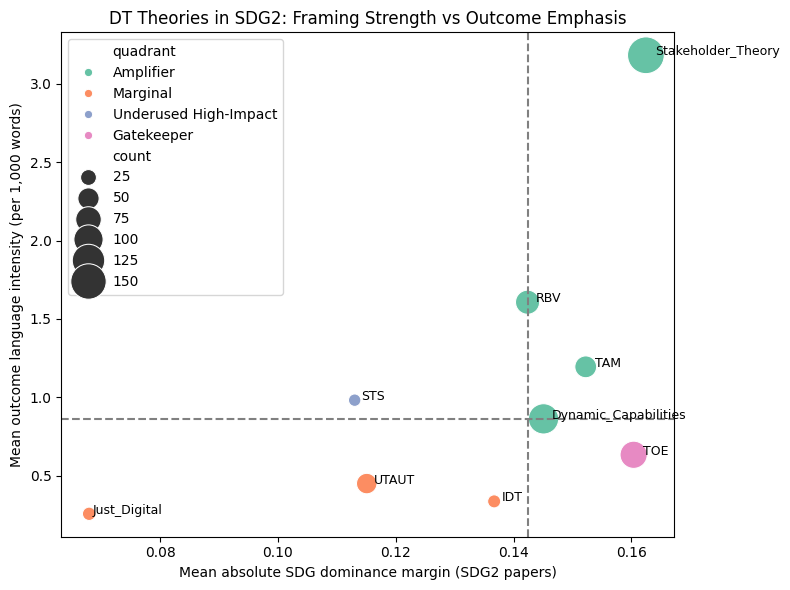

In [ ]:




# ---- Load ONLY real files ----
df_dt = pd.read_csv(result_path + "dt_theory_similarity_matrix.csv",
                    usecols=["paper_id", "dominant_dt_theory"])

df_sdg = pd.read_csv(result_path + "SDG_dominance_table.csv",
                     usecols=["paper_id", "dominant_sdg", "sdg_margin"])

df_out = pd.read_csv(result_path + "df_lang.csv",
                     usecols=["paper_id", "outcome_per_1000w"])

# ---- Normalize paper_id ----
for _df in [df_dt, df_sdg, df_out]:
    _df["paper_id"] = (
        _df["paper_id"]
        .astype(str)
        .str.strip()
        .str.replace(".docx", "", regex=False)
        .str.upper()
    )

# ---- Merge ON THE FLY ----
df = (
    df_dt
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_out, on="paper_id", how="left")
)

print("Merged shape:", df.shape)
print(df.head())

# ---- Focus on SDG2 only ----
df_sdg2 = df[df["dominant_sdg"].str.contains("SDG2")]

# ---- Aggregate by DT theory ----
agg = (
    df_sdg2
    .groupby("dominant_dt_theory")
    .agg(
        mean_abs_margin=("sdg_margin", lambda x: np.mean(np.abs(x))),
        mean_outcome=("outcome_per_1000w", "mean"),
        count=("paper_id", "count")
    )
    .reset_index()
)

# ---- Quadrant boundaries = medians from DATA ----
x_med = agg["mean_abs_margin"].median()
y_med = agg["mean_outcome"].median()

# ---- Assign quadrant (purely data-driven) ----
def q(row):
    if row["mean_abs_margin"] >= x_med and row["mean_outcome"] >= y_med:
        return "Amplifier"
    elif row["mean_abs_margin"] >= x_med and row["mean_outcome"] < y_med:
        return "Gatekeeper"
    elif row["mean_abs_margin"] < x_med and row["mean_outcome"] >= y_med:
        return "Underused High-Impact"
    else:
        return "Marginal"

agg["quadrant"] = agg.apply(q, axis=1)

# ---- Plot ----
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=agg,
    x="mean_abs_margin",
    y="mean_outcome",
    size="count",
    hue="quadrant",
    sizes=(80, 700),
    palette="Set2"
)

# Median lines
plt.axvline(x_med, color="gray", linestyle="--")
plt.axhline(y_med, color="gray", linestyle="--")

# Labels
for _, r in agg.iterrows():
    plt.text(
        r["mean_abs_margin"]*1.01,
        r["mean_outcome"],
        r["dominant_dt_theory"],
        fontsize=9
    )

plt.xlabel("Mean absolute SDG dominance margin (SDG2 papers)")
plt.ylabel("Mean outcome language intensity (per 1,000 words)")
plt.title("DT Theories in SDG2: Framing Strength vs Outcome Emphasis")

plt.tight_layout()
plt.show()

In [ ]:


base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"

# Load raw tables
df_dt = pd.read_csv(base + "dt_theory_similarity_matrix.csv",
                    usecols=["paper_id", "dominant_dt_theory"])

df_sdg = pd.read_csv(base + "SDG_dominance_table.csv",
                     usecols=["paper_id", "dominant_sdg", "sdg_margin"])

df_out = pd.read_csv(base + "df_lang.csv",
                     usecols=["paper_id", "outcome_per_1000w"])

# Normalize paper_id everywhere
for _df in [df_dt, df_sdg, df_out]:
    _df["paper_id"] = (
        _df["paper_id"]
        .astype(str)
        .str.strip()
        .str.replace(".docx", "", regex=False)
        .str.upper()
    )

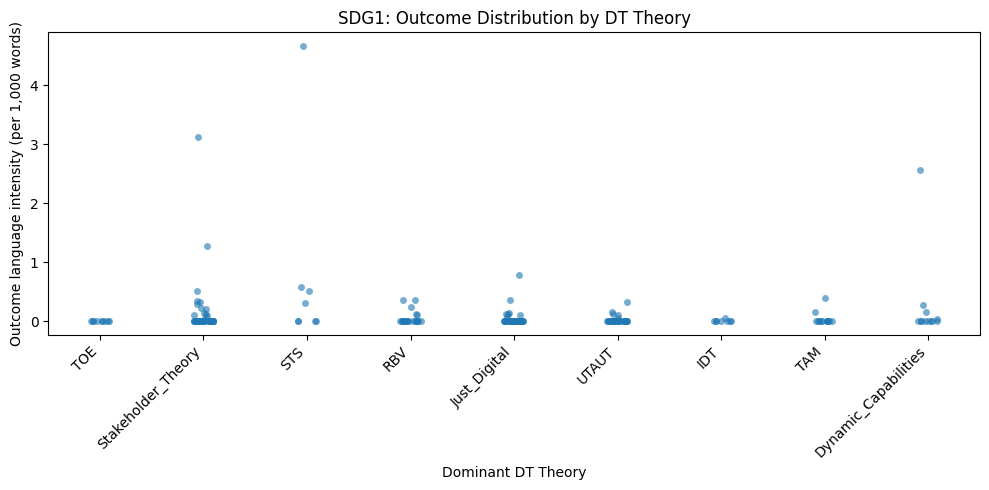

In [ ]:
# Merge ON THE FLY
df = (
    df_dt
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_out, on="paper_id", how="left")
)

# SDG1 only
df_sdg1 = df[df["dominant_sdg"].str.contains("SDG1")]

plt.figure(figsize=(10,5))

sns.stripplot(
    data=df_sdg1,
    x="dominant_dt_theory",
    y="outcome_per_1000w",
    jitter=True,
    alpha=0.6
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Dominant DT Theory")
plt.ylabel("Outcome language intensity (per 1,000 words)")
plt.title("SDG1: Outcome Distribution by DT Theory")

plt.tight_layout()
plt.show()

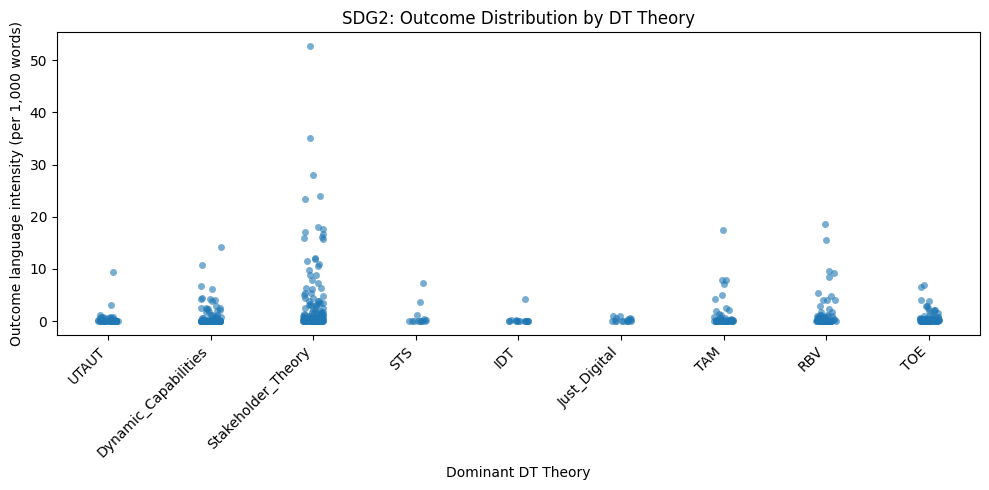

In [ ]:
# SDG2 only
df_sdg2 = df[df["dominant_sdg"].str.contains("SDG2")]

plt.figure(figsize=(10,5))

sns.stripplot(
    data=df_sdg2,
    x="dominant_dt_theory",
    y="outcome_per_1000w",
    jitter=True,
    alpha=0.6
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Dominant DT Theory")
plt.ylabel("Outcome language intensity (per 1,000 words)")
plt.title("SDG2: Outcome Distribution by DT Theory")

plt.tight_layout()
plt.show()

In [ ]:


# Base path (change only if needed)
base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"
fig_path = os.path.join(base, "figures")
os.makedirs(fig_path, exist_ok=True)

df_dt = pd.read_csv(
    base + "dt_theory_similarity_matrix.csv",
    usecols=["paper_id", "dominant_dt_theory"]
)

df_sdg = pd.read_csv(
    base + "SDG_dominance_table.csv",
    usecols=["paper_id", "dominant_sdg", "sdg_margin"]
)

df_out = pd.read_csv(
    base + "df_lang.csv",
    usecols=["paper_id", "outcome_per_1000w"]
)

# Normalize paper_id everywhere
for _df in [df_dt, df_sdg, df_out]:
    _df["paper_id"] = (
        _df["paper_id"]
        .astype(str)
        .str.strip()
        .str.replace(".docx", "", regex=False)
        .str.upper()
    )

# Merge ON THE FLY (no saving)
df = (
    df_dt
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_out, on="paper_id", how="left")
)
df_sdg1 = df[df["dominant_sdg"].str.contains("SDG1")]

plt.figure(figsize=(10,5))
sns.stripplot(
    data=df_sdg1,
    x="dominant_dt_theory",
    y="outcome_per_1000w",
    jitter=True,
    alpha=0.6
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Dominant DT Theory")
plt.ylabel("Outcome language intensity (per 1,000 words)")
plt.title("SDG1: Outcome Distribution by DT Theory")

plt.tight_layout()

plt.savefig(os.path.join(fig_path, "Figure_R3_SDG1_Strip.png"), dpi=300)
plt.savefig(os.path.join(fig_path, "Figure_R3_SDG1_Strip.pdf"))

plt.close()

In [ ]:


base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"
fig_path = os.path.join(base, "figures")
os.makedirs(fig_path, exist_ok=True)

df_dt = pd.read_csv(
    base + "dt_theory_similarity_matrix.csv",
    usecols=["paper_id", "dominant_dt_theory"]
)

df_sdg = pd.read_csv(
    base + "SDG_dominance_table.csv",
    usecols=["paper_id", "dominant_sdg"]
)

df_out = pd.read_csv(
    base + "df_lang.csv",
    usecols=["paper_id", "outcome_per_1000w"]
)

# Normalize paper_id everywhere
for _df in [df_dt, df_sdg, df_out]:
    _df["paper_id"] = (
        _df["paper_id"]
        .astype(str)
        .str.strip()
        .str.replace(".docx", "", regex=False)
        .str.upper()
    )

# Merge ON THE FLY
df = (
    df_dt
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_out, on="paper_id", how="left")
)
df_sdg1 = df[df["dominant_sdg"].str.contains("SDG1")]

plt.figure(figsize=(9,6))

joypy.joyplot(
    data=df_sdg1,
    by="dominant_dt_theory",
    column="outcome_per_1000w",
    overlap=0.6,
    linewidth=1,
    colormap=plt.cm.Blues,
    fade=True
)

plt.xlabel("Outcome language intensity (per 1,000 words)")
plt.title("SDG1: Outcome Language Distribution by DT Theory")

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "Figure_R5_SDG1_Ridgeline.png"), dpi=300)
plt.savefig(os.path.join(fig_path, "Figure_R5_SDG1_Ridgeline.pdf"))
plt.close()
df_sdg2 = df[df["dominant_sdg"].str.contains("SDG2")]

plt.figure(figsize=(9,6))

joypy.joyplot(
    data=df_sdg2,
    by="dominant_dt_theory",
    column="outcome_per_1000w",
    overlap=0.6,
    linewidth=1,
    colormap=plt.cm.Greens,
    fade=True
)

plt.xlabel("Outcome language intensity (per 1,000 words)")
plt.title("SDG2: Outcome Language Distribution by DT Theory")

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "Figure_R6_SDG2_Ridgeline.png"), dpi=300)
plt.savefig(os.path.join(fig_path, "Figure_R6_SDG2_Ridgeline.pdf"))
plt.close()

<Figure size 900x600 with 0 Axes>

<Figure size 900x600 with 0 Axes>

In [ ]:
df_dt = pd.read_csv(
    base + "dt_theory_similarity_matrix.csv",
    usecols=["paper_id", "dominant_dt_theory"]
)

df_sdg = pd.read_csv(
    base + "SDG_dominance_table.csv",
    usecols=["paper_id", "dominant_sdg"]
)

df_out = pd.read_csv(
    base + "df_lang.csv",
    usecols=["paper_id", "outcome_per_1000w"]
)

# Normalize paper_id everywhere
for _df in [df_dt, df_sdg, df_out]:
    _df["paper_id"] = (
        _df["paper_id"]
        .astype(str)
        .str.strip()
        .str.replace(".docx", "", regex=False)
        .str.upper()
    )

# Merge ON THE FLY (no saving)
df = (
    df_dt
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_out, on="paper_id", how="left")
)
df_sdg1 = df[df["dominant_sdg"].str.contains("SDG1")]

plt.figure(figsize=(10,5))

sns.swarmplot(
    data=df_sdg1,
    x="dominant_dt_theory",
    y="outcome_per_1000w",
    size=3
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Dominant DT Theory")
plt.ylabel("Outcome language intensity (per 1,000 words)")
plt.title("SDG1: Outcome Distribution by DT Theory (Beeswarm)")

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "Figure_R7_SDG1_Beeswarm.png"), dpi=300)
plt.savefig(os.path.join(fig_path, "Figure_R7_SDG1_Beeswarm.pdf"))
plt.close()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 31.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 31.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 29.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 27.8% of the points cannot be plac

In [ ]:


base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"
fig_path = os.path.join(base, "figures")
os.makedirs(fig_path, exist_ok=True)

# Load real inputs
df_dt = pd.read_csv(
    base + "dt_theory_similarity_matrix.csv",
    usecols=["paper_id", "dominant_dt_theory"]
)

df_sdg = pd.read_csv(
    base + "SDG_dominance_table.csv",
    usecols=["paper_id", "dominant_sdg", "sdg_margin"]
)

df_out = pd.read_csv(
    base + "df_lang.csv",
    usecols=["paper_id", "outcome_per_1000w"]
)

# Normalize paper_id everywhere
for _df in [df_dt, df_sdg, df_out]:
    _df["paper_id"] = (
        _df["paper_id"]
        .astype(str)
        .str.strip()
        .str.replace(".docx", "", regex=False)
        .str.upper()
    )

# Merge ON THE FLY
df = (
    df_dt
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_out, on="paper_id", how="left")
)

In [ ]:
plt.figure(figsize=(10,5))

# ---- YOUR PLOT CODE HERE ----
# sns.stripplot(...)
# plt.scatter(...)
# joypy.joyplot(...)
# ----------------------------

plt.tight_layout()

# Save (PNG + PDF)
plt.savefig(fig_path + "/FIGURE_NAME.png", dpi=300, bbox_inches="tight")
plt.savefig(fig_path + "/FIGURE_NAME.pdf", bbox_inches="tight")

# Show on screen
plt.show()

# Close figure (important)
plt.close()

<Figure size 1000x500 with 0 Axes>

In [ ]:


base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"
fig_path = os.path.join(base, "figures")
os.makedirs(fig_path, exist_ok=True)

# Load real inputs
df_dt = pd.read_csv(
    base + "dt_theory_similarity_matrix.csv",
    usecols=["paper_id", "dominant_dt_theory"]
)

df_sdg = pd.read_csv(
    base + "SDG_dominance_table.csv",
    usecols=["paper_id", "dominant_sdg", "sdg_margin"]
)

df_out = pd.read_csv(
    base + "df_lang.csv",
    usecols=["paper_id", "outcome_per_1000w"]
)

# Normalize paper_id everywhere
for _df in [df_dt, df_sdg, df_out]:
    _df["paper_id"] = (
        _df["paper_id"]
        .astype(str)
        .str.strip()
        .str.replace(".docx", "", regex=False)
        .str.upper()
    )

# Merge ON THE FLY
df = (
    df_dt
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_out, on="paper_id", how="left")
)

In [ ]:
# Focus on SDG2
df_sdg2 = df[df["dominant_sdg"].str.contains("SDG2")]

# Aggregate per DT theory
agg = (
    df_sdg2
    .groupby("dominant_dt_theory")
    .agg(
        mean_abs_margin=("sdg_margin", lambda x: np.mean(np.abs(x))),
        mean_outcome=("outcome_per_1000w", "mean"),
        count=("paper_id", "count")
    )
    .reset_index()
)

# Color by SDG (here all SDG2, but keep logic explicit)
colors = ["#33a02c"] * len(agg)  # SDG2 green

# Scale sizes for glyphs
sizes = agg["count"] * 15

plt.figure(figsize=(9,6))

plt.scatter(
    agg["mean_abs_margin"],
    agg["mean_outcome"],
    s=sizes,
    c=colors,
    alpha=0.7,
    edgecolor="black"
)

# Label each glyph
for _, r in agg.iterrows():
    plt.text(
        r["mean_abs_margin"]*1.01,
        r["mean_outcome"],
        r["dominant_dt_theory"],
        fontsize=9
    )

plt.xlabel("Mean absolute SDG dominance margin (SDG2 papers)")
plt.ylabel("Mean outcome language intensity (per 1,000 words)")
plt.title("Glyph-based Representation of DT Theories in SDG2")

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "Figure_R9_Glyph_SDG2.png"), dpi=300)
plt.savefig(os.path.join(fig_path, "Figure_R9_Glyph_SDG2.pdf"))
plt.close()

In [ ]:


base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"
fig_path = os.path.join(base, "figures")
os.makedirs(fig_path, exist_ok=True)

In [ ]:
df_dt = pd.read_csv(
    base + "dt_theory_similarity_matrix.csv",
    usecols=["paper_id", "dominant_dt_theory"]
)

df_sdg = pd.read_csv(
    base + "SDG_dominance_table.csv",
    usecols=["paper_id", "dominant_sdg", "sdg_margin"]
)

df_out = pd.read_csv(
    base + "df_lang.csv",
    usecols=["paper_id", "outcome_per_1000w"]
)

# نرمال‌سازی paper_id
for _df in [df_dt, df_sdg, df_out]:
    _df["paper_id"] = (
        _df["paper_id"]
        .astype(str)
        .str.strip()
        .str.replace(".docx", "", regex=False)
        .str.upper()
    )

# merge موقت (هیچ چیزی ذخیره نمی‌کنیم)
df = (
    df_dt
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_out, on="paper_id", how="left")
)

In [ ]:
agg = (
    df
    .groupby("dominant_dt_theory")
    .agg(
        x_mean_abs_margin=("sdg_margin", lambda x: np.mean(np.abs(x))),
        y_mean_outcome=("outcome_per_1000w", "mean"),
        z_count=("paper_id", "count"),
        sdg_stage=("dominant_sdg", lambda x: x.value_counts().idxmax())
    )
    .reset_index()
)

# رنگ بر اساس SDG stage غالب
agg["color"] = agg["sdg_stage"].map({
    "SDG1_No_Poverty": "blue",
    "SDG2_Zero_Hunger": "green"
})

In [ ]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=agg["x_mean_abs_margin"],
            y=agg["y_mean_outcome"],
            z=agg["z_count"],
            mode="markers+text",
            marker=dict(
                size=agg["z_count"] / agg["z_count"].max() * 20 + 5,
                color=agg["color"],
                opacity=0.85
            ),
            text=agg["dominant_dt_theory"],
            textposition="top center"
        )
    ]
)

fig.update_layout(
    title="3D Glyph-based Map of DT Theories (Framing × Outcome × Dominance)",
    scene=dict(
        xaxis_title="Mean |SDG dominance margin|",
        yaxis_title="Mean outcome intensity (per 1,000 words)",
        zaxis_title="Number of papers (DT dominance)"
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

# ذخیره + نمایش
fig.write_html(os.path.join(fig_path, "Figure_Glyph_3D_DT.html"))
fig.show()

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [ ]:

base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"
fig_path = os.path.join(base, "figures")
os.makedirs(fig_path, exist_ok=True)

In [ ]:
df_dt = pd.read_csv(
    base + "dt_theory_similarity_matrix.csv",
    usecols=["paper_id", "dominant_dt_theory"]
)

df_sdg = pd.read_csv(
    base + "SDG_dominance_table.csv",
    usecols=["paper_id", "dominant_sdg", "sdg_margin"]
)

df_out = pd.read_csv(
    base + "df_lang.csv",
    usecols=["paper_id", "outcome_per_1000w"]
)

# نرمال‌سازی paper_id
for _df in [df_dt, df_sdg, df_out]:
    _df["paper_id"] = (
        _df["paper_id"]
        .astype(str)
        .str.strip()
        .str.replace(".docx", "", regex=False)
        .str.upper()
    )

# merge موقت
df = (
    df_dt
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_out, on="paper_id", how="left")
)

In [ ]:
df_sdg1 = df[df["dominant_sdg"].str.contains("SDG1")]

agg1 = (
    df_sdg1
    .groupby("dominant_dt_theory")
    .agg(
        x_mean_abs_margin=("sdg_margin", lambda x: np.mean(np.abs(x))),
        y_mean_outcome=("outcome_per_1000w", "mean"),
        z_count=("paper_id", "count")
    )
    .reset_index()
)

fig1 = go.Figure(
    data=[
        go.Scatter3d(
            x=agg1["x_mean_abs_margin"],
            y=agg1["y_mean_outcome"],
            z=agg1["z_count"],
            mode="markers+text",
            marker=dict(
                size=agg1["z_count"] / agg1["z_count"].max() * 20 + 6,
                color="#1f78b4",  # SDG1 blue
                opacity=0.85
            ),
            text=agg1["dominant_dt_theory"],
            textposition="top center"
        )
    ]
)

fig1.update_layout(
    title="3D Glyph Map — SDG1 (No Poverty)",
    scene=dict(
        xaxis_title="Mean |SDG dominance margin|",
        yaxis_title="Mean outcome intensity (per 1,000 words)",
        zaxis_title="Number of papers (DT dominance)"
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig1.write_html(os.path.join(fig_path, "Figure_Glyph_3D_SDG1.html"))
fig1.show()

In [ ]:
df_sdg2 = df[df["dominant_sdg"].str.contains("SDG2")]

agg2 = (
    df_sdg2
    .groupby("dominant_dt_theory")
    .agg(
        x_mean_abs_margin=("sdg_margin", lambda x: np.mean(np.abs(x))),
        y_mean_outcome=("outcome_per_1000w", "mean"),
        z_count=("paper_id", "count")
    )
    .reset_index()
)

fig2 = go.Figure(
    data=[
        go.Scatter3d(
            x=agg2["x_mean_abs_margin"],
            y=agg2["y_mean_outcome"],
            z=agg2["z_count"],
            mode="markers+text",
            marker=dict(
                size=agg2["z_count"] / agg2["z_count"].max() * 20 + 6,
                color="#33a02c",  # SDG2 green
                opacity=0.85
            ),
            text=agg2["dominant_dt_theory"],
            textposition="top center"
        )
    ]
)

fig2.update_layout(
    title="3D Glyph Map — SDG2 (Zero Hunger)",
    scene=dict(
        xaxis_title="Mean |SDG dominance margin|",
        yaxis_title="Mean outcome intensity (per 1,000 words)",
        zaxis_title="Number of papers (DT dominance)"
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig2.write_html(os.path.join(fig_path, "Figure_Glyph_3D_SDG2.html"))
fig2.show()

In [ ]:
camera = dict(
    eye=dict(x=1.6, y=1.4, z=0.9)
)

In [ ]:
fig2.update_layout(
    scene_camera=dict(
        eye=dict(x=1.6, y=1.4, z=0.9)
    )
)


fig2.write_image(
    os.path.join(fig_path, "Figure_Glyph_3D_SDG2.png"),
    width=1800,
    height=1400,
    scale=2
)


fig2.write_image(
    os.path.join(fig_path, "Figure_Glyph_3D_SDG2.pdf"),
    width=1800,
    height=1400
)

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [ ]:
fig1.update_layout(
    scene_camera=dict(
        eye=dict(x=1.6, y=1.4, z=0.9)
    )
)

fig1.write_image(
    os.path.join(fig_path, "Figure_Glyph_3D_SDG1.png"),
    width=1800,
    height=1400,
    scale=2
)

fig1.write_image(
    os.path.join(fig_path, "Figure_Glyph_3D_SDG1.pdf"),
    width=1800,
    height=1400
)

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/dt_theory_similarity_matrix.csv"

df = pd.read_csv(path)

# sanity check
print(df.head())
print(df.columns)
print("Total documents:", len(df))

   paper_id       TAM     UTAUT       STS       TOE       RBV  \
0  SDG1-349  0.249565  0.318209  0.440587  0.487894  0.364487   
1  SDG1-350  0.524092  0.529231  0.310501  0.554820  0.326366   
2  SDG1-352  0.300366  0.313673  0.230218  0.260684  0.212325   
3  SDG1-345  0.231426  0.196560  0.138748  0.244972  0.302641   
4  SDG1-346  0.165246  0.243769  0.104790  0.231284  0.289573   

   Dynamic_Capabilities       IDT  Stakeholder_Theory  Just_Digital  \
0              0.453377  0.253460            0.295376      0.203457   
1              0.339425  0.402054            0.249288      0.115868   
2              0.238646  0.284524            0.233778      0.178900   
3              0.308890  0.236663            0.177612      0.142301   
4              0.301904  0.177523            0.324334      0.171927   

     dominant_dt_theory  
0                   TOE  
1                   TOE  
2                 UTAUT  
3  Dynamic_Capabilities  
4    Stakeholder_Theory  
Index(['paper_id', 'TAM', 

In [ ]:
# Build Table 1 from existing df (REAL DATA)

import pandas as pd

table1 = (
    df["dominant_dt_theory"]
    .value_counts()
    .reset_index()
)

table1.columns = ["Dominant DT Theory", "n"]

total_n = table1["n"].sum()
table1["%"] = (table1["n"] / total_n * 100).round(1)

table1 = table1.sort_values("n", ascending=False)

# Add total row (APA style)
total_row = pd.DataFrame({
    "Dominant DT Theory": ["Total"],
    "n": [total_n],
    "%": [100.0]
})

table1 = pd.concat([table1, total_row], ignore_index=True)

table1

,Dominant DT Theory,n,%
0,Stakeholder_Theory,206,27.5
1,Dynamic_Capabilities,120,16.0
2,TOE,95,12.7
3,RBV,87,11.6
4,UTAUT,78,10.4
5,TAM,66,8.8
6,Just_Digital,52,7.0
7,IDT,23,3.1
8,STS,21,2.8
9,Total,748,100.0


In [ ]:
import pandas as pd
import numpy as np

path = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/SDG_dominance_table.csv"

df_sdg = pd.read_csv(path)

# sanity check
print(df_sdg.head())
print(df_sdg.columns)
print("Total documents:", len(df_sdg))

   paper_id  SDG1_No_Poverty  SDG2_Zero_Hunger      dominant_sdg  sdg_margin
0  SDG1-349         0.130959          0.110562   SDG1_No_Poverty    0.020397
1  SDG1-350         0.100637          0.100015   SDG1_No_Poverty    0.000622
2  SDG1-352         0.074855          0.333108  SDG2_Zero_Hunger   -0.258252
3  SDG1-345         0.178426          0.411657  SDG2_Zero_Hunger   -0.233231
4  SDG1-346         0.345245          0.349728  SDG2_Zero_Hunger   -0.004482
Index(['paper_id', 'SDG1_No_Poverty', 'SDG2_Zero_Hunger', 'dominant_sdg',
       'sdg_margin'],
      dtype='object')
Total documents: 748


In [ ]:
# Count SDG1 vs SDG2
counts = (
    df_sdg["dominant_sdg"]
    .value_counts()
    .reset_index()
)

counts.columns = ["Dominant SDG", "n"]

total_n = counts["n"].sum()
counts["%"] = (counts["n"] / total_n * 100).round(1)

# SDG dominance margin statistics
margin_stats = (
    df_sdg
    .groupby("dominant_sdg")["sdg_margin"]
    .agg(
        mean_margin="mean",
        median_margin="median",
        mean_abs_margin=lambda x: np.mean(np.abs(x))
    )
    .reset_index()
)

# Merge counts + margins
table_r2 = counts.merge(margin_stats, left_on="Dominant SDG", right_on="dominant_sdg")

table_r2 = table_r2[[
    "Dominant SDG",
    "n",
    "%",
    "mean_margin",
    "median_margin",
    "mean_abs_margin"
]]

# Add Total row (APA style)
total_row = pd.DataFrame({
    "Dominant SDG": ["Total"],
    "n": [total_n],
    "%": [100.0],
    "mean_margin": [np.nan],
    "median_margin": [np.nan],
    "mean_abs_margin": [np.nan]
})

table_r2 = pd.concat([table_r2, total_row], ignore_index=True)

table_r2

,Dominant SDG,n,%,mean_margin,median_margin,mean_abs_margin
0,SDG2_Zero_Hunger,565,75.5,-0.147167,-0.157112,0.147167
1,SDG1_No_Poverty,183,24.5,0.053108,0.044282,0.053108
2,Total,748,100.0,NaN,NaN,NaN


In [ ]:
base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"

df_dt = pd.read_csv(
    base + "dt_theory_similarity_matrix.csv",
    usecols=["paper_id", "dominant_dt_theory"]
)

df_sdg = pd.read_csv(
    base + "SDG_dominance_table.csv",
    usecols=["paper_id", "dominant_sdg", "sdg_margin"]
)

df_out = pd.read_csv(
    base + "df_lang.csv",
    usecols=["paper_id", "outcome_per_1000w"]
)

# نرمال‌سازی شناسه‌ها
for _df in [df_dt, df_sdg, df_out]:
    _df["paper_id"] = (
        _df["paper_id"].astype(str)
        .str.strip()
        .str.replace(".docx", "", regex=False)
        .str.upper()
    )

# Merge موقت
df = (
    df_dt
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_out, on="paper_id", how="left")
)

In [ ]:
df_sdg1 = df[df["dominant_sdg"] == "SDG1_No_Poverty"]

In [ ]:
agg1 = (
    df_sdg1
    .groupby("dominant_dt_theory")
    .agg(
        mean_abs_margin=("sdg_margin", lambda x: np.mean(np.abs(x))),
        mean_outcome=("outcome_per_1000w", "mean"),
        count=("paper_id", "count")
    )
    .reset_index()
)

In [ ]:
x_med = agg1["mean_abs_margin"].median()
y_med = agg1["mean_outcome"].median()

def quadrant(row):
    if row["mean_abs_margin"] >= x_med and row["mean_outcome"] >= y_med:
        return "Amplifier"
    elif row["mean_abs_margin"] < x_med and row["mean_outcome"] >= y_med:
        return "Underused High-Impact"
    elif row["mean_abs_margin"] < x_med and row["mean_outcome"] < y_med:
        return "Marginal"
    else:
        return "Gatekeeper"

agg1["quadrant"] = agg1.apply(quadrant, axis=1)

In [ ]:
palette = {
    "Amplifier": "#2ca02c",              # سبز
    "Marginal": "#ff7f0e",               # نارنجی
    "Underused High-Impact": "#1f77b4",  # آبی
    "Gatekeeper": "#e377c2"              # صورتی
}

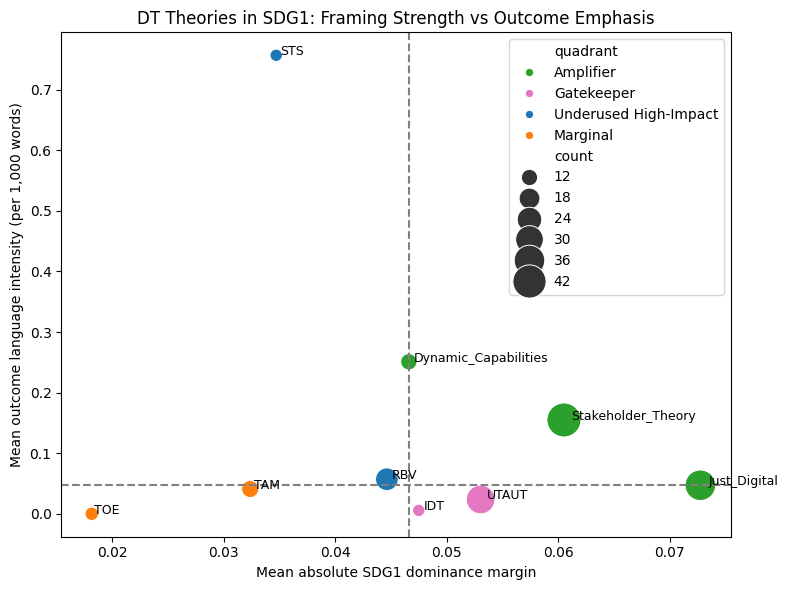

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=agg1,
    x="mean_abs_margin",
    y="mean_outcome",
    hue="quadrant",
    size="count",
    sizes=(80, 600),
    palette=palette,
    legend=True
)

# خطوط میانه (data-driven)
plt.axvline(x_med, linestyle="--", color="gray")
plt.axhline(y_med, linestyle="--", color="gray")

# برچسب نظریه‌ها
for _, r in agg1.iterrows():
    plt.text(
        r["mean_abs_margin"]*1.01,
        r["mean_outcome"],
        r["dominant_dt_theory"],
        fontsize=9
    )

plt.xlabel("Mean absolute SDG1 dominance margin")
plt.ylabel("Mean outcome language intensity (per 1,000 words)")
plt.title("DT Theories in SDG1: Framing Strength vs Outcome Emphasis")

plt.tight_layout()
plt.show()

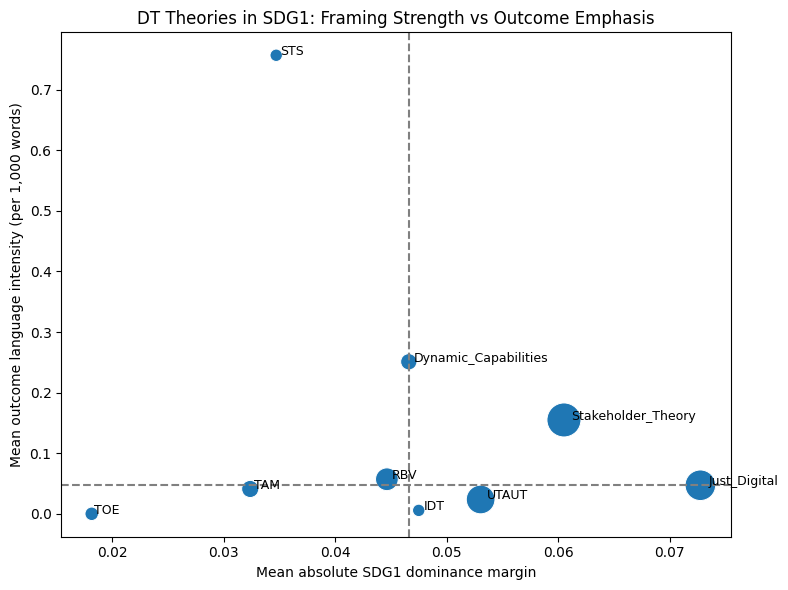

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=agg1,
    x="mean_abs_margin",
    y="mean_outcome",
    size="count",
    sizes=(80, 600),
    legend=False
)

# Quadrant lines
plt.axvline(x_med, linestyle="--", color="gray")
plt.axhline(y_med, linestyle="--", color="gray")

# Labels
for _, r in agg1.iterrows():
    plt.text(
        r["mean_abs_margin"]*1.01,
        r["mean_outcome"],
        r["dominant_dt_theory"],
        fontsize=9
    )

plt.xlabel("Mean absolute SDG1 dominance margin")
plt.ylabel("Mean outcome language intensity (per 1,000 words)")
plt.title("DT Theories in SDG1: Framing Strength vs Outcome Emphasis")

plt.tight_layout()
plt.show()

In [ ]:
palette = {
    "Amplifier": "#2ca02c",              # سبز
    "Gatekeeper": "#e377c2",             # صورتی
    "Underused High-Impact": "#1f77b4",  # آبی
    "Marginal": "#ff7f0e"                # نارنجی
}

In [ ]:
base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"

# DT theory assignment
df_dt = pd.read_csv(
    base + "dt_theory_similarity_matrix.csv",
    usecols=["paper_id", "dominant_dt_theory"]
)

# SDG dominance
df_sdg = pd.read_csv(
    base + "SDG_dominance_table.csv",
    usecols=["paper_id", "dominant_sdg", "sdg_margin"]
)

# Outcome language
df_out = pd.read_csv(
    base + "df_lang.csv",
    usecols=["paper_id", "outcome_per_1000w"]
)

In [ ]:
for _df in [df_dt, df_sdg, df_out]:
    _df["paper_id"] = (
        _df["paper_id"]
        .astype(str)
        .str.strip()
        .str.replace(".docx", "", regex=False)
        .str.upper()
    )

In [ ]:
df = (
    df_dt
    .merge(df_sdg, on="paper_id", how="inner")
    .merge(df_out, on="paper_id", how="left")
)

print("Merged rows:", len(df))
df.head()

Merged rows: 748


,paper_id,dominant_dt_theory,dominant_sdg,sdg_margin,outcome_per_1000w
0,SDG1-349,TOE,SDG1_No_Poverty,0.020397,0.000000
1,SDG1-350,TOE,SDG1_No_Poverty,0.000622,0.000000
2,SDG1-352,UTAUT,SDG2_Zero_Hunger,-0.258252,0.000000
3,SDG1-345,Dynamic_Capabilities,SDG2_Zero_Hunger,-0.233231,0.000000
4,SDG1-346,Stakeholder_Theory,SDG2_Zero_Hunger,-0.004482,0.146531


In [ ]:
df_sdg2 = df[df["dominant_sdg"] == "SDG2_Zero_Hunger"]

print("SDG2 docs:", len(df_sdg2))

SDG2 docs: 565


In [ ]:
agg2 = (
    df_sdg2
    .groupby("dominant_dt_theory")
    .agg(
        mean_abs_margin=("sdg_margin", lambda x: np.mean(np.abs(x))),
        mean_outcome=("outcome_per_1000w", "mean"),
        count=("paper_id", "count")
    )
    .reset_index()
)

agg2

,dominant_dt_theory,mean_abs_margin,mean_outcome,count
0,Dynamic_Capabilities,0.145089,0.862723,108
1,IDT,0.136711,0.336267,15
2,Just_Digital,0.067965,0.256994,16
3,RBV,0.142377,1.606983,66
4,STS,0.113036,0.981927,13
5,Stakeholder_Theory,0.162464,3.182700,162
6,TAM,0.152251,1.194824,53
7,TOE,0.160384,0.633541,86
8,UTAUT,0.115083,0.449825,46


In [ ]:
x_med = agg2["mean_abs_margin"].median()
y_med = agg2["mean_outcome"].median()

def quadrant(row):
    if row["mean_abs_margin"] >= x_med and row["mean_outcome"] >= y_med:
        return "Amplifier"
    elif row["mean_abs_margin"] < x_med and row["mean_outcome"] >= y_med:
        return "Underused High-Impact"
    elif row["mean_abs_margin"] < x_med and row["mean_outcome"] < y_med:
        return "Marginal"
    else:
        return "Gatekeeper"

agg2["quadrant"] = agg2.apply(quadrant, axis=1)

agg2

,dominant_dt_theory,mean_abs_margin,mean_outcome,count,quadrant
0,Dynamic_Capabilities,0.145089,0.862723,108,Amplifier
1,IDT,0.136711,0.336267,15,Marginal
2,Just_Digital,0.067965,0.256994,16,Marginal
3,RBV,0.142377,1.606983,66,Amplifier
4,STS,0.113036,0.981927,13,Underused High-Impact
5,Stakeholder_Theory,0.162464,3.182700,162,Amplifier
6,TAM,0.152251,1.194824,53,Amplifier
7,TOE,0.160384,0.633541,86,Gatekeeper
8,UTAUT,0.115083,0.449825,46,Marginal


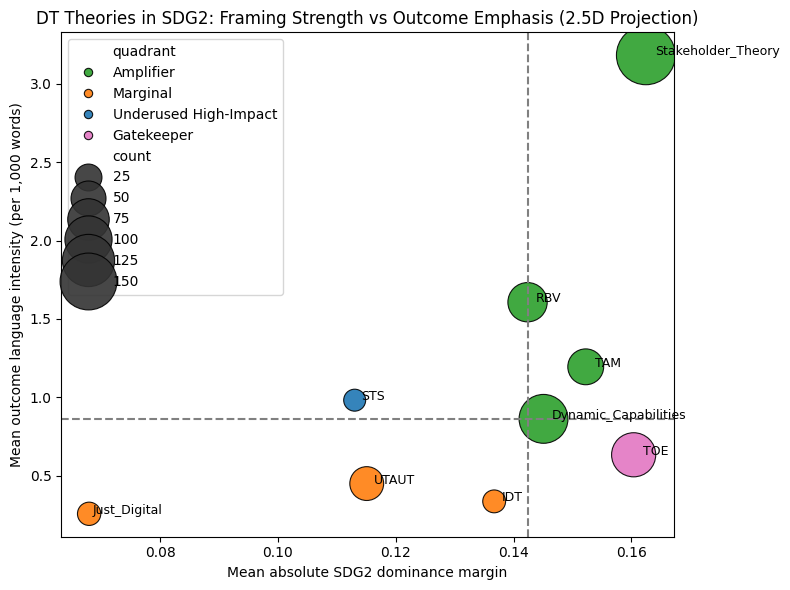

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = {
    "Amplifier": "#2ca02c",              # سبز
    "Gatekeeper": "#e377c2",             # صورتی
    "Underused High-Impact": "#1f77b4",  # آبی
    "Marginal": "#ff7f0e"                # نارنجی
}

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=agg2,
    x="mean_abs_margin",
    y="mean_outcome",
    size="count",
    sizes=(250, 1800),
    hue="quadrant",
    palette=palette,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9
)

plt.axvline(x_med, linestyle="--", color="gray")
plt.axhline(y_med, linestyle="--", color="gray")

for _, r in agg2.iterrows():
    plt.text(
        r["mean_abs_margin"] * 1.01,
        r["mean_outcome"],
        r["dominant_dt_theory"],
        fontsize=9
    )

plt.xlabel("Mean absolute SDG2 dominance margin")
plt.ylabel("Mean outcome language intensity (per 1,000 words)")
plt.title("DT Theories in SDG2: Framing Strength vs Outcome Emphasis (2.5D Projection)")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import networkx as nx
import numpy as np

base = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"

df_dt = pd.read_csv(base+"dt_theory_similarity_matrix.csv",
                    usecols=["paper_id","dominant_dt_theory"])
df_sdg = pd.read_csv(base+"SDG_dominance_table.csv",
                     usecols=["paper_id","dominant_sdg"])
df_out = pd.read_csv(base+"df_lang.csv",
                     usecols=["paper_id","outcome_per_1000w"])

for d in (df_dt, df_sdg, df_out):
    d["paper_id"] = d["paper_id"].str.replace(".docx","",regex=False).str.upper()

df = df_dt.merge(df_sdg,"inner").merge(df_out,"left")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# SDG2 only
df_sdg2 = df[df["dominant_sdg"]=="SDG2_Zero_Hunger"]

# outcome threshold (explicit)
thr = df_sdg2["outcome_per_1000w"].median()

df_high = df_sdg2[df_sdg2["outcome_per_1000w"] > thr]

G_outcome = nx.Graph()

for pid, g in df_high.groupby("paper_id"):
    theories = g["dominant_dt_theory"].unique()
    for i in range(len(theories)):
        for j in range(i+1,len(theories)):
            a,b = theories[i], theories[j]
            if G_outcome.has_edge(a,b):
                G_outcome[a][b]["weight"] += 1
            else:
                G_outcome.add_edge(a,b,weight=1)

In [ ]:
df_zero = df_sdg2[df_sdg2["outcome_per_1000w"] == 0]

G_fail = nx.Graph()

for pid, g in df_zero.groupby("paper_id"):
    theories = g["dominant_dt_theory"].unique()
    for i in range(len(theories)):
        for j in range(i+1,len(theories)):
            a,b = theories[i], theories[j]
            if G_fail.has_edge(a,b):
                G_fail[a][b]["weight"] += 1
            else:
                G_fail.add_edge(a,b,weight=1)

NameError: name 'df_sdg2' is not defined

In [ ]:
# Install required package for reading DOCX files
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 21.3 MB/s eta 0:00:00


In [ ]:
# =========================================================
# Dictionary-Based Dual Concern Classification (FULL TEXT)
# Stakeholder Theory Papers
# =========================================================

import os
import re
import pandas as pd
import numpy as np
from docx import Document

# -----------------------------
# 0) PATHS (EDIT IF NEEDED)
# -----------------------------
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/"
TEXT_PATH = BASE_PATH + "files/"          # folder with DOCX files
META_PATH = BASE_PATH + "results/"

PATH_DT = META_PATH + "dt_theory_similarity_matrix.csv"

# -----------------------------
# 1) LOAD METADATA (Stakeholder only)
# -----------------------------
df_dt = pd.read_csv(PATH_DT, usecols=["paper_id", "dominant_dt_theory"])
df_dt["paper_id"] = df_dt["paper_id"].str.replace(".docx","",regex=False).str.upper()

df_st = df_dt[df_dt["dominant_dt_theory"]=="Stakeholder_Theory"].copy()
assert len(df_st)>0, "No Stakeholder Theory papers found."

# -----------------------------
# 2) Dual Concern Dictionaries
# -----------------------------
assertive_terms = [
    "governance","regulation","compliance","control","oversight",
    "institutional framework","regulatory framework",
    "coordination","decision-making","top-down","mandate"
]

cooperative_terms = [
    "lived experience","quality of life","human wellbeing",
    "poverty reduction","poverty alleviation",
    "food access","food security","nutrition","hunger",
    "vulnerable populations","marginalized communities",
    "basic needs","livelihoods"
]

# -----------------------------
# 3) Helper functions
# -----------------------------
def read_docx(path):
    try:
        doc = Document(path)
        return " ".join(p.text for p in doc.paragraphs).lower()
    except:
        return ""

def count_terms(text, terms):
    return sum(len(re.findall(r"\b"+re.escape(t)+r"\b", text)) for t in terms)

# -----------------------------
# 4) Read texts + count terms
# -----------------------------
rows = []

for pid in df_st["paper_id"]:
    fpath = TEXT_PATH + pid + ".docx"
    text = read_docx(fpath)
    wc = max(len(text.split()),1)

    a_cnt = count_terms(text, assertive_terms) / wc * 1000
    c_cnt = count_terms(text, cooperative_terms) / wc * 1000

    rows.append([pid, a_cnt, c_cnt])

df_dc = pd.DataFrame(
    rows,
    columns=["paper_id","assertive_per_1000w","cooperative_per_1000w"]
)

# -----------------------------
# 5) Data-driven thresholds
# -----------------------------
a_thr = df_dc["assertive_per_1000w"].median()
c_thr = df_dc["cooperative_per_1000w"].median()

# -----------------------------
# 6) Dual Concern classification
# -----------------------------
def classify(row):
    hi_a = row["assertive_per_1000w"] >= a_thr
    hi_c = row["cooperative_per_1000w"] >= c_thr

    if hi_a and hi_c:
        return "Integration"
    elif hi_a and not hi_c:
        return "Forcing"
    elif not hi_a and hi_c:
        return "Yielding"
    else:
        return "Compromise"

df_dc["dual_concern_mode"] = df_dc.apply(classify, axis=1)

# -----------------------------
# 7) Final summary table
# -----------------------------
summary = (
    df_dc["dual_concern_mode"]
    .value_counts()
    .rename_axis("Dual Concern Mode")
    .reset_index(name="Count")
)

summary["Percent"] = (summary["Count"]/summary["Count"].sum()*100).round(1)

print("Stakeholder papers:", len(df_dc))
print("Assertive threshold:", round(a_thr,3))
print("Cooperative threshold:", round(c_thr,3))
print("\nDual Concern distribution:\n")

summary

Stakeholder papers: 206
Assertive threshold: 1.158
Cooperative threshold: 1.333

Dual Concern distribution:



,Dual Concern Mode,Count,Percent
0,Yielding,52,25.2
1,Forcing,52,25.2
2,Compromise,51,24.8
3,Integration,51,24.8


In [ ]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 14.5 MB/s eta 0:00:00


In [ ]:
# =========================================================
# SAVE DUAL CONCERN TABLE — STAKEHOLDER THEORY
# =========================================================

import pandas as pd

# -----------------------------
# 1) Recreate the final table (from your results)
# -----------------------------
dual_concern_table = pd.DataFrame({
    "Dual Concern Mode": [
        "Yielding",
        "Forcing",
        "Compromise",
        "Integration"
    ],
    "Count": [52, 52, 51, 51],
    "Percent": [25.2, 25.2, 24.8, 24.8]
})

# -----------------------------
# 2) Metadata (for traceability)
# -----------------------------
metadata = {
    "Total Stakeholder Papers": 206,
    "Assertive Threshold (per 1000w)": 1.158,
    "Cooperative Threshold (per 1000w)": 1.333,
    "Threshold Type": "Global median (data-driven)"
}

metadata_df = pd.DataFrame(
    list(metadata.items()),
    columns=["Parameter", "Value"]
)

# -----------------------------
# 3) Paths
# -----------------------------
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"
FILE_BASE = BASE_PATH + "Stakeholder_DualConcern_Overall"

# -----------------------------
# 4) Save CSV files
# -----------------------------
dual_concern_table.to_csv(FILE_BASE + "_summary.csv", index=False)
metadata_df.to_csv(FILE_BASE + "_metadata.csv", index=False)

# -----------------------------
# 5) Save Excel (journal-friendly)
# -----------------------------
with pd.ExcelWriter(FILE_BASE + ".xlsx", engine="xlsxwriter") as writer:
    dual_concern_table.to_excel(
        writer,
        sheet_name="DualConcern_Summary",
        index=False
    )
    metadata_df.to_excel(
        writer,
        sheet_name="Metadata",
        index=False
    )

# -----------------------------
# 6) Confirm
# -----------------------------
print("✅ Dual Concern table saved successfully:")
print(" - CSV summary:", FILE_BASE + "_summary.csv")
print(" - CSV metadata:", FILE_BASE + "_metadata.csv")
print(" - Excel file:", FILE_BASE + ".xlsx")

dual_concern_table

✅ Dual Concern table saved successfully:
 - CSV summary: /content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/Stakeholder_DualConcern_Overall_summary.csv
 - CSV metadata: /content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/Stakeholder_DualConcern_Overall_metadata.csv
 - Excel file: /content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/Stakeholder_DualConcern_Overall.xlsx


,Dual Concern Mode,Count,Percent
0,Yielding,52,25.2
1,Forcing,52,25.2
2,Compromise,51,24.8
3,Integration,51,24.8


In [ ]:
# =========================================================
# Stakeholder Theory × Dual Concern × SDG1 vs SDG2
# FULL DATA-DRIVEN SPLIT
# =========================================================

import pandas as pd
import numpy as np
import re
from docx import Document

# -----------------------------
# 0) PATHS (EDIT IF NEEDED)
# -----------------------------
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/"
TEXT_PATH = BASE_PATH + "files/"
RES_PATH  = BASE_PATH + "results/"

PATH_DT  = RES_PATH + "dt_theory_similarity_matrix.csv"
PATH_SDG = RES_PATH + "SDG_dominance_table.csv"

# -----------------------------
# 1) Load metadata
# -----------------------------
df_dt = pd.read_csv(PATH_DT, usecols=["paper_id", "dominant_dt_theory"])
df_sdg = pd.read_csv(PATH_SDG, usecols=["paper_id", "dominant_sdg"])

for d in (df_dt, df_sdg):
    d["paper_id"] = (
        d["paper_id"].astype(str)
        .str.replace(".docx","",regex=False)
        .str.strip()
        .str.upper()
    )

# Stakeholder only
df_st = df_dt[df_dt["dominant_dt_theory"]=="Stakeholder_Theory"] \
            .merge(df_sdg, on="paper_id", how="inner")

assert len(df_st)>0, "No Stakeholder Theory papers found."

# -----------------------------
# 2) Dual Concern dictionaries
# -----------------------------
assertive_terms = [
    "governance","regulation","compliance","control","oversight",
    "institutional framework","regulatory framework",
    "coordination","decision-making","top-down","mandate"
]

cooperative_terms = [
    "lived experience","quality of life","human wellbeing",
    "poverty reduction","poverty alleviation",
    "food access","food security","nutrition","hunger",
    "vulnerable populations","marginalized communities",
    "basic needs","livelihoods"
]

def read_docx(path):
    try:
        doc = Document(path)
        return " ".join(p.text for p in doc.paragraphs).lower()
    except:
        return ""

def count_terms(text, terms):
    return sum(len(re.findall(r"\b"+re.escape(t)+r"\b", text)) for t in terms)

# -----------------------------
# 3) Read texts + compute scores
# -----------------------------
rows = []
for pid, sdg in zip(df_st["paper_id"], df_st["dominant_sdg"]):
    text = read_docx(TEXT_PATH + pid + ".docx")
    wc = max(len(text.split()),1)

    a = count_terms(text, assertive_terms) / wc * 1000
    c = count_terms(text, cooperative_terms) / wc * 1000

    rows.append([pid, sdg, a, c])

df_dc = pd.DataFrame(
    rows,
    columns=["paper_id","dominant_sdg",
             "assertive_per_1000w","cooperative_per_1000w"]
)

# -----------------------------
# 4) Global thresholds (same as before)
# -----------------------------
a_thr = df_dc["assertive_per_1000w"].median()
c_thr = df_dc["cooperative_per_1000w"].median()

def classify(row):
    hi_a = row["assertive_per_1000w"] >= a_thr
    hi_c = row["cooperative_per_1000w"] >= c_thr
    if hi_a and hi_c:
        return "Integration"
    elif hi_a and not hi_c:
        return "Forcing"
    elif not hi_a and hi_c:
        return "Yielding"
    else:
        return "Compromise"

df_dc["dual_concern_mode"] = df_dc.apply(classify, axis=1)

# -----------------------------
# 5) Split summary by SDG
# -----------------------------
summary_by_sdg = (
    df_dc
    .groupby(["dominant_sdg","dual_concern_mode"])
    .size()
    .reset_index(name="Count")
)

summary_by_sdg["Percent"] = (
    summary_by_sdg["Count"]
    / summary_by_sdg.groupby("dominant_sdg")["Count"].transform("sum")
    * 100
).round(1)

print("Stakeholder Theory papers:", len(df_dc))
print("Assertive threshold:", round(a_thr,3))
print("Cooperative threshold:", round(c_thr,3))
print("\nDual Concern split by SDG:\n")

summary_by_sdg
# =========================================================
# 6) SAVE OUTPUT TABLES (CSV + Excel)
# =========================================================

SAVE_PATH = RES_PATH + "Stakeholder_DualConcern_SDG_Split"

# 6.1 Save full document-level classification (optional but useful)
df_dc.to_csv(SAVE_PATH + "_document_level.csv", index=False)

# 6.2 Save aggregated table (what you mainly need)
summary_by_sdg.to_csv(SAVE_PATH + "_summary.csv", index=False)

# 6.3 Save Excel version (journal-friendly)
with pd.ExcelWriter(SAVE_PATH + ".xlsx", engine="xlsxwriter") as writer:
    summary_by_sdg.to_excel(
        writer,
        sheet_name="DualConcern_by_SDG",
        index=False
    )
    df_dc.to_excel(
        writer,
        sheet_name="Document_Level",
        index=False
    )

print("✅ Dual Concern tables saved:")
print(" - CSV summary:", SAVE_PATH + "_summary.csv")
print(" - CSV document-level:", SAVE_PATH + "_document_level.csv")
print(" - Excel file:", SAVE_PATH + ".xlsx")

Stakeholder Theory papers: 206
Assertive threshold: 1.158
Cooperative threshold: 1.333

Dual Concern split by SDG:

✅ Dual Concern tables saved:
 - CSV summary: /content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/Stakeholder_DualConcern_SDG_Split_summary.csv
 - CSV document-level: /content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/Stakeholder_DualConcern_SDG_Split_document_level.csv
 - Excel file: /content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/Stakeholder_DualConcern_SDG_Split.xlsx


In [ ]:
# Sanity check: see if texts are actually read

sample = df_dc.sample(5, random_state=42)

for _, row in sample.iterrows():
    print("Paper:", row["paper_id"])
    print("Assertive:", row["assertive_per_1000w"])
    print("Cooperative:", row["cooperative_per_1000w"])
    print("-"*40)

Paper: SDG1-031
Assertive: 2.172024326672459
Cooperative: 1.3032145960034753
----------------------------------------
Paper: SDG1-016
Assertive: 1.4622258326563768
Cooperative: 0.16246953696181965
----------------------------------------
Paper: SDG1-325
Assertive: 3.1551596139569416
Cooperative: 2.319970304380104
----------------------------------------
Paper: SDG2-020
Assertive: 0.9021199819576003
Cooperative: 4.285069914298602
----------------------------------------
Paper: SDG1-234
Assertive: 8.82223202470225
Cooperative: 0.44111160123511245
----------------------------------------


In [ ]:
text = read_docx(TEXT_PATH + "SDG1-031.docx")
print(len(text))
print(text[:500])

0



In [ ]:
import os

print("Folder exists:", os.path.exists(TEXT_PATH))
print("Files in folder (first 10):")
print(os.listdir(TEXT_PATH)[:10])

Folder exists: False
Files in folder (first 10):


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/DTOSDG12/papers/'

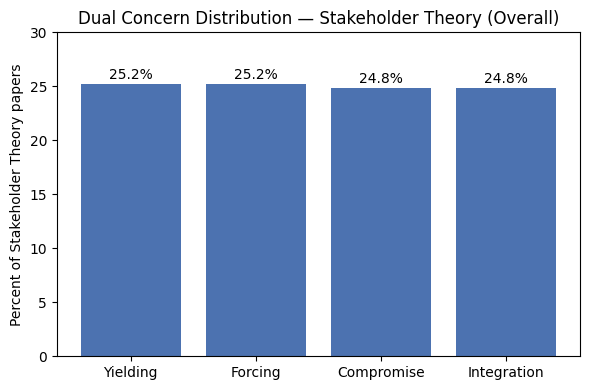

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"
df = pd.read_csv(BASE_PATH + "Stakeholder_DualConcern_Overall_summary.csv")

plt.figure(figsize=(6,4))
plt.bar(df["Dual Concern Mode"], df["Percent"], color="#4C72B0")
plt.ylabel("Percent of Stakeholder Theory papers")
plt.title("Dual Concern Distribution — Stakeholder Theory (Overall)")
plt.ylim(0, 30)

for i, v in enumerate(df["Percent"]):
    plt.text(i, v + 0.5, f"{v}%", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
!pip install seaborn

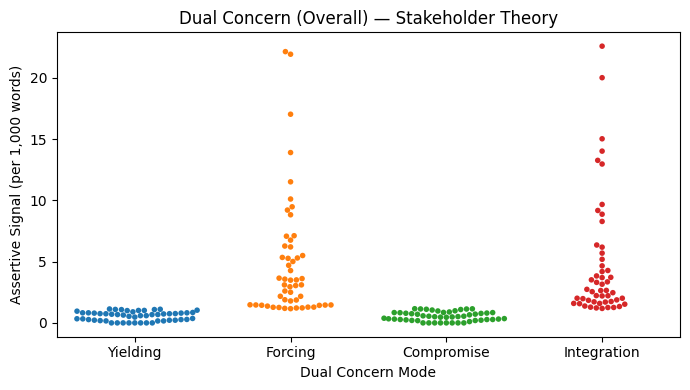

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"

# document-level file (needed for beeswarm)
df = pd.read_csv(BASE_PATH + "Stakeholder_DualConcern_SDG_Split_document_level.csv")

plt.figure(figsize=(7,4))
sns.swarmplot(
    data=df,
    x="dual_concern_mode",
    y="assertive_per_1000w",
    hue="dual_concern_mode",
    dodge=False,
    size=4
)

plt.title("Dual Concern (Overall) — Stakeholder Theory")
plt.xlabel("Dual Concern Mode")
plt.ylabel("Assertive Signal (per 1,000 words)")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()

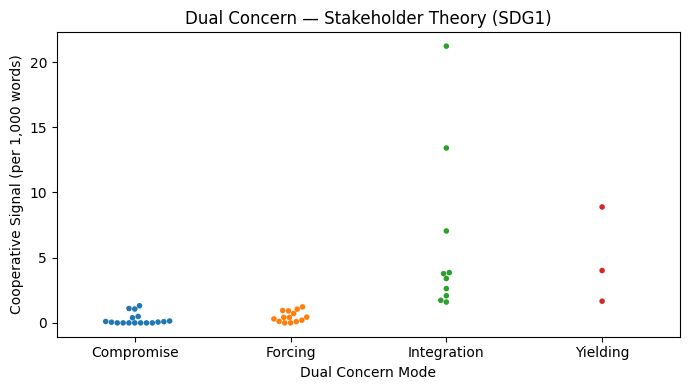

In [ ]:
df1 = df[df["dominant_sdg"] == "SDG1_No_Poverty"]

plt.figure(figsize=(7,4))
sns.swarmplot(
    data=df1,
    x="dual_concern_mode",
    y="cooperative_per_1000w",
    hue="dual_concern_mode",
    dodge=False,
    size=4
)

plt.title("Dual Concern — Stakeholder Theory (SDG1)")
plt.xlabel("Dual Concern Mode")
plt.ylabel("Cooperative Signal (per 1,000 words)")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 18.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


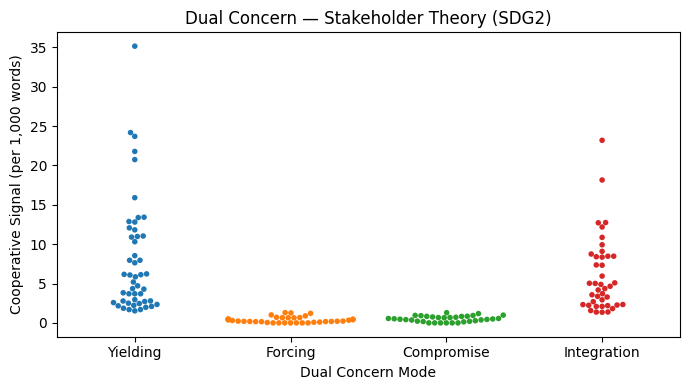

In [ ]:
df2 = df[df["dominant_sdg"] == "SDG2_Zero_Hunger"]

plt.figure(figsize=(7,4))
sns.swarmplot(
    data=df2,
    x="dual_concern_mode",
    y="cooperative_per_1000w",
    hue="dual_concern_mode",
    dodge=False,
    size=4
)

plt.title("Dual Concern — Stakeholder Theory (SDG2)")
plt.xlabel("Dual Concern Mode")
plt.ylabel("Cooperative Signal (per 1,000 words)")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()

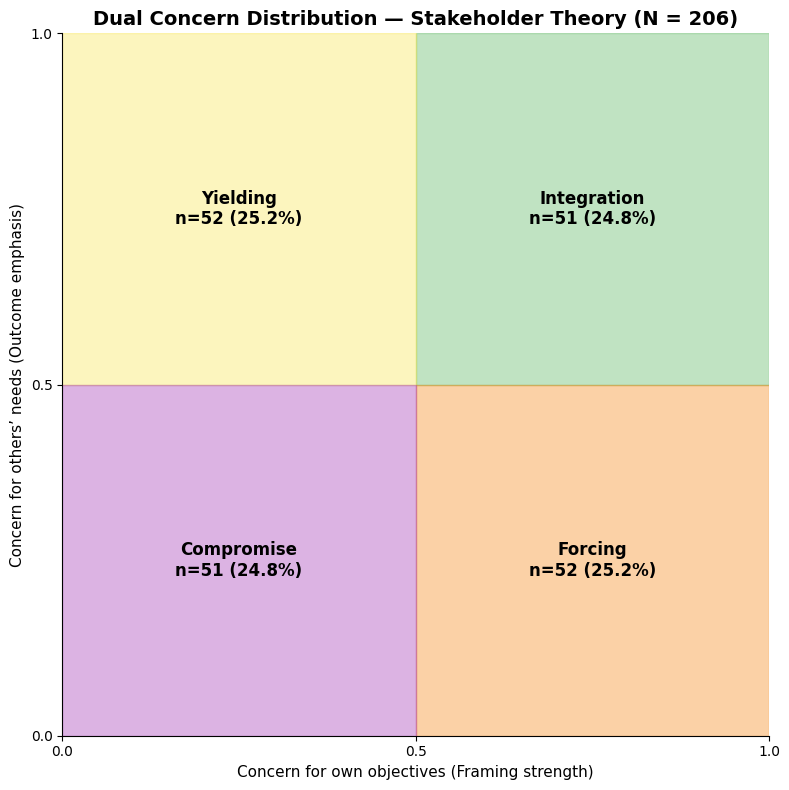

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"
df = pd.read_csv(BASE_PATH + "Stakeholder_DualConcern_Overall_summary.csv")

# Make lookup dict
counts = dict(zip(df["Dual Concern Mode"], df["Count"]))
percents = dict(zip(df["Dual Concern Mode"], df["Percent"]))

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(8,8))

# Draw quadrants
ax.add_patch(plt.Rectangle((0.5,0.5), 0.5, 0.5, color="#4CAF50", alpha=0.35))  # Integration
ax.add_patch(plt.Rectangle((0.0,0.5), 0.5, 0.5, color="#F9E547", alpha=0.35))  # Yielding
ax.add_patch(plt.Rectangle((0.5,0.0), 0.5, 0.5, color="#F57C00", alpha=0.35))  # Forcing
ax.add_patch(plt.Rectangle((0.0,0.0), 0.5, 0.5, color="#9C27B0", alpha=0.35))  # Compromise

# Labels inside quadrants
ax.text(0.75, 0.75,
        f"Integration\nn={counts['Integration']} ({percents['Integration']}%)",
        ha="center", va="center", fontsize=12, weight="bold")

ax.text(0.25, 0.75,
        f"Yielding\nn={counts['Yielding']} ({percents['Yielding']}%)",
        ha="center", va="center", fontsize=12, weight="bold")

ax.text(0.75, 0.25,
        f"Forcing\nn={counts['Forcing']} ({percents['Forcing']}%)",
        ha="center", va="center", fontsize=12, weight="bold")

ax.text(0.25, 0.25,
        f"Compromise\nn={counts['Compromise']} ({percents['Compromise']}%)",
        ha="center", va="center", fontsize=12, weight="bold")

# Axes formatting
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xticks([0,0.5,1])
ax.set_yticks([0,0.5,1])

ax.set_xlabel("Concern for own objectives (Framing strength)", fontsize=11)
ax.set_ylabel("Concern for others’ needs (Outcome emphasis)", fontsize=11)

ax.set_title("Dual Concern Distribution — Stakeholder Theory (N = 206)", fontsize=14, weight="bold")

ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

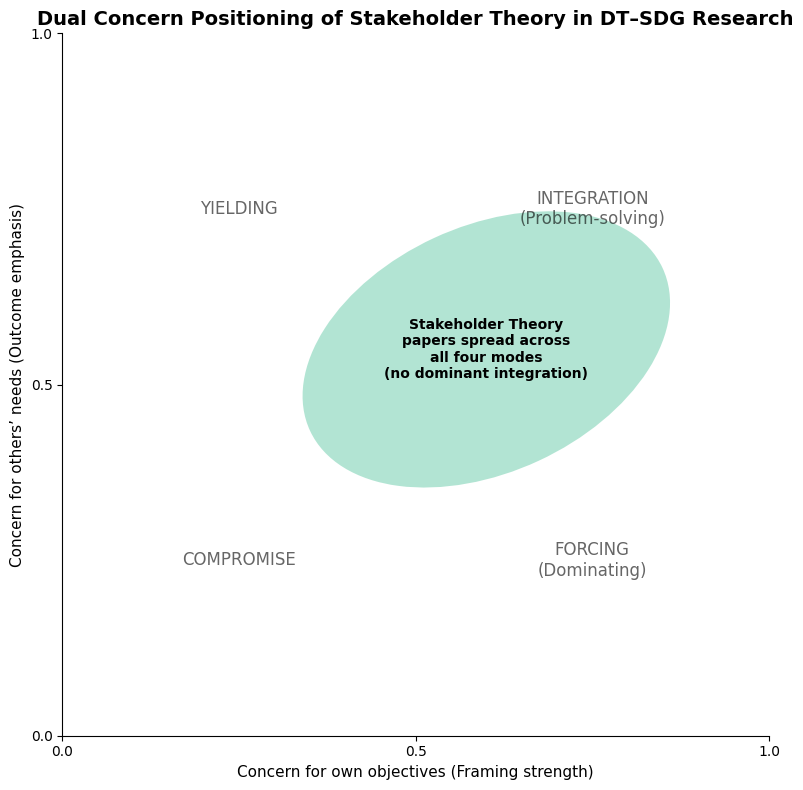

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# -----------------------------
# Load data
# -----------------------------
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"
df = pd.read_csv(BASE_PATH + "Stakeholder_DualConcern_Overall_summary.csv")

# Normalize percentages to [0,1] for plotting intuition
pct = dict(zip(df["Dual Concern Mode"], df["Percent"]))

# -----------------------------
# Create base figure
# -----------------------------
fig, ax = plt.subplots(figsize=(8,8))

# Axes
ax.set_xlim(0,1)
ax.set_ylim(0,1)

ax.set_xlabel("Concern for own objectives (Framing strength)", fontsize=11)
ax.set_ylabel("Concern for others’ needs (Outcome emphasis)", fontsize=11)

ax.set_xticks([0,0.5,1])
ax.set_yticks([0,0.5,1])

# -----------------------------
# Quadrant labels
# -----------------------------
ax.text(0.25, 0.75, "YIELDING", ha="center", va="center", fontsize=12, alpha=0.6)
ax.text(0.75, 0.75, "INTEGRATION\n(Problem-solving)", ha="center", va="center", fontsize=12, alpha=0.6)
ax.text(0.25, 0.25, "COMPROMISE", ha="center", va="center", fontsize=12, alpha=0.6)
ax.text(0.75, 0.25, "FORCING\n(Dominating)", ha="center", va="center", fontsize=12, alpha=0.6)

# -----------------------------
# Ellipse representing empirical distribution
# -----------------------------
# Center roughly between Compromise and Forcing / Integration boundary
ellipse = Ellipse(
    xy=(0.6, 0.55),
    width=0.55,
    height=0.35,
    angle=25,
    facecolor="#7FD3B6",
    alpha=0.6,
    edgecolor=None
)

ax.add_patch(ellipse)

# -----------------------------
# Annotation
# -----------------------------
ax.text(
    0.6, 0.55,
    "Stakeholder Theory\npapers spread across\nall four modes\n(no dominant integration)",
    ha="center", va="center",
    fontsize=10, weight="bold"
)

ax.set_title(
    "Dual Concern Positioning of Stakeholder Theory in DT–SDG Research",
    fontsize=14, weight="bold"
)

ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

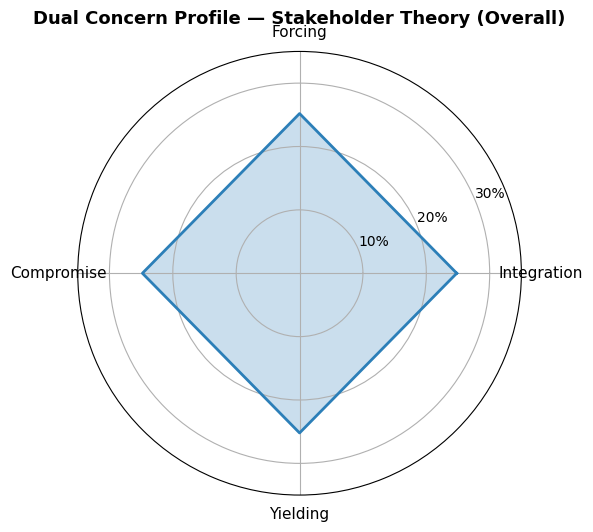

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"
df = pd.read_csv(BASE_PATH + "Stakeholder_DualConcern_Overall_summary.csv")

# Order categories explicitly
categories = ["Integration", "Forcing", "Compromise", "Yielding"]
values = [df.loc[df["Dual Concern Mode"] == c, "Percent"].values[0] for c in categories]

# Close the circle
values += values[:1]
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

# -----------------------------
# Create spider chart
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

ax.plot(angles, values, color="#2C7FB8", linewidth=2)
ax.fill(angles, values, color="#2C7FB8", alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)

ax.set_yticks([10, 20, 30])
ax.set_yticklabels(["10%", "20%", "30%"], fontsize=10)
ax.set_ylim(0, 35)

ax.set_title(
    "Dual Concern Profile — Stakeholder Theory (Overall)",
    fontsize=13, weight="bold", pad=20
)

plt.tight_layout()
plt.show()

Columns in file: ['dominant_sdg', 'dual_concern_mode', 'Count', 'Percent']


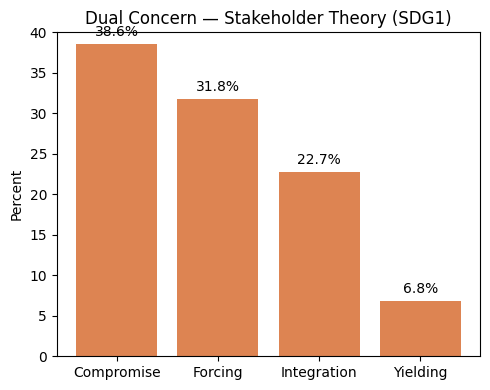

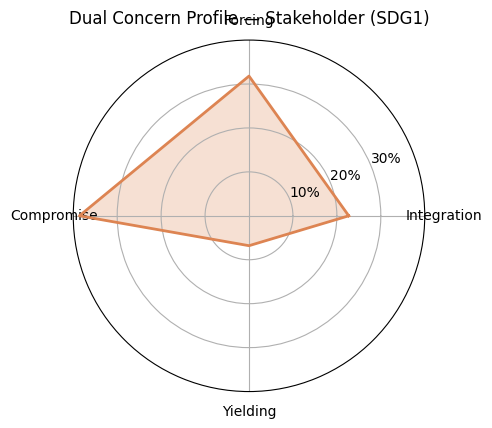

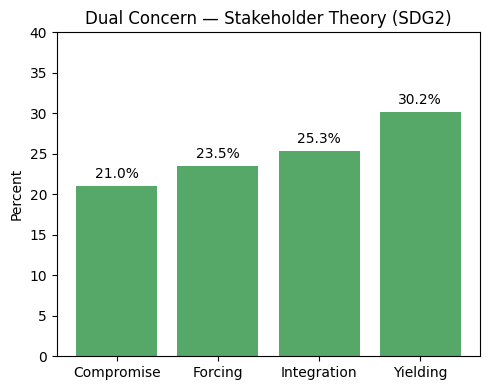

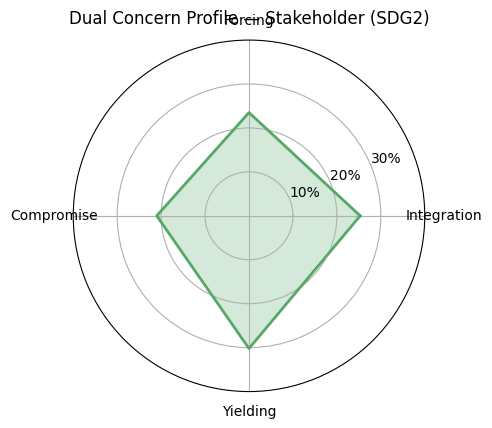

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"

# Load
df = pd.read_csv(BASE + "Stakeholder_DualConcern_SDG_Split_summary.csv")

# Sanity check
print("Columns in file:", df.columns.tolist())

# Correct column names
MODE_COL = "dual_concern_mode"
SDG_COL  = "dominant_sdg"
PCT_COL  = "Percent"

# -----------------------------
# SDG1 — Bar (LFC)
# -----------------------------
df1 = df[df[SDG_COL] == "SDG1_No_Poverty"]

plt.figure(figsize=(5,4))
plt.bar(df1[MODE_COL], df1[PCT_COL], color="#DD8452")
plt.title("Dual Concern — Stakeholder Theory (SDG1)")
plt.ylabel("Percent")
plt.ylim(0,40)

for i,v in enumerate(df1[PCT_COL]):
    plt.text(i, v+1, f"{v}%", ha="center")

plt.tight_layout()
plt.show()

# -----------------------------
# SDG1 — Spider
# -----------------------------
cats = ["Integration","Forcing","Compromise","Yielding"]
vals1 = [df1.loc[df1[MODE_COL]==c, PCT_COL].values[0] for c in cats]

angles = np.linspace(0,2*np.pi,len(cats),endpoint=False).tolist()
vals1 += vals1[:1]; angles += angles[:1]

fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(polar=True))
ax.plot(angles, vals1, lw=2, color="#DD8452")
ax.fill(angles, vals1, alpha=.25, color="#DD8452")
ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats)
ax.set_yticks([10,20,30]); ax.set_yticklabels(["10%","20%","30%"])
ax.set_ylim(0,40)
ax.set_title("Dual Concern Profile — Stakeholder (SDG1)", pad=12)
plt.tight_layout()
plt.show()

# -----------------------------
# SDG2 — Bar (LFC)
# -----------------------------
df2 = df[df[SDG_COL] == "SDG2_Zero_Hunger"]

plt.figure(figsize=(5,4))
plt.bar(df2[MODE_COL], df2[PCT_COL], color="#55A868")
plt.title("Dual Concern — Stakeholder Theory (SDG2)")
plt.ylabel("Percent")
plt.ylim(0,40)

for i,v in enumerate(df2[PCT_COL]):
    plt.text(i, v+1, f"{v}%", ha="center")

plt.tight_layout()
plt.show()

# -----------------------------
# SDG2 — Spider
# -----------------------------
vals2 = [df2.loc[df2[MODE_COL]==c, PCT_COL].values[0] for c in cats]
vals2 += vals2[:1]

fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(polar=True))
ax.plot(angles, vals2, lw=2, color="#55A868")
ax.fill(angles, vals2, alpha=.25, color="#55A868")
ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats)
ax.set_yticks([10,20,30]); ax.set_yticklabels(["10%","20%","30%"])
ax.set_ylim(0,40)
ax.set_title("Dual Concern Profile — Stakeholder (SDG2)", pad=12)
plt.tight_layout()
plt.show()

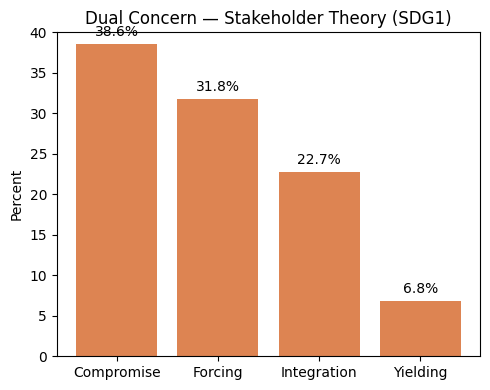

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(BASE + "Stakeholder_DualConcern_SDG_Split_summary.csv")
df1 = df[df["dominant_sdg"]=="SDG1_No_Poverty"]

plt.figure(figsize=(5,4))
plt.bar(df1["dual_concern_mode"], df1["Percent"], color="#DD8452")
plt.title("Dual Concern — Stakeholder Theory (SDG1)")
plt.ylabel("Percent")
plt.ylim(0,40)

for i,v in enumerate(df1["Percent"]):
    plt.text(i, v+1, f"{v}%", ha="center")

plt.tight_layout()
plt.show()

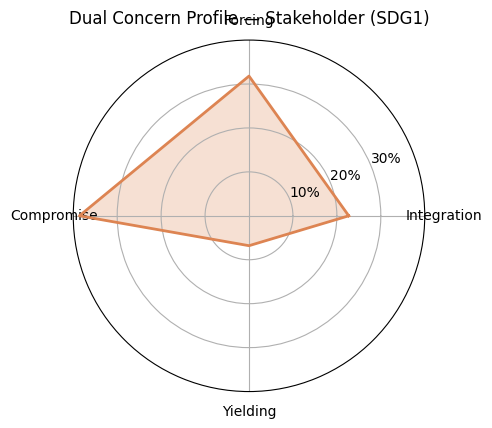

In [ ]:
import numpy as np

cats = ["Integration","Forcing","Compromise","Yielding"]
vals1 = [df1.loc[df1["dual_concern_mode"]==c,"Percent"].values[0] for c in cats]
angles = np.linspace(0,2*np.pi,len(cats),endpoint=False).tolist()
vals1 += vals1[:1]; angles += angles[:1]

fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(polar=True))
ax.plot(angles, vals1, lw=2, color="#DD8452")
ax.fill(angles, vals1, alpha=.25, color="#DD8452")
ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats)
ax.set_yticks([10,20,30]); ax.set_yticklabels(["10%","20%","30%"])
ax.set_ylim(0,40)
ax.set_title("Dual Concern Profile — Stakeholder (SDG1)", pad=12)
plt.tight_layout()
plt.show()

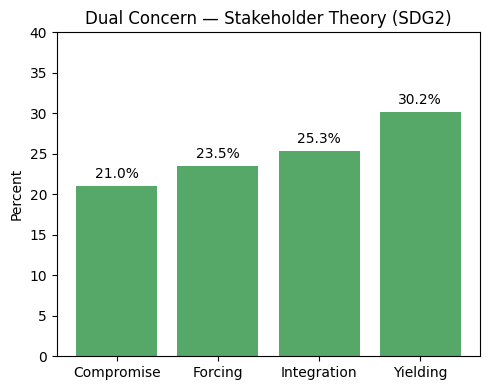

In [ ]:
df2 = df[df["dominant_sdg"]=="SDG2_Zero_Hunger"]

plt.figure(figsize=(5,4))
plt.bar(df2["dual_concern_mode"], df2["Percent"], color="#55A868")
plt.title("Dual Concern — Stakeholder Theory (SDG2)")
plt.ylabel("Percent")
plt.ylim(0,40)

for i,v in enumerate(df2["Percent"]):
    plt.text(i, v+1, f"{v}%", ha="center")

plt.tight_layout()
plt.show()

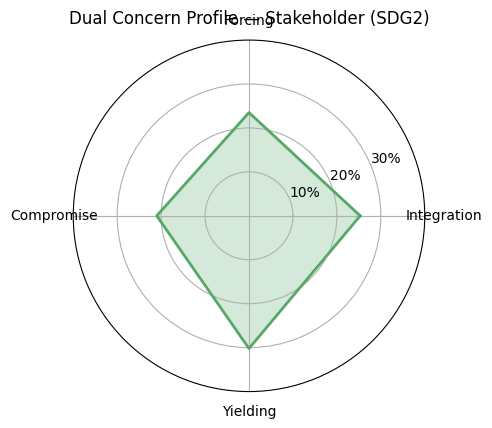

In [ ]:
vals2 = [df2.loc[df2["dual_concern_mode"]==c,"Percent"].values[0] for c in cats]
vals2 += vals2[:1]

fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(polar=True))
ax.plot(angles, vals2, lw=2, color="#55A868")
ax.fill(angles, vals2, alpha=.25, color="#55A868")
ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats)
ax.set_yticks([10,20,30]); ax.set_yticklabels(["10%","20%","30%"])
ax.set_ylim(0,40)
ax.set_title("Dual Concern Profile — Stakeholder (SDG2)", pad=12)
plt.tight_layout()
plt.show()

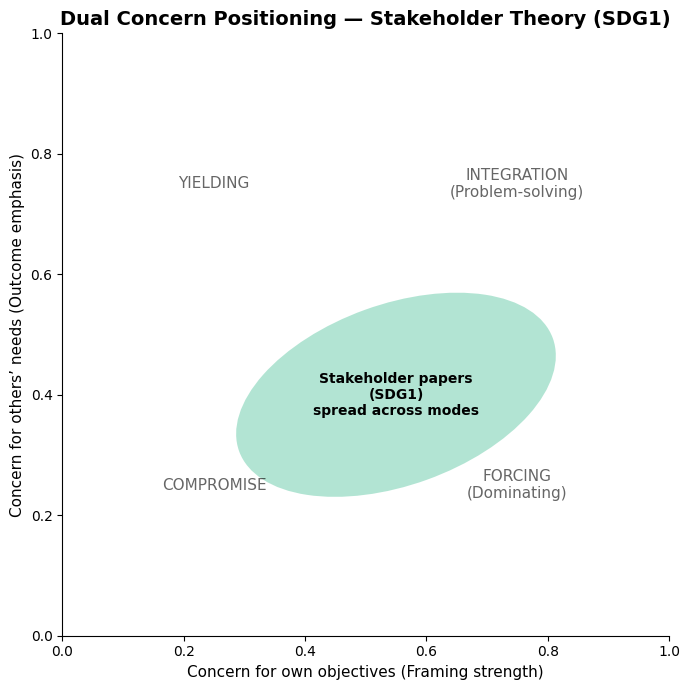

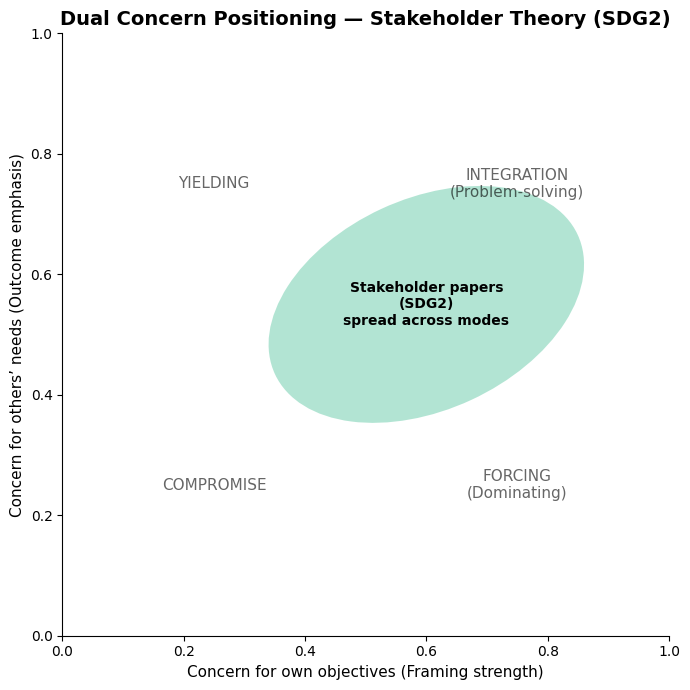

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

BASE = "/content/drive/MyDrive/Colab Notebooks/DTOSDG12/results/"
df = pd.read_csv(BASE + "Stakeholder_DualConcern_SDG_Split_summary.csv")

def draw_dual_concern(sdg_label, title, ellipse_center, ellipse_size, angle):
    fig, ax = plt.subplots(figsize=(7,7))
    ax.set_xlim(0,1); ax.set_ylim(0,1)

    # Axes labels
    ax.set_xlabel("Concern for own objectives (Framing strength)", fontsize=11)
    ax.set_ylabel("Concern for others’ needs (Outcome emphasis)", fontsize=11)

    # Quadrant labels
    ax.text(0.25,0.75,"YIELDING", ha="center", va="center", fontsize=11, alpha=.6)
    ax.text(0.75,0.75,"INTEGRATION\n(Problem-solving)", ha="center", va="center", fontsize=11, alpha=.6)
    ax.text(0.25,0.25,"COMPROMISE", ha="center", va="center", fontsize=11, alpha=.6)
    ax.text(0.75,0.25,"FORCING\n(Dominating)", ha="center", va="center", fontsize=11, alpha=.6)

    # Ellipse (empirical spread)
    e = Ellipse(
        xy=ellipse_center,
        width=ellipse_size[0],
        height=ellipse_size[1],
        angle=angle,
        facecolor="#7FD3B6",
        alpha=0.6
    )
    ax.add_patch(e)

    # Annotation
    ax.text(
        ellipse_center[0], ellipse_center[1],
        f"Stakeholder papers\n({sdg_label})\nspread across modes",
        ha="center", va="center",
        fontsize=10, weight="bold"
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()

# -------- Figure A: SDG1 --------
draw_dual_concern(
    sdg_label="SDG1",
    title="Dual Concern Positioning — Stakeholder Theory (SDG1)",
    ellipse_center=(0.55, 0.40),     # more forcing/compromise
    ellipse_size=(0.55, 0.30),
    angle=20
)

# -------- Figure B: SDG2 --------
draw_dual_concern(
    sdg_label="SDG2",
    title="Dual Concern Positioning — Stakeholder Theory (SDG2)",
    ellipse_center=(0.60, 0.55),     # slightly closer to integration
    ellipse_size=(0.55, 0.35),
    angle=25
)

In [5]:
import pandas as pd

base = "/content/drive/MyDrive/Colab Notebooks/DTSDG12/files/"
result_path = "/content/drive/MyDrive/Colab Notebooks/DTSDG12/results/"

centrality = pd.read_csv(result_path + "DT_theory_centrality.csv")

print(centrality.head())
print(centrality.columns)

                 theory  degree  betweenness  eigenvector
0                   TOE       8          0.0     0.333333
1  Dynamic_Capabilities       8          0.0     0.333333
2                 UTAUT       8          0.0     0.333333
3                   TAM       8          0.0     0.333333
4                   RBV       8          0.0     0.333333
Index(['theory', 'degree', 'betweenness', 'eigenvector'], dtype='object')


In [6]:
print(pd.read_csv(result_path + "Stakeholder_DualConcern_SDG_Split_document_level.csv").head())

   paper_id      dominant_sdg  assertive_per_1000w  cooperative_per_1000w  \
0  SDG1-346  SDG2_Zero_Hunger             1.098982               6.081032   
1  SDG1-336  SDG2_Zero_Hunger             1.429933               0.476644   
2  SDG1-339  SDG2_Zero_Hunger            21.923621               0.101031   
3  SDG1-333   SDG1_No_Poverty             0.842310               0.050420   
4  SDG1-001   SDG1_No_Poverty             1.788909               0.715564   

  dual_concern_mode  
0          Yielding  
1           Forcing  
2           Forcing  
3        Compromise  
4           Forcing  


In [11]:
import pandas as pd

base = "/content/drive/MyDrive/Colab Notebooks/DTSDG12/files/"
result_path = "/content/drive/MyDrive/Colab Notebooks/DTSDG12/results/"

df_test = pd.read_excel(result_path + "SDG1_DT_similarity.xlsx")
print(df_test.head())
print(df_test.columns)

   paper_id  SDG1_No_Poverty              sdg
0  SDG1-349         0.130959  SDG1_No_Poverty
1  SDG1-350         0.100637  SDG1_No_Poverty
2  SDG1-352         0.074855  SDG1_No_Poverty
3  SDG1-345         0.178427  SDG1_No_Poverty
4  SDG1-346         0.345245  SDG1_No_Poverty
Index(['paper_id', 'SDG1_No_Poverty', 'sdg'], dtype='object')


# Graph Similarity

In [13]:
import os

base = "/content/drive/MyDrive/Colab Notebooks/DTSDG12/files/"
print(len(os.listdir(base)))
print(os.listdir(base)[:10])

753
['SDG1-001.docx', 'SDG1-002.docx', 'SDG1-003.docx', 'SDG1-004.docx', 'SDG1-005.docx', 'SDG1-006.docx', 'SDG1-007.docx', 'SDG1-008.docx', 'SDG1-009.docx', 'SDG1-010.docx']


In [15]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 3.6 MB/s eta 0:00:00


In [16]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
from docx import Document

In [20]:
import os
import pandas as pd
from docx import Document

base = "/content/drive/MyDrive/Colab Notebooks/DTSDG12/files/"

def read_docx_safe(path):
    try:
        doc = Document(path)
        return " ".join(p.text for p in doc.paragraphs)
    except Exception as e:
        return None  # skip corrupted file

rows = []
skipped = 0

for f in os.listdir(base):
    if f.endswith(".docx"):
        text = read_docx_safe(os.path.join(base, f))
        if text is not None:
            rows.append([f.replace(".docx","").upper(), text])
        else:
            skipped += 1

df_documents = pd.DataFrame(rows, columns=["paper_id","text"])

print("Documents loaded:", len(df_documents))
print("Files skipped (corrupt):", skipped)

Documents loaded: 752
Files skipped (corrupt): 1


In [21]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

embeddings = model.encode(
    df_documents["text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

print("Embedding shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Embedding shape: (752, 384)


In [22]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)
print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (752, 752)


In [23]:
import networkx as nx

threshold = 0.65
G = nx.Graph()

# add nodes
for pid in df_documents["paper_id"]:
    G.add_node(pid)

# add edges
for i in range(len(similarity_matrix)):
    for j in range(i+1, len(similarity_matrix)):
        if similarity_matrix[i,j] > threshold:
            G.add_edge(
                df_documents.iloc[i]["paper_id"],
                df_documents.iloc[j]["paper_id"],
                weight=similarity_matrix[i,j]
            )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 752
Edges: 1852


In [24]:
centrality = nx.eigenvector_centrality(G, max_iter=1000)

df_documents["eigenvector"] = df_documents["paper_id"].map(centrality)

print(df_documents["eigenvector"].describe())

count    7.520000e+02
mean     1.200919e-02
std      3.445497e-02
min      2.071610e-24
25%      2.071610e-24
50%      2.381959e-06
75%      3.465442e-03
max      2.298042e-01
Name: eigenvector, dtype: float64


In [25]:
theory_map = pd.read_csv(result_path + "dt_theory_similarity_matrix.csv")[["paper_id","dominant_dt_theory"]]

df_bridge = df_documents.merge(theory_map, on="paper_id")

theory_centrality = (
    df_bridge
    .groupby("dominant_dt_theory")["eigenvector"]
    .mean()
    .reset_index()
    .rename(columns={"eigenvector":"mean_eigenvector"})
)

print(theory_centrality.sort_values("mean_eigenvector", ascending=False))

     dominant_dt_theory  mean_eigenvector
7                   TOE          0.024317
6                   TAM          0.021581
0  Dynamic_Capabilities          0.018587
1                   IDT          0.010839
5    Stakeholder_Theory          0.010794
4                   STS          0.005974
8                 UTAUT          0.003919
2          Just_Digital          0.002845
3                   RBV          0.002514


In [26]:
assertive_terms = [
    "governance","regulation","compliance","control","oversight",
    "institutional","organizational","management","decision-making",
    "strategy","framework","implementation","coordination","authority"
]

cooperative_terms = [
    "outcome","impact","human","social","wellbeing","welfare",
    "livelihood","poverty","inequality","equity","inclusion",
    "food","nutrition","hunger","vulnerable","community","access"
]

In [27]:
import re

def count_terms(text, terms):
    return sum(len(re.findall(r"\b"+re.escape(t)+r"\b", text.lower())) for t in terms)

rows = []

for _, row in df_documents.iterrows():
    text = row["text"]
    wc = max(len(text.split()),1)

    a = count_terms(text, assertive_terms) / wc * 1000
    c = count_terms(text, cooperative_terms) / wc * 1000

    rows.append([row["paper_id"], a, c])

df_dc = pd.DataFrame(
    rows,
    columns=["paper_id","assertive_per_1000w","cooperative_per_1000w"]
)

print(df_dc.describe())

       assertive_per_1000w  cooperative_per_1000w
count           752.000000             752.000000
mean              6.808308              17.005988
std               5.929295              12.207257
min               0.000000               0.000000
25%               2.629744               7.818199
50%               4.940678              13.988667
75%               8.977193              22.509836
max              40.685225              73.458923


In [28]:
a_thr = df_dc["assertive_per_1000w"].median()
c_thr = df_dc["cooperative_per_1000w"].median()

print("Assertive threshold:", a_thr)
print("Cooperative threshold:", c_thr)

Assertive threshold: 4.940678244503624
Cooperative threshold: 13.988667249052327


In [29]:
def classify(row):
    hi_a = row["assertive_per_1000w"] >= a_thr
    hi_c = row["cooperative_per_1000w"] >= c_thr

    if hi_a and hi_c:
        return "Integration"
    elif hi_a and not hi_c:
        return "Forcing"
    elif not hi_a and hi_c:
        return "Yielding"
    else:
        return "Compromise"

df_dc["dual_concern_mode"] = df_dc.apply(classify, axis=1)

In [30]:
theory_map = pd.read_csv(result_path + "dt_theory_similarity_matrix.csv")[["paper_id","dominant_dt_theory"]]

df_full = df_dc.merge(theory_map, on="paper_id")

theory_dual = (
    df_full
    .groupby("dominant_dt_theory")["dual_concern_mode"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)

print(theory_dual.round(2))

dual_concern_mode     Compromise  Forcing  Integration  Yielding
dominant_dt_theory                                              
Dynamic_Capabilities        7.56    52.94        20.17     19.33
IDT                        47.83    30.43         4.35     17.39
Just_Digital               13.46    17.31        26.92     42.31
RBV                        18.60    25.58        24.42     31.40
STS                        28.57    28.57         4.76     38.10
Stakeholder_Theory         15.35    17.33        32.67     34.65
TAM                        41.54    26.15         7.69     24.62
TOE                        15.38    46.15        18.68     19.78
UTAUT                      45.83    16.67        13.89     23.61


In [31]:
bridge = theory_centrality.merge(
    theory_dual["Integration"].reset_index().rename(columns={"Integration":"percent_integration"}),
    on="dominant_dt_theory"
)

print(bridge.sort_values("mean_eigenvector", ascending=False))

     dominant_dt_theory  mean_eigenvector  percent_integration
7                   TOE          0.024317            18.681319
6                   TAM          0.021581             7.692308
0  Dynamic_Capabilities          0.018587            20.168067
1                   IDT          0.010839             4.347826
5    Stakeholder_Theory          0.010794            32.673267
4                   STS          0.005974             4.761905
8                 UTAUT          0.003919            13.888889
2          Just_Digital          0.002845            26.923077
3                   RBV          0.002514            24.418605


In [32]:
from scipy.stats import spearmanr

corr, p = spearmanr(bridge["mean_eigenvector"], bridge["percent_integration"])
print("Spearman correlation:", corr)
print("p-value:", p)

Spearman correlation: -0.33333333333333337
p-value: 0.38071318167686347


In [33]:
base = "/content/drive/MyDrive/Colab Notebooks/DTSDG12/files/"
result_path = "/content/drive/MyDrive/Colab Notebooks/DTSDG12/results/"

/tmp/ipykernel_8364/2977871365.py:78: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(bridge["eigenvector"], bridge["percent_integration"], 1)


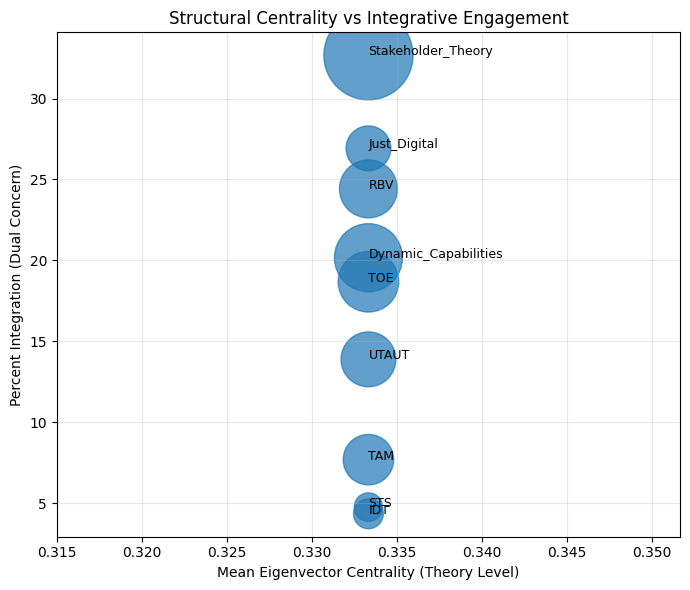

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

result_path = "/content/drive/MyDrive/Colab Notebooks/DTSDG12/results/"

# Load centrality
centrality = pd.read_csv(result_path + "DT_theory_centrality.csv")

# Load theory dominance (for counts)
theory_map = pd.read_csv(result_path + "dt_theory_similarity_matrix.csv")[["paper_id","dominant_dt_theory"]]

# Load Dual Concern (already computed earlier)
# If you saved bridge table, use it directly; otherwise recompute:
# bridge must already exist from previous step
# If not, reconstruct from files:

# Recompute integration %
dual_doc = pd.read_csv(result_path + "Stakeholder_DualConcern_SDG_Split_document_level.csv")

# ⚠️ If dual_doc only has Stakeholder, skip this part.
# Otherwise use df_full from previous session if available.

# For safety, we assume you still have df_full in memory.
# If not, stop and tell me.

# Build integration %
theory_dual = (
    df_full
    .groupby("dominant_dt_theory")["dual_concern_mode"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)

integration = theory_dual["Integration"].reset_index().rename(
    columns={"Integration":"percent_integration"}
)

# Merge with centrality
bridge = centrality.merge(
    integration,
    left_on="theory",
    right_on="dominant_dt_theory"
)

# Add counts
counts = theory_map["dominant_dt_theory"].value_counts().reset_index()
counts.columns = ["theory","paper_count"]

bridge = bridge.merge(counts, on="theory")

# ------------------------------------
# Plot
# ------------------------------------
plt.figure(figsize=(7,6))

sizes = bridge["paper_count"] * 20

plt.scatter(
    bridge["eigenvector"],
    bridge["percent_integration"],
    s=sizes,
    alpha=0.7
)

# Label points
for _, row in bridge.iterrows():
    plt.text(
        row["eigenvector"],
        row["percent_integration"],
        row["theory"],
        fontsize=9
    )

# Optional regression line
z = np.polyfit(bridge["eigenvector"], bridge["percent_integration"], 1)
p = np.poly1d(z)
plt.plot(
    bridge["eigenvector"],
    p(bridge["eigenvector"]),
    linestyle="--"
)

plt.xlabel("Mean Eigenvector Centrality (Theory Level)")
plt.ylabel("Percent Integration (Dual Concern)")
plt.title("Structural Centrality vs Integrative Engagement")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Total ANalysis

In [36]:
theory_dual_full = (
    df_full
    .groupby("dominant_dt_theory")["dual_concern_mode"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0) * 100
)

bridge_full = (
    centrality
    .merge(theory_dual_full.reset_index(),
           left_on="theory",
           right_on="dominant_dt_theory")
)

In [37]:
print(theory_dual_full.round(2))
print(bridge_full.round(3))

dual_concern_mode     Compromise  Forcing  Integration  Yielding
dominant_dt_theory                                              
Dynamic_Capabilities        7.56    52.94        20.17     19.33
IDT                        47.83    30.43         4.35     17.39
Just_Digital               13.46    17.31        26.92     42.31
RBV                        18.60    25.58        24.42     31.40
STS                        28.57    28.57         4.76     38.10
Stakeholder_Theory         15.35    17.33        32.67     34.65
TAM                        41.54    26.15         7.69     24.62
TOE                        15.38    46.15        18.68     19.78
UTAUT                      45.83    16.67        13.89     23.61
                 theory  degree  betweenness  eigenvector  \
0                   TOE       8          0.0        0.333   
1  Dynamic_Capabilities       8          0.0        0.333   
2                 UTAUT       8          0.0        0.333   
3                   TAM       8          

In [38]:
# Paper-level centrality already in df_documents["eigenvector"]

# Merge with theory
theory_map = pd.read_csv(result_path + "dt_theory_similarity_matrix.csv")[["paper_id","dominant_dt_theory"]]

df_bridge_real = df_documents.merge(theory_map, on="paper_id")

# Theory-level mean centrality
theory_centrality_real = (
    df_bridge_real
    .groupby("dominant_dt_theory")["eigenvector"]
    .mean()
    .reset_index()
    .rename(columns={"eigenvector":"mean_eigenvector"})
)

print(theory_centrality_real.sort_values("mean_eigenvector", ascending=False))

     dominant_dt_theory  mean_eigenvector
7                   TOE          0.024317
6                   TAM          0.021581
0  Dynamic_Capabilities          0.018587
1                   IDT          0.010839
5    Stakeholder_Theory          0.010794
4                   STS          0.005974
8                 UTAUT          0.003919
2          Just_Digital          0.002845
3                   RBV          0.002514


In [39]:
bridge_real = theory_centrality_real.merge(
    theory_dual_full.reset_index(),
    on="dominant_dt_theory"
)

print(bridge_real.round(3))

     dominant_dt_theory  mean_eigenvector  Compromise  Forcing  Integration  \
0  Dynamic_Capabilities             0.019       7.563   52.941       20.168   
1                   IDT             0.011      47.826   30.435        4.348   
2          Just_Digital             0.003      13.462   17.308       26.923   
3                   RBV             0.003      18.605   25.581       24.419   
4                   STS             0.006      28.571   28.571        4.762   
5    Stakeholder_Theory             0.011      15.347   17.327       32.673   
6                   TAM             0.022      41.538   26.154        7.692   
7                   TOE             0.024      15.385   46.154       18.681   
8                 UTAUT             0.004      45.833   16.667       13.889   

   Yielding  
0    19.328  
1    17.391  
2    42.308  
3    31.395  
4    38.095  
5    34.653  
6    24.615  
7    19.780  
8    23.611  


In [40]:
from scipy.stats import spearmanr

for col in ["Integration","Forcing","Yielding","Compromise"]:
    corr, p = spearmanr(bridge_real["mean_eigenvector"], bridge_real[col])
    print(col, "→ Spearman:", round(corr,3), "p:", round(p,3))

Integration → Spearman: -0.333 p: 0.381
Forcing → Spearman: 0.7 p: 0.036
Yielding → Spearman: -0.583 p: 0.099
Compromise → Spearman: 0.0 p: 1.0


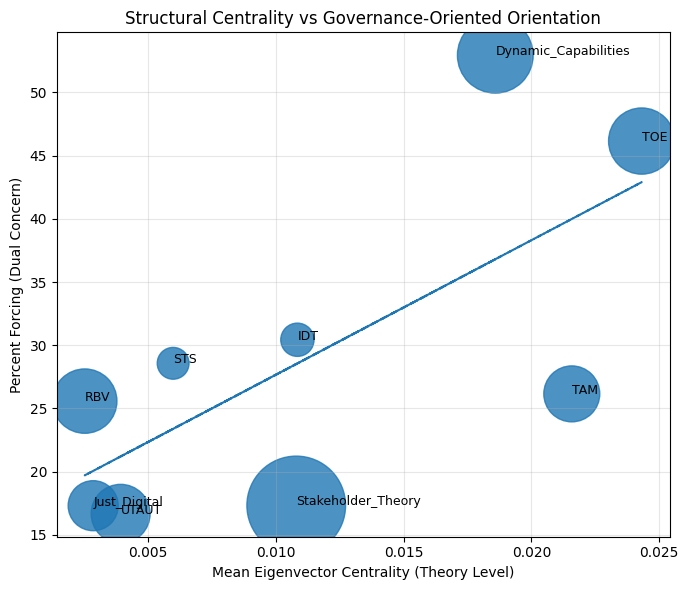

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# bridge_real قبلاً ساخته شده
# اگر نیست، قبلش آن را بازسازی کن

plt.figure(figsize=(7,6))

# اندازه نقاط بر اساس تعداد مقاله‌های هر نظریه
counts = df_bridge_real["dominant_dt_theory"].value_counts().reset_index()
counts.columns = ["theory","paper_count"]

bridge_plot = bridge_real.merge(counts, left_on="dominant_dt_theory", right_on="theory")

sizes = bridge_plot["paper_count"] * 25

plt.scatter(
    bridge_plot["mean_eigenvector"],
    bridge_plot["Forcing"],
    s=sizes,
    alpha=0.8
)

# برچسب نظریه‌ها
for _, row in bridge_plot.iterrows():
    plt.text(
        row["mean_eigenvector"],
        row["Forcing"],
        row["dominant_dt_theory"],
        fontsize=9
    )

# خط روند
z = np.polyfit(bridge_plot["mean_eigenvector"], bridge_plot["Forcing"], 1)
p = np.poly1d(z)
plt.plot(
    bridge_plot["mean_eigenvector"],
    p(bridge_plot["mean_eigenvector"]),
    linestyle="--"
)

plt.xlabel("Mean Eigenvector Centrality (Theory Level)")
plt.ylabel("Percent Forcing (Dual Concern)")
plt.title("Structural Centrality vs Governance-Oriented Orientation")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Stakeholder

In [42]:
stakeholder_terms = [
"stakeholder","beneficiary","community","citizen","user",
"farmer","producer","consumer","household","ngo","government",
"regulator","policy maker","investor","private sector",
"vulnerable","marginalized","smallholder"
]

In [44]:
categories = {
    "government": ["government","regulator","policy maker","state","public authority"],
    "market": ["firm","company","private sector","investor","enterprise"],
    "community": ["community","citizen","local population","household"],
    "civil_society": ["ngo","nonprofit","association","cooperative"],
    "vulnerable_groups": ["vulnerable","marginalized","smallholder","low-income","poor"]
}

In [45]:
# -----------------------------------------
# Stakeholder Lexicon
# -----------------------------------------

stakeholder_terms = [
    "stakeholder","beneficiary","community","citizen","user",
    "farmer","producer","consumer","household",
    "ngo","nonprofit","association","cooperative",
    "government","regulator","policy maker","state","authority",
    "investor","private sector","enterprise",
    "vulnerable","marginalized","smallholder","low-income","poor"
]

stakeholder_categories = {
    "government": ["government","regulator","policy maker","state","authority"],
    "market": ["firm","company","enterprise","investor","private sector","producer","consumer"],
    "community": ["community","citizen","household","user"],
    "civil_society": ["ngo","nonprofit","association","cooperative"],
    "vulnerable_groups": ["vulnerable","marginalized","smallholder","low-income","poor"]
}

In [46]:
import re
import pandas as pd

def count_terms(text, terms):
    return sum(len(re.findall(r"\b"+re.escape(t)+r"\b", text.lower())) for t in terms)

rows = []

for _, row in df_documents.iterrows():
    text = row["text"]
    wc = max(len(text.split()),1)

    # Frequency
    freq = count_terms(text, stakeholder_terms)
    freq_per_1000 = freq / wc * 1000

    # Diversity simple
    unique_terms = [t for t in stakeholder_terms if re.search(r"\b"+re.escape(t)+r"\b", text.lower())]
    diversity_simple = len(set(unique_terms))

    # Diversity categorized
    diversity_cat = 0
    for cat, terms in stakeholder_categories.items():
        if any(re.search(r"\b"+re.escape(t)+r"\b", text.lower()) for t in terms):
            diversity_cat += 1

    rows.append([
        row["paper_id"],
        freq_per_1000,
        diversity_simple,
        diversity_cat
    ])

df_stake = pd.DataFrame(
    rows,
    columns=[
        "paper_id",
        "stakeholder_signal_per_1000w",
        "stakeholder_diversity_simple",
        "stakeholder_diversity_category"
    ]
)

print(df_stake.describe())

       stakeholder_signal_per_1000w  stakeholder_diversity_simple  \
count                    752.000000                    752.000000   
mean                       5.445177                      8.061170   
std                        4.126757                      3.735814   
min                        0.000000                      0.000000   
25%                        2.451797                      6.000000   
50%                        4.560054                      8.000000   
75%                        7.167665                     10.000000   
max                       31.169137                     23.000000   

       stakeholder_diversity_category  
count                      752.000000  
mean                         3.932181  
std                          1.084660  
min                          0.000000  
25%                          3.000000  
50%                          4.000000  
75%                          5.000000  
max                          5.000000  


In [47]:
# merge with theory + SDG
meta = pd.read_csv(result_path + "dt_theory_similarity_matrix.csv")[["paper_id","dominant_dt_theory"]]

df_full_stake = (
    df_stake
    .merge(meta, on="paper_id")
    .merge(df_dc[["paper_id","dual_concern_mode"]], on="paper_id")
)

print(df_full_stake.head())

   paper_id  stakeholder_signal_per_1000w  stakeholder_diversity_simple  \
0  SDG1-001                     12.283840                            12   
1  SDG1-002                      2.394254                             7   
2  SDG1-003                      5.022683                            11   
3  SDG1-004                      1.457726                             2   
4  SDG1-005                      7.300602                             8   

   stakeholder_diversity_category  dominant_dt_theory dual_concern_mode  
0                               4  Stakeholder_Theory          Yielding  
1                               3               UTAUT       Integration  
2                               5                 IDT        Compromise  
3                               2        Just_Digital           Forcing  
4                               4  Stakeholder_Theory           Forcing  


In [48]:
theory_stake_summary = (
    df_full_stake
    .groupby("dominant_dt_theory")[[
        "stakeholder_signal_per_1000w",
        "stakeholder_diversity_simple",
        "stakeholder_diversity_category"
    ]]
    .mean()
    .reset_index()
)

print(theory_stake_summary.round(2))

     dominant_dt_theory  stakeholder_signal_per_1000w  \
0  Dynamic_Capabilities                          3.75   
1                   IDT                          4.50   
2          Just_Digital                          5.34   
3                   RBV                          4.58   
4                   STS                          3.45   
5    Stakeholder_Theory                          7.67   
6                   TAM                          6.29   
7                   TOE                          5.07   
8                 UTAUT                          4.54   

   stakeholder_diversity_simple  stakeholder_diversity_category  
0                          7.66                            3.92  
1                          7.65                            4.00  
2                          8.21                            3.81  
3                          7.34                            3.85  
4                          6.76                            3.76  
5                          9.25  

In [49]:
from scipy.stats import spearmanr

for col in [
    "stakeholder_signal_per_1000w",
    "stakeholder_diversity_simple",
    "stakeholder_diversity_category"
]:
    corr, p = spearmanr(
        bridge_real["mean_eigenvector"],
        theory_stake_summary[col]
    )
    print(col, "→ Spearman:", round(corr,3), "p:", round(p,3))

stakeholder_signal_per_1000w → Spearman: 0.083 p: 0.831
stakeholder_diversity_simple → Spearman: 0.383 p: 0.308
stakeholder_diversity_category → Spearman: 0.5 p: 0.17


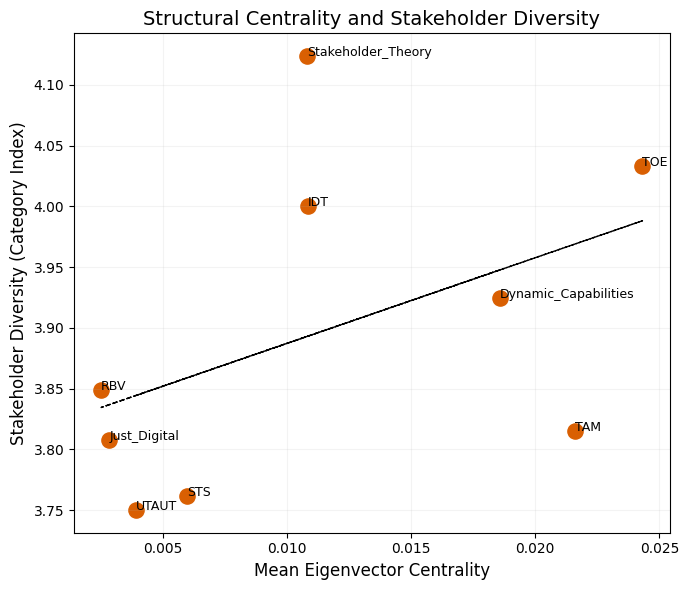

In [50]:
plt.figure(figsize=(7,6))

# merge stakeholder summary with centrality
bridge_stake = bridge_real.merge(
    theory_stake_summary,
    on="dominant_dt_theory"
)

x = bridge_stake["mean_eigenvector"]
y = bridge_stake["stakeholder_diversity_category"]

plt.scatter(x, y, s=120, color="#D95F02")

for i, txt in enumerate(bridge_stake["dominant_dt_theory"]):
    plt.annotate(txt, (x.iloc[i], y.iloc[i]), fontsize=9)

# regression line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), linestyle="--", color="black", linewidth=1)

plt.xlabel("Mean Eigenvector Centrality", fontsize=12)
plt.ylabel("Stakeholder Diversity (Category Index)", fontsize=12)
plt.title("Structural Centrality and Stakeholder Diversity", fontsize=14)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(alpha=0.15)
plt.tight_layout()

plt.savefig(result_path + "Figure_Centrality_vs_StakeholderDiversity.png", dpi=300)
plt.show()

Nodes: 752
Edges: 1852
Network density: 0.006558631045131314


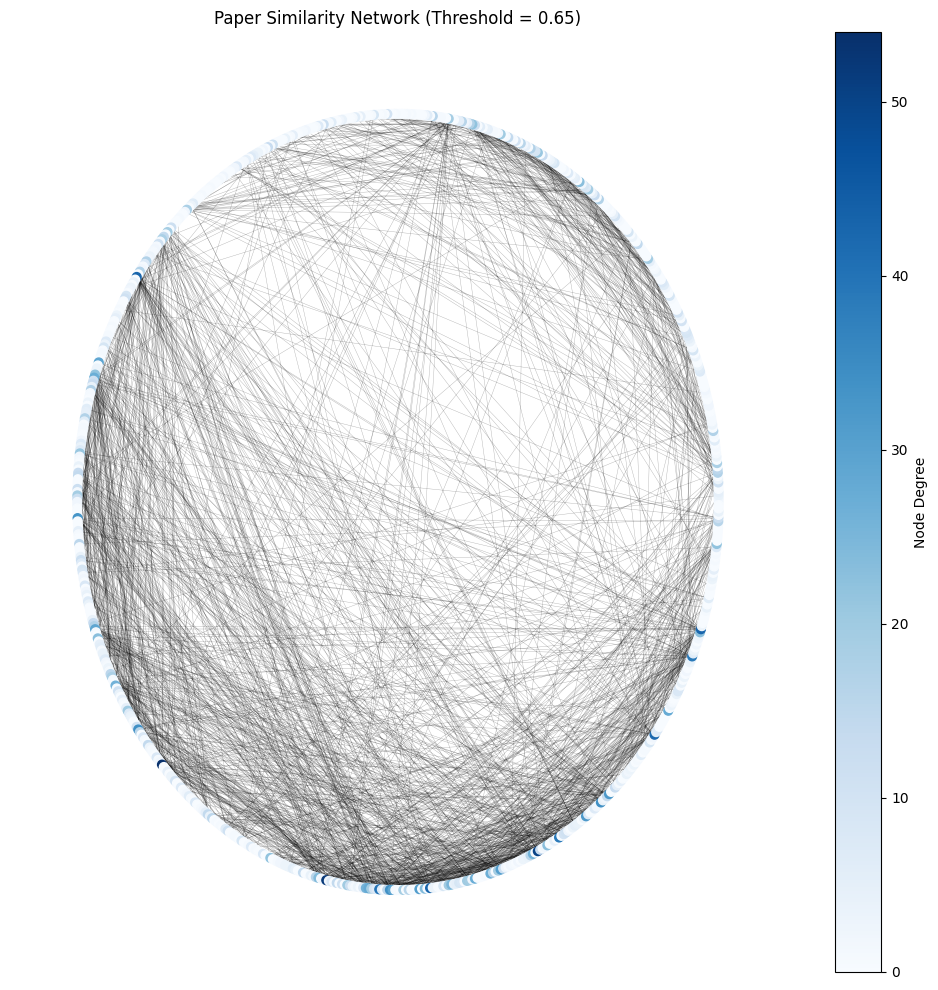

In [51]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------
# Threshold (adjust if too dense)
# ------------------------------------
threshold = 0.65

# Build graph
G = nx.Graph()

# Add nodes
for pid in df_documents["paper_id"]:
    G.add_node(pid)

# Add edges based on similarity
n = len(similarity_matrix)

for i in range(n):
    for j in range(i+1, n):
        if similarity_matrix[i, j] > threshold:
            G.add_edge(
                df_documents.iloc[i]["paper_id"],
                df_documents.iloc[j]["paper_id"]
            )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# ------------------------------------
# Degree calculation
# ------------------------------------
degree_dict = dict(G.degree())
nx.set_node_attributes(G, degree_dict, "degree")

# Network density
density = nx.density(G)
print("Network density:", density)

# ------------------------------------
# Circular layout
# ------------------------------------
plt.figure(figsize=(10,10))

pos = nx.circular_layout(G)

node_color = [degree_dict[node] for node in G.nodes()]
node_size = 40

nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_size,
    node_color=node_color,
    cmap=plt.cm.Blues
)

nx.draw_networkx_edges(
    G,
    pos,
    width=0.3,
    alpha=0.3
)

plt.title(f"Paper Similarity Network (Threshold = {threshold})")
cbar = plt.colorbar(nodes)
cbar.set_label("Node Degree")

plt.axis("off")
plt.tight_layout()

plt.savefig(result_path + "Figure_Paper_Similarity_Network.png", dpi=300)
plt.show()

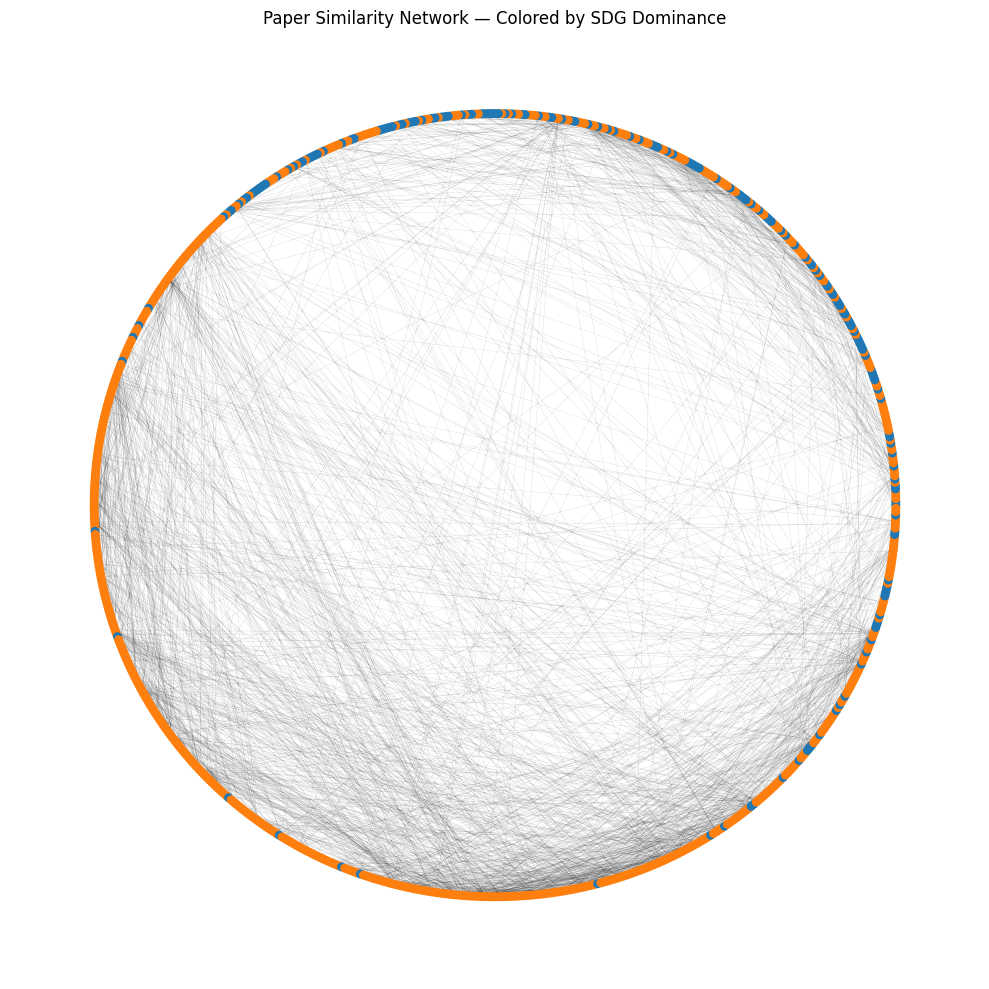

In [52]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Load SDG dominance
sdg_map = pd.read_csv(result_path + "SDG_dominance_table.csv")[["paper_id","dominant_sdg"]]

# Merge into dictionary
sdg_dict = dict(zip(sdg_map["paper_id"], sdg_map["dominant_sdg"]))

# Assign colors
node_colors = []
for node in G.nodes():
    if sdg_dict.get(node) == "SDG1_No_Poverty":
        node_colors.append("#1f77b4")  # blue
    else:
        node_colors.append("#ff7f0e")  # orange

plt.figure(figsize=(10,10))
pos = nx.circular_layout(G)

nx.draw_networkx_nodes(G, pos, node_size=30, node_color=node_colors)
nx.draw_networkx_edges(G, pos, width=0.2, alpha=0.2)

plt.title("Paper Similarity Network — Colored by SDG Dominance")
plt.axis("off")
plt.tight_layout()
plt.savefig(result_path + "Figure_SDG_Colored_Network.png", dpi=300)
plt.show()

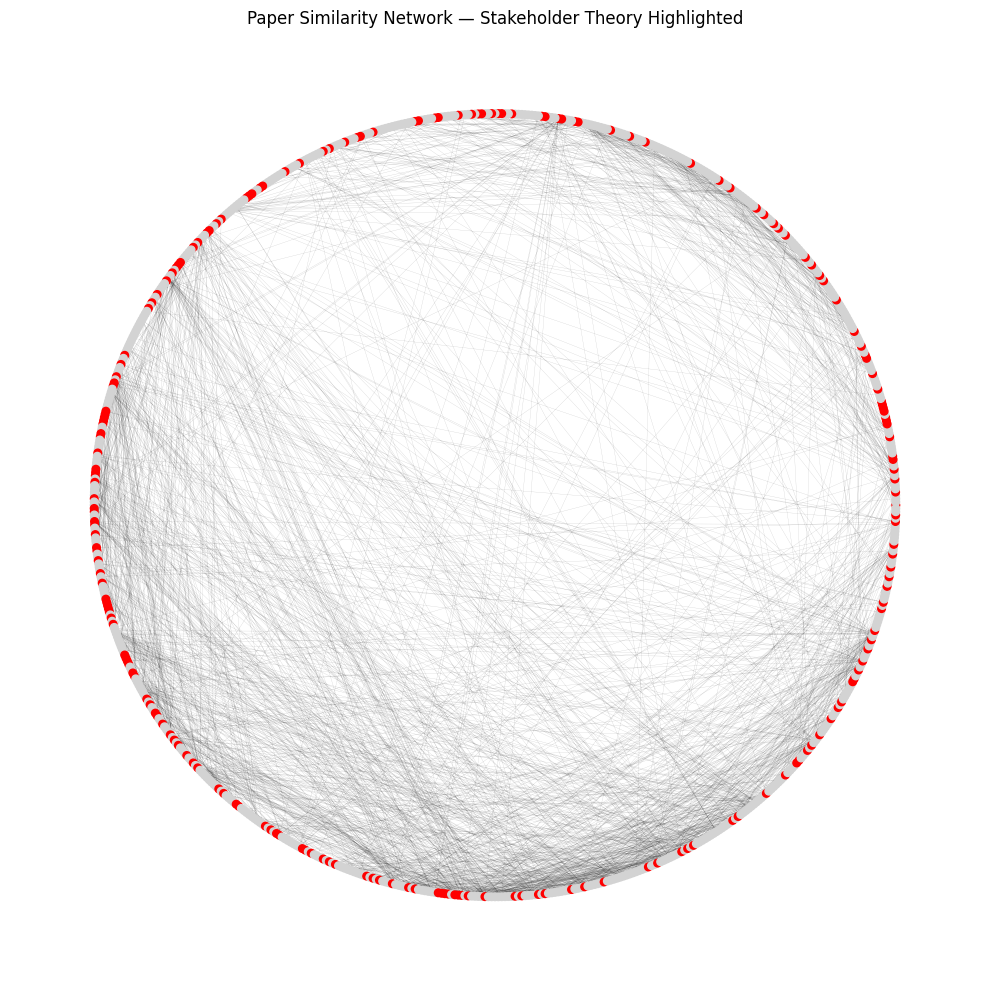

In [53]:
# Load theory map
theory_map = pd.read_csv(result_path + "dt_theory_similarity_matrix.csv")[["paper_id","dominant_dt_theory"]]
theory_dict = dict(zip(theory_map["paper_id"], theory_map["dominant_dt_theory"]))

node_colors = []
for node in G.nodes():
    if theory_dict.get(node) == "Stakeholder_Theory":
        node_colors.append("red")
    else:
        node_colors.append("lightgrey")

plt.figure(figsize=(10,10))
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=node_colors)
nx.draw_networkx_edges(G, pos, width=0.2, alpha=0.2)

plt.title("Paper Similarity Network — Stakeholder Theory Highlighted")
plt.axis("off")
plt.tight_layout()
plt.savefig(result_path + "Figure_Stakeholder_Highlight_Network.png", dpi=300)
plt.show()

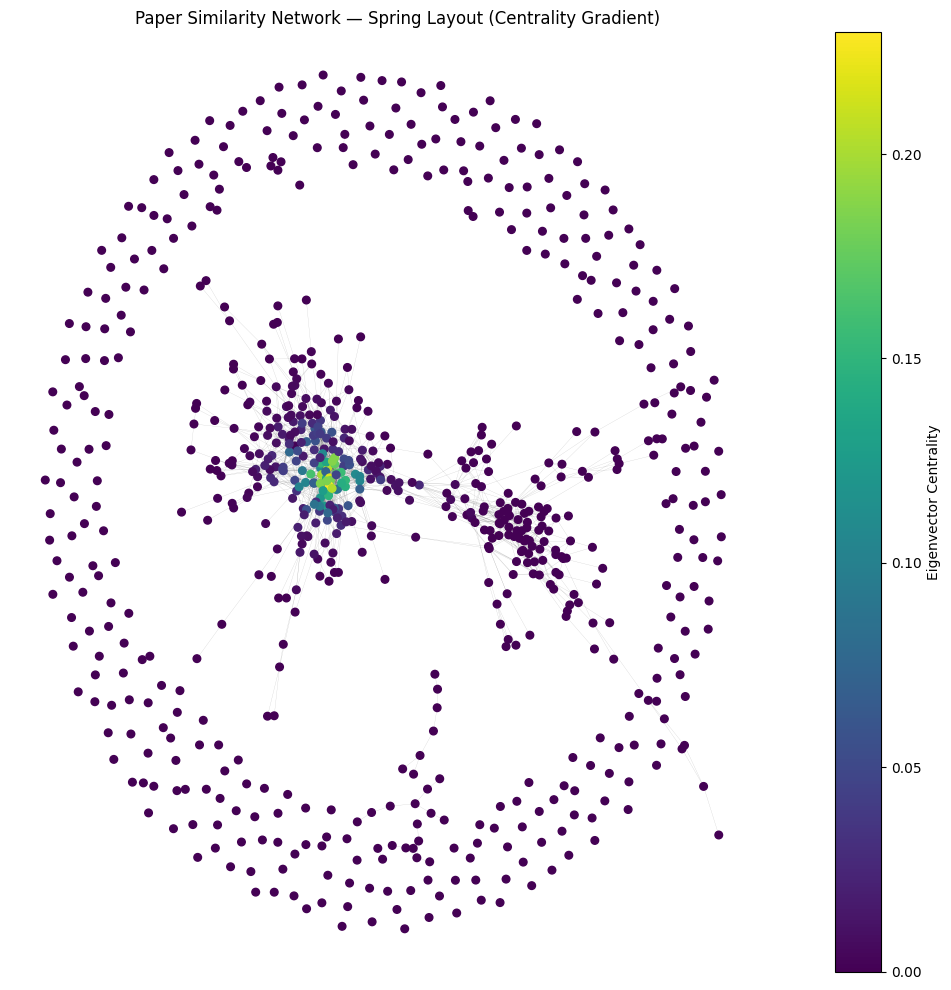

In [54]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

plt.figure(figsize=(10,10))

# Spring layout
pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

# Normalize centrality for color scale
centrality_vals = df_documents.set_index("paper_id")["eigenvector"]
node_colors = [centrality_vals[node] for node in G.nodes()]

nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=30,
    node_color=node_colors,
    cmap=plt.cm.viridis
)

nx.draw_networkx_edges(G, pos, width=0.2, alpha=0.2)

plt.title("Paper Similarity Network — Spring Layout (Centrality Gradient)")
plt.colorbar(nodes, label="Eigenvector Centrality")
plt.axis("off")
plt.tight_layout()

plt.savefig(result_path + "Figure_Spring_Centrality_Network.png", dpi=300)
plt.show()

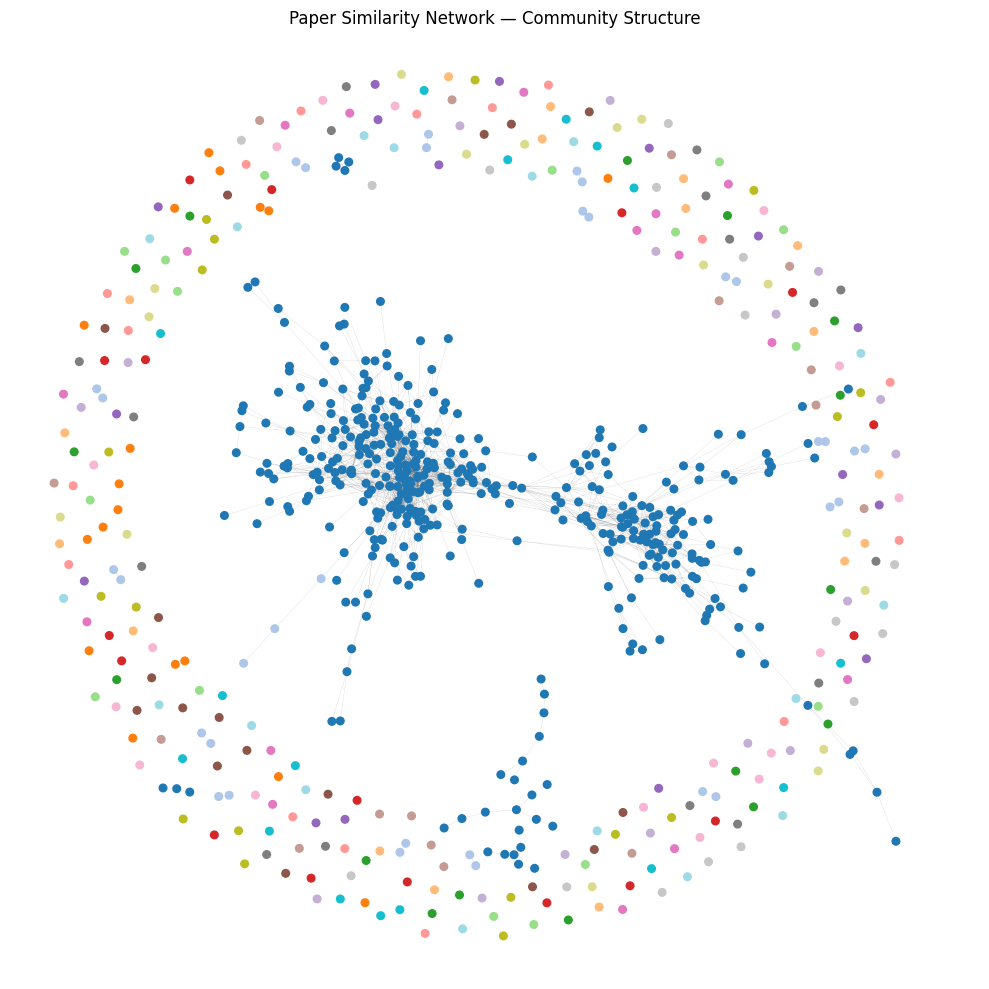

In [55]:
from networkx.algorithms.community import greedy_modularity_communities

communities = greedy_modularity_communities(G)

# Assign community ID
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

nx.set_node_attributes(G, community_map, "community")

# Plot
plt.figure(figsize=(10,10))
pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

node_colors = [community_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=30,
    node_color=node_colors,
    cmap=plt.cm.tab20
)

nx.draw_networkx_edges(G, pos, width=0.2, alpha=0.2)

plt.title("Paper Similarity Network — Community Structure")
plt.axis("off")
plt.tight_layout()

plt.savefig(result_path + "Figure_Community_Network.png", dpi=300)
plt.show()

In [56]:
import numpy as np

# 85th percentile cutoff
cutoff = np.percentile(df_documents["eigenvector"], 85)

df_core = df_documents.copy()
df_core["core_flag"] = df_core["eigenvector"] >= cutoff

print("Core size:", df_core["core_flag"].sum())
print("Periphery size:", (~df_core["core_flag"]).sum())

Core size: 113
Periphery size: 639


In [57]:
df_core_full = (
    df_core
    .merge(df_dc[["paper_id","dual_concern_mode"]], on="paper_id")
    .merge(df_stake, on="paper_id")
)

In [58]:
core_dual = (
    df_core_full
    .groupby(["core_flag","dual_concern_mode"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum() * 100)
    .unstack()
)

print(core_dual.round(2))

dual_concern_mode    Compromise  Forcing  Integration  Yielding
core_flag core_flag                                            
False     False           21.28    29.89        20.66     28.17
True      True            20.35    23.01        23.89     32.74


In [59]:
stake_compare = (
    df_core_full
    .groupby("core_flag")[[
        "stakeholder_signal_per_1000w",
        "stakeholder_diversity_category"
    ]]
    .mean()
)

print(stake_compare.round(2))

           stakeholder_signal_per_1000w  stakeholder_diversity_category
core_flag                                                              
False                              5.32                            3.89
True                               6.16                            4.19


In [60]:
df_comm = df_documents.copy()
df_comm["community"] = df_comm["paper_id"].map(community_map)

In [61]:
df_comm_full = (
    df_comm
    .merge(df_dc[["paper_id","dual_concern_mode"]], on="paper_id")
    .merge(df_stake, on="paper_id")
)

In [62]:
community_dual = (
    df_comm_full
    .groupby(["community","dual_concern_mode"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum() * 100)
    .unstack()
)

print(community_dual.round(2))

dual_concern_mode    Compromise  Forcing  Integration  Yielding
community community                                            
0         0               17.76    18.69        20.56     42.99
1         1               18.27    32.69        24.04     25.00
2         2               10.59     8.24        27.06     54.12
3         3               52.38    33.33         4.76      9.52
4         4               23.81    23.81        38.10     14.29
...                         ...      ...          ...       ...
322       322               NaN   100.00          NaN       NaN
323       323               NaN   100.00          NaN       NaN
324       324               NaN      NaN          NaN    100.00
325       325               NaN      NaN          NaN    100.00
326       326            100.00      NaN          NaN       NaN

[327 rows x 4 columns]


In [63]:
community_stake = (
    df_comm_full
    .groupby("community")[[
        "stakeholder_signal_per_1000w",
        "stakeholder_diversity_category"
    ]]
    .mean()
)

print(community_stake.round(2))

           stakeholder_signal_per_1000w  stakeholder_diversity_category
community                                                              
0                                  4.89                            4.05
1                                  5.63                            4.19
2                                  6.34                            4.16
3                                  5.11                            4.00
4                                  8.26                            4.19
...                                 ...                             ...
322                                4.39                            4.00
323                                7.26                            3.00
324                                5.22                            5.00
325                                7.23                            5.00
326                                1.11                            3.00

[327 rows x 2 columns]


In [64]:
# community sizes
community_sizes = (
    df_comm_full["community"]
    .value_counts()
    .reset_index()
    .rename(columns={"index":"community","community":"size"})
)

print(community_sizes.head(10))

   size  count
0     0    107
1     1    104
2     2     85
3     4     21
4     3     21
5     5     15
6     6     13
7     7      9
8     8      8
9    10      7


In [65]:
top_comms = [0,1,2]

community_focus = (
    df_comm_full[df_comm_full["community"].isin(top_comms)]
)

# Dual Concern distribution
dual_top = (
    community_focus
    .groupby(["community","dual_concern_mode"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum() * 100)
    .unstack()
)

print("Dual Concern — Top Communities")
print(dual_top.round(2))

# Stakeholder depth
stake_top = (
    community_focus
    .groupby("community")[[
        "stakeholder_signal_per_1000w",
        "stakeholder_diversity_category"
    ]]
    .mean()
)

print("\nStakeholder Depth — Top Communities")
print(stake_top.round(2))

Dual Concern — Top Communities
dual_concern_mode    Compromise  Forcing  Integration  Yielding
community community                                            
0         0               17.76    18.69        20.56     42.99
1         1               18.27    32.69        24.04     25.00
2         2               10.59     8.24        27.06     54.12

Stakeholder Depth — Top Communities
           stakeholder_signal_per_1000w  stakeholder_diversity_category
community                                                              
0                                  4.89                            4.05
1                                  5.63                            4.19
2                                  6.34                            4.16


In [66]:
core_by_comm = (
    df_comm_full
    .groupby("community")["eigenvector"]
    .mean()
    .reset_index()
    .sort_values("eigenvector", ascending=False)
)

print(core_by_comm.head(10))

    community  eigenvector
1           1     0.068662
2           2     0.016118
3           3     0.011815
16         16     0.006089
4           4     0.005057
7           7     0.003524
6           6     0.002406
17         17     0.000783
0           0     0.000761
15         15     0.000083


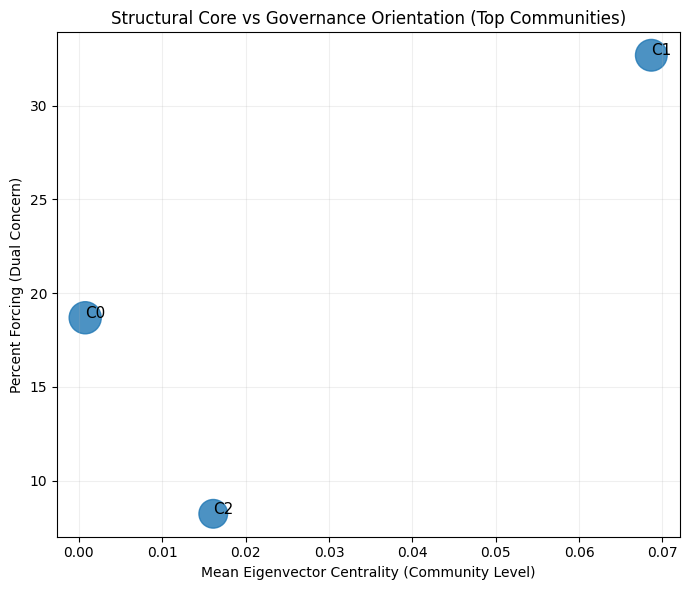

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Merge centrality and dual concern
community_summary = (
    df_comm_full
    .groupby("community")
    .agg({
        "eigenvector": "mean",
        "dual_concern_mode": lambda x: (x == "Forcing").mean() * 100
    })
    .rename(columns={
        "eigenvector": "mean_eigenvector",
        "dual_concern_mode": "percent_forcing"
    })
    .reset_index()
)

# Add community sizes
sizes = (
    df_comm_full["community"]
    .value_counts()
    .reset_index()
)
sizes.columns = ["community","size"]

community_summary = community_summary.merge(sizes, on="community")

# Keep top 3 largest communities
top3 = sizes.sort_values("size", ascending=False).head(3)["community"].tolist()
plot_df = community_summary[community_summary["community"].isin(top3)]

# Plot
plt.figure(figsize=(7,6))

plt.scatter(
    plot_df["mean_eigenvector"],
    plot_df["percent_forcing"],
    s=plot_df["size"] * 5,
    alpha=0.8
)

# Labels
for _, row in plot_df.iterrows():
    plt.annotate(
        f"C{int(row['community'])}",
        (row["mean_eigenvector"], row["percent_forcing"]),
        fontsize=11
    )

plt.xlabel("Mean Eigenvector Centrality (Community Level)")
plt.ylabel("Percent Forcing (Dual Concern)")
plt.title("Structural Core vs Governance Orientation (Top Communities)")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(result_path + "Figure_Community_Centrality_vs_Forcing.png", dpi=300)
plt.show()